<a href="https://colab.research.google.com/github/barlaldo/Detecting-Plagiarized-Texts/blob/main/Master's_Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUCTION

- Clearly Define the Purpose: Start with a brief explanation of your thesis’s goals. Describe why detecting if a text was generated by a language model (LLM) is essential, and introduce SemStamp as the primary detection method you’ll use.
- Set Up the Problem Statement: Frame the problem as detecting LLM-generated text through language translation, synonym substitution, and z-score calculation

In [ ]:
pip install huggingface_hub

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
import random
import numpy as np
import torch

# Set the seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load Sentence-Transformer model
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")  # Or try "all-mpnet-base-v2"

def calculate_semantic_difference(text1, text2):
    # Encode texts with the sentence-transformers model
    embedding_text1 = semantic_model.encode(text1, convert_to_tensor=True)
    embedding_text2 = semantic_model.encode(text2, convert_to_tensor=True)

    # Compute cosine similarity between embeddings
    cosine_similarity = util.cos_sim(embedding_text1, embedding_text2).item()
    return cosine_similarity


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling%2Fconfig.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# IMPLEMENTATION STEPS

In [ ]:
pip install deep_translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.1 MB/s eta 0:00:00


In [ ]:
from deep_translator import GoogleTranslator

def translate_retranslate(text, target_lang="fr"):
    # Translate to target language
    translated = GoogleTranslator(source='auto', target=target_lang).translate(text)
    # Retranslate back to original language
    retranslated = GoogleTranslator(source=target_lang, target='auto').translate(translated)
    return retranslated


In [ ]:
def multi_language_translation(text, languages):
    results = {}
    for lang in languages:
        retranslated_text = translate_retranslate(text, target_lang=lang)

        # Calculate semantic similarity instead of z-score
        similarity = calculate_semantic_difference(text, retranslated_text)

        results[lang] = (retranslated_text, similarity)
    return results


In [ ]:
# from transformers import pipeline

# paraphraser = pipeline("text2text-generation", model="t5-small")

# def contextual_paraphrasing_improved(text):
#     paraphrased = paraphraser(text, max_length=200, num_beams=5, num_return_sequences=1)
#     return paraphrased[0]['generated_text']

# Use a pipeline as a high-level helper
from transformers import T5ForConditionalGeneration, T5Tokenizer
import re

t5_model = T5ForConditionalGeneration.from_pretrained("t5-small")
t5_tokenizer = T5Tokenizer.from_pretrained("t5-small")


def contextual_paraphrasing_improved(text):
    # Add the paraphrase prefix for T5
    input_text = f"paraphrase: {text}"
    input_ids = t5_tokenizer.encode(input_text, return_tensors="pt", max_length=512, truncation=True)

    # Generate the paraphrase
    outputs = t5_model.generate(
        input_ids,
        max_length=512,
        num_beams=5,
        early_stopping=True,
        no_repeat_ngram_size=2
    )

    # Decode the output
    paraphrased_text = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Remove unwanted prefixes like "True True" or "False Paraphrase:" if present
    cleaned_text = re.sub(r"^(True|False|Paraphrase:)\s*", "", paraphrased_text, flags=re.IGNORECASE)

    return cleaned_text


def split_and_paraphrase(text):
    sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?)\s', text)  # Split into sentences
    paraphrased_sentences = [contextual_paraphrasing_improved(sentence) for sentence in sentences]
    return " ".join(paraphrased_sentences)


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
sample_text = "The emergence of quantum computing has revolutionized the landscape of computational science, offering unprecedented capabilities for solving complex problems in cryptography, optimization, and artificial intelligence. However, the integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address."

paraphrased_text = split_and_paraphrase(sample_text)
print("Paraphrased Text:", paraphrased_text)

Paraphrased Text:  The integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address.


In [ ]:
sample_text = "The emergence of quantum computing has revolutionized the landscape of computational science, offering unprecedented capabilities for solving complex problems in cryptography, optimization, and artificial intelligence. However, the integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address."

paraphrased_text = contextual_paraphrasing_improved(sample_text)
print("Paraphrased Text:", paraphrased_text)


Paraphrased Text: 


In [ ]:
from transformers import pipeline

mask_filler = pipeline("fill-mask", model="bert-base-uncased")

def contextual_masking(text, mask_words):
    for word in mask_words:
        text = text.replace(word, "[MASK]", 1)
        masked_text = mask_filler(text)
        text = text.replace("[MASK]", masked_text[0]["token_str"], 1)
    return text


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'c

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

def apply_grammar_transformations_fixed(text):
    """Apply grammar transformations without disrupting punctuation."""
    doc = nlp(text)
    transformed_sentences = []

    for sent in doc.sents:
        transformed_tokens = []
        for token in sent:
            # Example transformation: Convert present tense to past tense
            if token.text.lower() == "is":
                transformed_tokens.append("was")
            elif token.text.lower() == "have":
                transformed_tokens.append("had")
            elif token.text.lower() == "will":
                transformed_tokens.append("would")
            elif token.text.lower() == "can":
                transformed_tokens.append("could")
            else:
                transformed_tokens.append(token.text_with_ws)

        # Reconstruct the sentence without breaking punctuation
        transformed_sentences.append("".join(transformed_tokens).strip())

    return " ".join(transformed_sentences)


In [ ]:
def multi_service_watermark_validation(text, languages, services, threshold=0.5):
    """
    Validate watermark integrity across multiple translation services and languages.

    Parameters:
        text (str): The original text to validate.
        languages (list): List of target languages for translation-retranslation.
        services (list): List of translation services to use.
        threshold (float): Similarity threshold to detect LLM-generated text.

    Returns:
        dict: Results containing similarity scores, z-scores, and detection outcomes for each language and service.
    """
    results = {}

    for service in services:
        service_results = {}
        for lang in languages:
            # Step 1: Translate and Retranslate
            retranslated_text = translate_with_service(text, target_language=lang, service=service)

            # Step 2: Calculate Semantic Similarity
            similarity_score = calculate_semantic_difference(text, retranslated_text)

            # Step 3: Calculate Z-Score
            z_score = calculate_z_score(similarity_score, text, retranslated_text)

            # Step 4: LLM Detection Based on Z-Score
            detected_as_llm = z_score < threshold

            # Step 5: Store Results
            service_results[lang] = {
                "retranslated_text": retranslated_text,
                "similarity_score": similarity_score,
                "z_score": z_score,
                "detected_as_llm": detected_as_llm
            }

        # Store results for the current service
        results[service] = service_results

    return results


In [ ]:
from deep_translator import GoogleTranslator, DeeplTranslator

def translate_with_service(text, target_language="fr", service="google"):
    """
    Translate and retranslate text using a specified translation service.

    Parameters:
        text (str): Original text to translate.
        target_language (str): Target language for translation.
        service (str): Translation service to use ("google" or "deepl").

    Returns:
        str: Retranslated text.
    """
    if service == "google":
        translated_text = GoogleTranslator(source='en', target=target_language).translate(text)
        retranslated_text = GoogleTranslator(source=target_language, target='en').translate(translated_text)
    elif service == "deepl":
        # Placeholder for DeepL API integration
        translated_text = "Deepl_translation_function(text, target_language)"
        retranslated_text = "Deepl_retranslate_function(translated_text, 'en')"
    else:
        raise ValueError("Unsupported service specified. Please choose 'google' or 'deepl'.")

    return retranslated_text


In [ ]:
# import spacy
# from transformers import AutoModelForMaskedLM, AutoTokenizer
# from sentence_transformers import SentenceTransformer, util

# # Load spaCy and BERT models
# nlp = spacy.load("en_core_web_sm")
# bert_model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")
# bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# embedder = SentenceTransformer("all-MiniLM-L6-v2")

# def bert_contextual_replacement_with_similarity_fixed(text, similarity_threshold=0.75, top_k=10):
#     words = text.split()
#     new_text = []

#     for i, word in enumerate(words):
#         # Skip subwords and short words
#         if len(word) <= 2 or word in [",", ".", ":", ";", "?", "!"]:
#             new_text.append(word)
#             continue

#         # Mask the word
#         masked_text = " ".join(words[:i] + ["[MASK]"] + words[i + 1:])
#         inputs = bert_tokenizer(masked_text, return_tensors="pt")
#         outputs = bert_model(**inputs)
#         logits = outputs.logits
#         mask_token_index = (inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
#         mask_logits = logits[0, mask_token_index, :]
#         top_predictions = torch.topk(mask_logits, top_k, dim=-1).indices[0].tolist()

#         # Get top suggestions
#         suggestions = [bert_tokenizer.decode([token_id]).strip() for token_id in top_predictions]

#         # Compare similarity and validate grammar
#         original_embedding = embedder.encode(word, convert_to_tensor=True)
#         best_replacement = word
#         highest_similarity = 0

#         for candidate in suggestions:
#             candidate_embedding = embedder.encode(candidate, convert_to_tensor=True)
#             similarity = util.pytorch_cos_sim(original_embedding, candidate_embedding).item()

#             if similarity > highest_similarity and similarity >= similarity_threshold and candidate != word:
#                 temp_text = " ".join(new_text + [candidate] + words[i + 1:])
#                 doc = nlp(temp_text)
#                 if all([token.dep_ not in ["dep", "punct"] for token in doc]):  # Validate grammar
#                     best_replacement = candidate
#                     highest_similarity = similarity

#         new_text.append(best_replacement)

#     return " ".join(new_text)



In [ ]:
def bert_contextual_replacement_with_logging(text, similarity_threshold=0.85, top_k=5):
    words = text.split()
    new_text = []

    for i, word in enumerate(words):
        # Skip subwords and short words
        if len(word) <= 2 or word in [",", ".", ":", ";", "?", "!"]:
            new_text.append(word)
            continue

        # Mask the word
        masked_text = " ".join(words[:i] + ["[MASK]"] + words[i + 1:])
        inputs = bert_tokenizer(masked_text, return_tensors="pt")
        outputs = bert_model(**inputs)
        logits = outputs.logits
        mask_token_index = (inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
        mask_logits = logits[0, mask_token_index, :]
        top_predictions = torch.topk(mask_logits, top_k, dim=-1).indices[0].tolist()

        # Get top suggestions
        suggestions = [bert_tokenizer.decode([token_id]).strip() for token_id in top_predictions]

        # Compare similarity and validate grammar
        original_embedding = embedder.encode(word, convert_to_tensor=True)
        best_replacement = word
        highest_similarity = 0

        print(f"Original word: {word}")
        print(f"Suggestions: {suggestions}")

        for candidate in suggestions:
            candidate_embedding = embedder.encode(candidate, convert_to_tensor=True)
            similarity = util.pytorch_cos_sim(original_embedding, candidate_embedding).item()

            print(f"Candidate: {candidate}, Similarity: {similarity}")

            if similarity > highest_similarity and similarity >= similarity_threshold and candidate != word:
                temp_text = " ".join(new_text + [candidate] + words[i + 1:])
                doc = nlp(temp_text)
                if all([token.dep_ not in ["dep", "punct"] for token in doc]):  # Validate grammar
                    best_replacement = candidate
                    highest_similarity = similarity

        print(f"Selected replacement: {best_replacement}")
        new_text.append(best_replacement)

    return " ".join(new_text)


In [ ]:
def layered_watermarking(original_text):
    # Step 1: Grammar transformations
    transformed_text = apply_grammar_transformations_fixed(original_text)
    transformed_semantic_score = calculate_semantic_z_score(original_text, transformed_text)
    print(f"Semantic Z-Score after Grammar Transforamations: {transformed_semantic_score:.4f}")

    # Step 2: Contextual paraphrasing
    paraphrased_text = randomize_and_paraphrase(transformed_text)
    paraphrased_semantic_score = calculate_semantic_z_score(transformed_text, paraphrased_text)
    print(f"Semantic Z-Score after Contextual Paraphrasing: {paraphrased_semantic_score:.4f}")

    # Step 3: BERT-based replacements with semantic similarity
    watermarked_text = bert_contextual_replacement_with_similarity_fixed(paraphrased_text)
    watermarked_semantic_score = calculate_semantic_z_score(paraphrased_text, watermarked_text)
    print(f"Semantic Z-Score after BERT-Based Replacement: {watermarked_semantic_score:.4f}")



    return watermarked_text

In [ ]:
def layered_watermarking_debug(original_text):
    # Step 1: Grammar transformations
    transformed_text = apply_grammar_transformations_fixed(original_text)
    print("Transformed Text:", transformed_text)

    # Step 2: Contextual paraphrasing
    paraphrased_text = randomize_and_paraphrase(transformed_text)
    print("Paraphrased Text:", paraphrased_text)

    # Step 3: BERT-based replacements with semantic similarity
    watermarked_text = bert_contextual_replacement_with_logging(paraphrased_text)
    print("Watermarked Text:", watermarked_text)

    return watermarked_text


In [ ]:
from transformers import AutoModel, AutoTokenizer
import torch

# Load the SemStamp model and tokenizer
watermark_model = AutoModel.from_pretrained("AbeHou/SemStamp-c4-sbert")
tokenizer_watermark = AutoTokenizer.from_pretrained("AbeHou/SemStamp-c4-sbert")

print("SemStamp model and tokenizer loaded successfully.")

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

SemStamp model and tokenizer loaded successfully.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_semstamp_z_score(text, reference_text=None):
    """
    Calculate the SemStamp z-score for a given text.
    If a reference_text is provided, calculate dissimilarity.
    """
    inputs = tokenizer_watermark(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        embeddings = watermark_model(**inputs).last_hidden_state.mean(dim=1)

    if reference_text:
        ref_inputs = tokenizer_watermark(reference_text, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            ref_embeddings = watermark_model(**ref_inputs).last_hidden_state.mean(dim=1)

        # Cosine similarity between embeddings
        similarity = cosine_similarity(embeddings.numpy(), ref_embeddings.numpy())[0, 0]
        z_score = 1 - similarity  # Lower similarity = higher z-score
        return z_score

    # Norm of embeddings for self-detection
    return embeddings.norm(dim=1).item()


In [ ]:
import time

def translate_with_service(text, target_language="fr", service="google"):
    if service == "google":
        translated_text = GoogleTranslator(source='en', target=target_language).translate(text)
        retranslated_text = GoogleTranslator(source=target_language, target='en').translate(translated_text)
    elif service == "deepl":
        # Pass the API key here
        translated_text = DeeplTranslator(source='en', target=target_language, api_key=DEEPL_API_KEY).translate(text)
        retranslated_text = DeeplTranslator(source=target_language, target='en', api_key=DEEPL_API_KEY).translate(translated_text)
    else:
        raise ValueError("Unsupported service specified. Please choose 'google' or 'deepl'.")

    return retranslated_text

def multi_service_translation(text, languages, services):
    results = {}
    iteration_count = 0  # Initialize iteration counter

    for service in services:
        service_results = {}
        for lang in languages:
            iteration_count += 1  # Increment counter for each iteration
            print(f"Iteration: {iteration_count}, Language: {lang}, Service: {service}")  # Print current iteration and language

            # Perform translation and retranslation
            try:
                retranslated_text = translate_with_service(text, target_language=lang, service=service)
            except ConnectionError as e:
                print(f"Connection error encountered for language {lang} and service {service}: {e}")
                print("Retrying in 5 seconds...")
                time.sleep(5)  # Wait for 5 seconds before retrying
                retranslated_text = translate_with_service(text, target_language=lang, service=service)  # Retry the translation

            # Calculate metrics
            similarity_score = calculate_semantic_difference(text, retranslated_text)
            original_perplexity = calculate_perplexity(text)
            retranslated_perplexity = calculate_perplexity(retranslated_text)
            perplexity_diff = retranslated_perplexity - original_perplexity

            # Store results
            service_results[lang] = {
                "retranslated_text": retranslated_text,
                "similarity_score": similarity_score,
                #"original_perplexity": original_perplexity,
                #"retranslated_perplexity": retranslated_perplexity,
                #"perplexity_diff": perplexity_diff,
            }
        results[service] = service_results #Store results for the current service
    return results

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def calculate_semantic_z_score(original_text, retranslated_text):
    original_embedding = embedder.encode(original_text, convert_to_tensor=True)
    retranslated_embedding = embedder.encode(retranslated_text, convert_to_tensor=True)
    similarity = util.pytorch_cos_sim(original_embedding, retranslated_embedding).item()
    return 1 - similarity  # Dissimilarity as z-score

original_text = "Rapid advances in artificial intelligence have sparked intense debates about their future implications."
retranslated_text = "The rapid evolution of synthetic intelligence has sparked intense debate about its future implications."
z_score = calculate_semantic_z_score(original_text, retranslated_text)
print(f"Semantic Z-Score: {z_score:.4f}")


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Semantic Z-Score: 0.1838


In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load GPT-2 model and tokenizer
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

def calculate_perplexity(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
    loss = outputs.loss
    perplexity = torch.exp(loss)
    return perplexity.item()

original_perplexity = calculate_perplexity(original_text)
retranslated_perplexity = calculate_perplexity(retranslated_text)
print(f"Original Perplexity: {original_perplexity:.2f}")
print(f"Retranslated Perplexity: {retranslated_perplexity:.2f}")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Original Perplexity: 38.21
Retranslated Perplexity: 41.87


In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load multilingual alignment model
labse_model = SentenceTransformer("sentence-transformers/LaBSE")

def multilingual_z_score(original_text, retranslated_text):
    original_embedding = labse_model.encode(original_text, convert_to_tensor=True)
    retranslated_embedding = labse_model.encode(retranslated_text, convert_to_tensor=True)
    similarity = util.pytorch_cos_sim(original_embedding, retranslated_embedding).item()
    return 1 - similarity

# Compare multilingual semantic alignment
z_score = multilingual_z_score(original_text, retranslated_text)
print(f"Multilingual Semantic Z-Score: {z_score:.4f}")


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.22k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

1_Pooling%2Fconfig.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2_Dense%2Fconfig.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Multilingual Semantic Z-Score: 0.0747


In [ ]:
# import random
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# from sentence_transformers import SentenceTransformer, util

# # Load models
# tokenizer = AutoTokenizer.from_pretrained("Vamsi/T5_Paraphrase_Paws")
# model = AutoModelForSeq2SeqLM.from_pretrained("Vamsi/T5_Paraphrase_Paws").to("cpu")
# embedder = SentenceTransformer("all-MiniLM-L6-v2")

# # Add padding token if not already present
# if tokenizer.pad_token is None:
#     tokenizer.add_special_tokens({'pad_token': '[PAD]'})
#     model.resize_token_embeddings(len(tokenizer))  # Resize model embeddings

# def paraphrase_sentence(sentence):
#     """Paraphrase a full sentence using T5."""
#     paraphrase_prompt = f"paraphrase: {sentence} </s>"
#     encoding = tokenizer.encode_plus(
#         paraphrase_prompt, padding="max_length", max_length=512, truncation=True, return_tensors="pt"
#     )
#     input_ids, attention_mask = encoding["input_ids"], encoding["attention_mask"]
#     outputs = model.generate(
#         input_ids=input_ids,
#         attention_mask=attention_mask,
#         max_length=256,
#         do_sample=True,
#         top_k=50,
#         top_p=0.90,
#         temperature=1.2,
#         num_return_sequences=1,
#     )
#     paraphrased = tokenizer.decode(outputs[0], skip_special_tokens=True)
#     return paraphrased.strip()

# def randomize_and_paraphrase(text, num_sentences=3):
#     """Randomly select sentences and paraphrase them."""
#     sentences = text.split(". ")
#     selected_indices = random.sample(range(len(sentences)), min(num_sentences, len(sentences)))

#     for idx in selected_indices:
#         sentences[idx] = paraphrase_sentence(sentences[idx])

#     return ". ".join(sentences)


# # Test the function
# sample_text = (
#     "The emergence of quantum computing has revolutionized the landscape of computational science, "
#     "offering unprecedented capabilities for solving complex problems in cryptography, optimization, and artificial intelligence. "
#     "However, the integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address."
# )

# watermarked_text = randomize_and_paraphrase(sample_text)
# print("Watermarked Text:", watermarked_text)


In [ ]:
import random
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer, util

# Load models
tokenizer = AutoTokenizer.from_pretrained("Vamsi/T5_Paraphrase_Paws")
model = AutoModelForSeq2SeqLM.from_pretrained("Vamsi/T5_Paraphrase_Paws").to("cpu")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Add padding token if not already present
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.resize_token_embeddings(len(tokenizer))  # Resize model embeddings

def randomize_and_paraphrase(text, num_sentences=3, temperature=1.8, top_p=0.8):
    """Paraphrase selected sentences more aggressively."""
    sentences = text.split(". ")
    selected_indices = random.sample(range(len(sentences)), min(num_sentences, len(sentences)))

    for idx in selected_indices:
        paraphrase_prompt = f"paraphrase: {sentences[idx]} </s>"
        encoding = tokenizer.encode_plus(
            paraphrase_prompt, padding="max_length", max_length=512, truncation=True, return_tensors="pt"
        )
        input_ids, attention_mask = encoding["input_ids"], encoding["attention_mask"]
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=256,
            do_sample=True,
            top_k=50,
            top_p=top_p,
            temperature=temperature,
            num_return_sequences=3,  # Generate multiple candidates
        )
        paraphrases = [tokenizer.decode(o, skip_special_tokens=True).strip() for o in outputs]

        # Pick the most different paraphrase
        original_embedding = embedder.encode(sentences[idx], convert_to_tensor=True)
        min_similarity = 1.0
        selected_paraphrase = sentences[idx]  # Default to original

        for paraphrase in paraphrases:
            paraphrase_embedding = embedder.encode(paraphrase, convert_to_tensor=True)
            similarity = util.pytorch_cos_sim(original_embedding, paraphrase_embedding).item()
            if similarity < min_similarity:  # Pick the least similar paraphrase
                min_similarity = similarity
                selected_paraphrase = paraphrase

        sentences[idx] = selected_paraphrase

    return ". ".join(sentences)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

In [ ]:
import spacy
from transformers import AutoModelForMaskedLM, AutoTokenizer
from sentence_transformers import SentenceTransformer, util

def bert_contextual_replacement_with_similarity_fixed(text, similarity_threshold=0.5, top_k=10):
    """Replace words with more diverse BERT alternatives."""
    # Load spaCy and BERT models here, inside the function
    nlp = spacy.load("en_core_web_sm")
    bert_model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")
    bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")  # Initialize bert_tokenizer
    embedder = SentenceTransformer("all-MiniLM-L6-v2")

    words = text.split()
    new_text = []

    for i, word in enumerate(words):
        if len(word) <= 2 or word in [",", ".", ":", ";", "?", "!"]:
            new_text.append(word)
            continue

        masked_text = " ".join(words[:i] + ["[MASK]"] + words[i + 1:])
        inputs = bert_tokenizer(masked_text, return_tensors="pt")
        outputs = bert_model(**inputs)
        logits = outputs.logits
        mask_token_index = (inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
        mask_logits = logits[0, mask_token_index, :]
        top_predictions = torch.topk(mask_logits, top_k, dim=-1).indices[0].tolist()

        suggestions = [bert_tokenizer.decode([token_id]).strip() for token_id in top_predictions]
        original_embedding = embedder.encode(word, convert_to_tensor=True)

        # Choose the **least similar valid** replacement
        min_similarity = 1.0
        best_replacement = word

        for candidate in suggestions:
            candidate_embedding = embedder.encode(candidate, convert_to_tensor=True)
            similarity = util.pytorch_cos_sim(original_embedding, candidate_embedding).item()
            if similarity < min_similarity and similarity >= similarity_threshold:
                min_similarity = similarity
                best_replacement = candidate

        new_text.append(best_replacement)

    return " ".join(new_text)

# NEW WORKFLOW

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.1 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset('glue', 'mrpc', split='train')

df = dataset.to_csv('mrpc_dataset.csv', index=False)
df = pd.read_csv('mrpc_dataset.csv')
df.head()

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

Creating CSV from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

,sentence1,sentence2,label,idx
0,"Amrozi accused his brother , whom he called "" ...","Referring to him as only "" the witness "" , Amr...",1,0
1,Yucaipa owned Dominick 's before selling the c...,Yucaipa bought Dominick 's in 1995 for $ 693 m...,0,1
2,They had published an advertisement on the Int...,"On June 10 , the ship 's owners had published ...",1,2
3,"Around 0335 GMT , Tab shares were up 19 cents ...","Tab shares jumped 20 cents , or 4.6 % , to set...",0,3
4,"The stock rose $ 2.11 , or about 11 percent , ...",PG & E Corp. shares jumped $ 1.63 or 8 percent...,1,4


In [ ]:
len(df)

3668

In [ ]:
# Select the first 100 rows of the DataFrame
df_subset = df.head(100)

# Apply watermarking to the subset
df_subset['watermarked_sentence1'] = df_subset['sentence1'].apply(layered_watermarking)

Semantic Z-Score after Grammar Transforamations: -0.0000
Semantic Z-Score after Contextual Paraphrasing: 0.0545


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Semantic Z-Score after BERT-Based Replacement: 0.1070
Semantic Z-Score after Grammar Transforamations: 0.0000
Semantic Z-Score after Contextual Paraphrasing: 0.1907


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Semantic Z-Score after BERT-Based Replacement: 0.0957
Semantic Z-Score after Grammar Transforamations: 0.0000
Semantic Z-Score after Contextual Paraphrasing: 0.1958


...

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Semantic Z-Score after BERT-Based Replacement: 0.2053
Semantic Z-Score after Grammar Transforamations: 0.0000
Semantic Z-Score after Contextual Paraphrasing: 0.2516


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Semantic Z-Score after BERT-Based Replacement: 0.2933


<ipython-input-31-71a8c3963c3f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['watermarked_sentence1'] = df_subset['sentence1'].apply(layered_watermarking)


In [ ]:
df_subset

,sentence1,sentence2,label,idx,watermarked_sentence1
0,"Amrozi accused his brother , whom he called "" ...","Referring to him as only "" the witness "" , Amr...",1,0,"Amrozi alleged to the son , what he named "" hi..."
1,Yucaipa owned Dominick 's before selling the c...,Yucaipa bought Dominick 's in 1995 for $ 693 m...,0,1,until losing it and $ 2.5 m in 2012 to Safeway...
2,They had published an advertisement on the Int...,"On June 10 , the ship 's owners had published ...",1,2,On december 10 she have released an ad on his ...
3,"Around 0335 GMT , Tab shares were up 19 cents ...","Tab shares jumped 20 cents , or 4.6 % , to set...",0,3,in 0335 GMT tab shares improved in value by 19...
4,"The stock rose $ 2.11 , or about 11 percent , ...",PG & E Corp. shares jumped $ 1.63 or 8 percent...,1,4,"his price climbed $1 ,111 , or almost 11 % to ..."
...,...,...,...,...,...
95,Tonight a spokesman for Russia 's foreign mini...,Tonight a spokesman for the Russian Foreign Mi...,1,109,a department of australian diplomatic affairs ...
96,"A day earlier , a committee appointed by refor...","A day earlier , a committee appointed by Presi...",1,110,"A week afterward a committee , set up by his r..."
97,The suite comes complete with a word processor...,"The suite includes a word processor , spreadsh...",1,111,"It still provides a word processing , spreadsh..."
98,"Downstream at Mount Vernon , the Skagit River ...",The Skagit was expected to crest during the ni...,1,112,"Downstream , his Skagit valley seemed expected..."


In [ ]:
df_subset.to_excel('df_subset_fixed.xlsx', index=False, float_format='%.15f') # Up to 15 decimal places

In [ ]:
# languages = ["fr", "es", "de", "it","nl","sv","tr","ru","pt","ja"]
# services = ["google", "deepl"]
# # Instead of exporting, pass the API key directly to DeeplTranslator
# DEEPL_API_KEY = "4393ddc3-6fa4-4e1e-a9ba-8179fcdd3b5b:fx"

# # Split the subset into two halves
# df_subset_part1 = df_subset.iloc[:len(df_subset) // 2]
# df_subset_part2 = df_subset.iloc[len(df_subset) // 2:]

# # Apply multi-service translation to each part separately
# df_subset_part1['retranslated_results'] = df_subset_part1['watermarked_sentence1'].apply(
#     lambda text: multi_service_translation(text, languages, services)
# )

# df_subset_part2['retranslated_results'] = df_subset_part2['watermarked_sentence1'].apply(
#     lambda text: multi_service_translation(text, languages, services)
# )

# # Concatenate the results back together
# df_subset = pd.concat([df_subset_part1, df_subset_part2])

languages = ["fr", "es", "de", "it","nl","sv","tr","ru","pt","ja"]
services = ["google", "deepl"]
# Instead of exporting, pass the API key directly to DeeplTranslator
#DEEPL_API_KEY = "4393ddc3-6fa4-4e1e-a9ba-8179fcdd3b5b:fx"
DEEPL_API_KEY = 'b440d3b4-641a-4e18-afb6-1148323cf051:fx'

# Split the subset into quarters
df_subset_part1 = df_subset.iloc[:len(df_subset) // 4]  # First quarter (already processed)
df_subset_part2 = df_subset.iloc[len(df_subset) // 4 : len(df_subset) // 2]  # Second quarter
df_subset_part3 = df_subset.iloc[len(df_subset) // 2 : 3 * len(df_subset) // 4]  # Third quarter
df_subset_part4 = df_subset.iloc[3 * len(df_subset) // 4 :]  # Fourth quarter

# Apply multi-service translation to the second quarter
df_subset_part3['retranslated_results'] = df_subset_part3['watermarked_sentence1'].apply(
    lambda text: multi_service_translation(text, languages, services)
)

# # Apply multi-service translation to the second quarter
# df_subset_part4['retranslated_results'] = df_subset_part4['watermarked_sentence1'].apply(
#     lambda text: multi_service_translation(text, languages, services)
# )

Iteration: 1, Language: fr, Service: google
Iteration: 2, Language: es, Service: google
Iteration: 3, Language: de, Service: google
Iteration: 4, Language: it, Service: google
Iteration: 5, Language: nl, Service: google
Iteration: 6, Language: sv, Service: google
Iteration: 7, Language: tr, Service: google
Iteration: 8, Language: ru, Service: google
Iteration: 9, Language: pt, Service: google
Iteration: 10, Language: ja, Service: google
Iteration: 11, Language: fr, Service: deepl
Iteration: 12, Language: es, Service: deepl
Iteration: 13, Language: de, Service: deepl
Iteration: 14, Language: it, Service: deepl
Iteration: 15, Language: nl, Service: deepl
Iteration: 16, Language: sv, Service: deepl
Iteration: 17, Language: tr, Service: deepl
Iteration: 18, Language: ru, Service: deepl
Iteration: 19, Language: pt, Service: deepl
Iteration: 20, Language: ja, Service: deepl
Iteration: 1, Language: fr, Service: google
Iteration: 2, Language: es, Service: google
Iteration: 3, Language: de, Ser

<ipython-input-35-b47276f82de0>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset_part3['retranslated_results'] = df_subset_part3['watermarked_sentence1'].apply(


In [ ]:
df_subset_part3

,sentence1,sentence2,label,idx,watermarked_sentence1,retranslated_results
50,Several of the questions asked by the audience...,Several of the audience questions were new to ...,1,58,all requests answered by her public are for ne...,{'google': {'fr': {'retranslated_text': 'All r...
51,"Meanwhile , the global death toll approached 7...",The global death toll from SARS was at least 7...,1,59,"At his same time , a international casualty nu...",{'google': {'fr': {'retranslated_text': 'Meanw...
52,The battles marked day four of a U.S. sweep to...,"Twenty-seven Iraqis were killed , pushing the ...",0,60,ten hours of violence are the last months of a...,{'google': {'fr': {'retranslated_text': 'Ten h...
53,The women then had follow-up examinations afte...,The women had follow-up examinations in 1974-7...,0,61,"and you have follow-up tours at 11 , 12 then 2...",{'google': {'fr': {'retranslated_text': 'and y...
54,The Embraer jets are scheduled to be delivered...,The Bombardier and Embraer aircraft will be de...,0,62,The Embraer flights be supposed to be operatin...,{'google': {'fr': {'retranslated_text': 'Embra...
55,Contrary to what PeopleSoft management would h...,Ellison said that contrary to the contentions ...,1,63,according to what your folks in PeopleSoft wou...,{'google': {'fr': {'retranslated_text': 'From ...
56,Application Intelligence will be included as p...,The new application intelligence features will...,0,64,Application intelligencewould be combined alon...,{'google': {'fr': {'retranslated_text': 'Appli...
57,"American Masters : Arthur Miller , Elia Kazan ...",Note the subheading of this terrible parable i...,0,65,"Arthur Miller , Elia Kazan & her blacklist : n...",{'google': {'fr': {'retranslated_text': 'Arthu...
58,"The downtime , to take place in May and June ,...",The downtime is expected to take 60 million to...,1,66,The time is projected to cut development by 20...,{'google': {'fr': {'retranslated_text': 'Devel...
59,"On July 3 , Troy is expected to be sentenced t...",Troy faces life in prison without parole at hi...,1,67,"On 3 november , Troy should be condemned with ...",{'google': {'fr': {'retranslated_text': 'On No...


In [ ]:
df_subset_part4

,sentence1,sentence2,label,idx,watermarked_sentence1,retranslated_results
75,NEC is pitching its wireless gear and manageme...,NEC 's pitching its wireless gear and manageme...,1,87,It is distributing their communications gear /...,{'google': {'fr': {'retranslated_text': 'It di...
76,"Elena Slough , considered to be the nation 's ...","ELENA Slough , considered to be the oldest per...",1,88,Helena are listed as her country 's youngest f...,{'google': {'fr': {'retranslated_text': 'Helen...
77,""" We are declaring war on sexual harassment an...",""" We have declared war on sexual assault and s...",1,89,We proclaim attacks on male violence / male ha...,{'google': {'fr': {'retranslated_text': 'We de...
78,The technology-laced Nasdaq Composite Index < ...,The technology-laced Nasdaq Composite Index .I...,0,90,Nasdaq - Nasdaq Composite indices '' added 1.9...,{'google': {'fr': {'retranslated_text': 'Nasda...
79,The dollar was at 117.85 yen against the Japan...,Against the Swiss franc the dollar was at 1.32...,0,91,The yen was up 0.1 cent against chinese yen at...,{'google': {'fr': {'retranslated_text': 'The y...
80,"El Watan , an Algerian newspaper , reported th...","El Watan , an Algerian newspaper , reported th...",1,93,syrian media El Watan said that her kidnappers...,{'google': {'fr': {'retranslated_text': 'Syria...
81,But Mitsubishi Tokyo Financial ( JP : 8306 : n...,"Sumitomo Mitsui Financial ( JP : 8316 : news ,...",0,94,and Mitsubishi pacific market ( JP : 8306 : Ne...,{'google': {'fr': {'retranslated_text': 'and M...
82,""" We 're just dealing with bragging rights her...",""" Leaving aside attorney fees , we 're dealing...",0,95,"and here , we was dealing through bragging rig...",{'google': {'fr': {'retranslated_text': 'and t...
83,Shares of Hartford rose $ 2.88 to $ 46.50 in N...,"Shares of Hartford were up $ 2.28 , or 5.2 per...",1,96,trading in his composite shares of a old amste...,{'google': {'fr': {'retranslated_text': 'Tradi...
84,This Palm OS smart phone is the last product t...,This was almost certainly its last full quarte...,0,97,This palm OS tablet app is her next product up...,{'google': {'fr': {'retranslated_text': 'This ...


In [ ]:
df_subset_2 = pd.concat([df_subset_part3, df_subset_part4])

In [ ]:
df_subset_2

,sentence1,sentence2,label,idx,watermarked_sentence1,retranslated_results
50,Several of the questions asked by the audience...,Several of the audience questions were new to ...,1,58,all of her questions before her participants i...,NaN
51,"Meanwhile , the global death toll approached 7...",The global death toll from SARS was at least 7...,1,59,"additionally , a total disease throat reached ...",NaN
52,The battles marked day four of a U.S. sweep to...,"Twenty-seven Iraqis were killed , pushing the ...",0,60,The war - Days four mark a us peacekeeping ope...,NaN
53,The women then had follow-up examinations afte...,The women had follow-up examinations in 1974-7...,0,61,"Following 13 , 12 then 24 hours , women only h...",NaN
54,The Embraer jets are scheduled to be delivered...,The Bombardier and Embraer aircraft will be de...,0,62,Airframe Embraer Aircraft was slated to be sol...,NaN
55,Contrary to what PeopleSoft management would h...,Ellison said that contrary to the contentions ...,1,63,according to how PeopleSoft – company should v...,NaN
56,Application Intelligence will be included as p...,The new application intelligence features will...,0,64,Application intelligence should be attached to...,NaN
57,"American Masters : Arthur Miller , Elia Kazan ...",Note the subheading of this terrible parable i...,0,65,"Afroamerican Masters : Arthur Miller , Elia Ka...",NaN
58,"The downtime , to take place in May and June ,...",The downtime is expected to take 60 million to...,1,66,a Downtime predicted to affect october / decem...,NaN
59,"On July 3 , Troy is expected to be sentenced t...",Troy faces life in prison without parole at hi...,1,67,On 3 november Troy is scheduled to be condemne...,NaN


In [ ]:
import pandas as pd

# Assuming df_subset is your DataFrame with the 'retranslated_results' column

# 1. Create a list to store extracted data
all_results = []

# 2. Iterate through rows and extract information
for index, row in df_subset_part3.iterrows():
    for service, service_data in row['retranslated_results'].items():
        for lang, lang_data in service_data.items():
            result = {
                'Original_Text': row['sentence1'],  # Or your original text column
                'Service': service,
                'Language': lang,
                'Retranslated_Text': lang_data['retranslated_text'],
                'Similarity_Score': lang_data['similarity_score']
            }
            all_results.append(result)

# 3. Create a new DataFrame from extracted data
extracted_results_df = pd.DataFrame(all_results)



In [ ]:
extracted_results_df

,Original_Text,Service,Language,Retranslated_Text,Similarity_Score
0,Several of the questions asked by the audience...,google,fr,All requests answered by its audience are inte...,0.666922
1,Several of the questions asked by the audience...,google,es,All requests answered by your audience are for...,0.783482
2,Several of the questions asked by the audience...,google,de,All queries answered by their audience are dir...,0.673028
3,Several of the questions asked by the audience...,google,it,all the requests his audience responded to wer...,0.749213
4,Several of the questions asked by the audience...,google,nl,all requests answered by her audience are for ...,0.918474
...,...,...,...,...,...
495,Sales - a figure watched closely as a baromete...,deepl,sv,wages - a number that is closely watched if it...,0.951478
496,Sales - a figure watched closely as a baromete...,deepl,tr,"Wages, which are closely monitored to see if t...",0.923521
497,Sales - a figure watched closely as a baromete...,deepl,ru,Wages - a metric closely watched if it works a...,0.849797
498,Sales - a figure watched closely as a baromete...,deepl,pt,Salaries - a figure that is closely watched if...,0.858061


In [ ]:
average_similarity = extracted_results_df['Similarity_Score'].mean()
print(f"Average Similarity Score: {average_similarity:.4f}")

Average Similarity Score: 0.8779


In [ ]:
average_by_service = extracted_results_df.groupby('Service')['Similarity_Score'].mean()
print(average_by_service)

Service
deepl     0.887045
google    0.868685
Name: Similarity_Score, dtype: float64


In [ ]:
average_by_language = extracted_results_df.groupby('Language')['Similarity_Score'].mean()
print(average_by_language)

Language
de    0.879452
es    0.898837
fr    0.889975
it    0.908060
ja    0.867397
nl    0.911200
pt    0.902126
ru    0.867769
sv    0.932848
tr    0.856423
Name: Similarity_Score, dtype: float64


In [ ]:
extracted_results_df.to_excel('extracted_results_subset_4.xlsx', index=False, float_format='%.15f') # Up to 15 decimal places

In [ ]:
import pandas as pd

# Load the first quarter results from the Excel file
df_subset_part1 = pd.read_excel('/content/extracted_results_subset_1.xlsx')
df_subset_part2 = pd.read_excel('/content/extracted_results_subset_2.xlsx')
df_subset_part4 = pd.read_excel('/content/extracted_results_subset_4.xlsx')

# Concatenate the DataFrames
df_subset = pd.concat([df_subset_part1, df_subset_part2, df_subset_part4, extracted_results_df])

In [ ]:
df_subset

,Original_Text,Service,Language,Retranslated_Text,Similarity_Score
0,"He blamed the son , which he has named "" his w...",google,fr,"He blamed his son, whom he called ""his witness...",0.931254
1,"He blamed the son , which he has named "" his w...",google,es,"He blamed his son, whom he called ""his witness...",0.909839
2,"He blamed the son , which he has named "" his w...",google,de,"He blamed his son, whom he called “his witness...",0.920944
3,"He blamed the son , which he has named "" his w...",google,it,"He blamed his son, whom he called ""his witness...",0.920832
4,"He blamed the son , which he has named "" his w...",google,nl,"He blamed the son, whom he called ""his witness...",0.930290
...,...,...,...,...,...
495,Sales - a figure watched closely as a baromete...,deepl,sv,wages - a number that is closely watched if it...,0.951478
496,Sales - a figure watched closely as a baromete...,deepl,tr,"Wages, which are closely monitored to see if t...",0.923521
497,Sales - a figure watched closely as a baromete...,deepl,ru,Wages - a metric closely watched if it works a...,0.849797
498,Sales - a figure watched closely as a baromete...,deepl,pt,Salaries - a figure that is closely watched if...,0.858061


<ipython-input-88-7dcbe1587ba4>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(extracted_results_df, x='Similarity_Score', y='Service', inner='box', palette='Dark2')


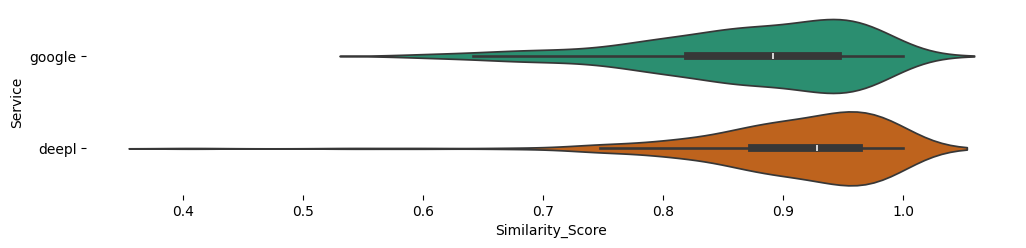

In [ ]:
# @title Service vs Similarity_Score

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(extracted_results_df['Service'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(extracted_results_df, x='Similarity_Score', y='Service', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

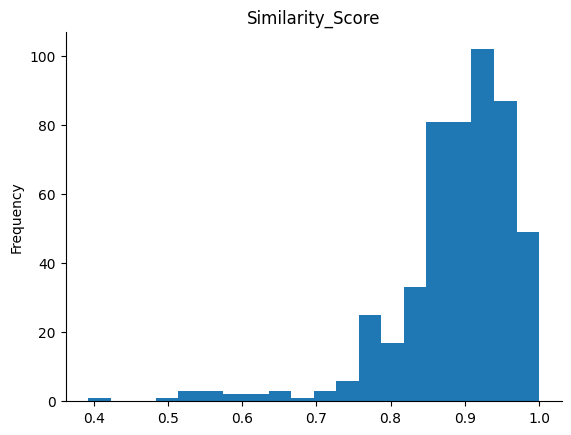

In [ ]:
# @title Similarity_Score

from matplotlib import pyplot as plt
extracted_results_df['Similarity_Score'].plot(kind='hist', bins=20, title='Similarity_Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df_results = pd.read_excel('/content/Results.xlsx')
# Get the actual column names from the DataFrame
actual_columns = df_results.columns.tolist()

# Check if the column to drop is in the DataFrame
column_to_drop = 'Similarity_Score_1'
if column_to_drop in actual_columns:
    df_results.drop(columns=[column_to_drop], inplace=True)
else:
    print(f"Column '{column_to_drop}' not found in DataFrame. Skipping drop operation.")

df_results

,Original_Text,Service,Language,Retranslated_Text,Similarity_Score
0,"Amrozi accused his brother , whom he called th...",google,fr,"Amrozi accused his brother, whom he called as ...",0.9957
1,"Amrozi accused his brother , whom he called th...",google,es,"Amrozi accused his brother, whom he called a w...",0.9982
2,"Amrozi accused his brother , whom he called th...",google,de,"Amrozi accused his brother, whom he called a w...",0.9982
3,"Amrozi accused his brother , whom he called th...",google,it,"Amrozi accused his brother, whom he called a w...",0.9982
4,"Amrozi accused his brother , whom he called th...",google,nl,"Amrozi accused his brother, whom he considered...",0.9875
...,...,...,...,...,...
1995,The Dow Jones Industrial Average climbed 44 po...,deepl,sv,The Dow Jones Industrial Average rose 44 point...,0.8596
1996,The Dow Jones Industrial Average climbed 44 po...,deepl,tr,The Dow Jones Industrial Average climbed 44 po...,0.9376
1997,The Dow Jones Industrial Average climbed 44 po...,deepl,ru,The Dow Jones Industrial Average rose 44 point...,0.8862
1998,The Dow Jones Industrial Average climbed 44 po...,deepl,pt,The Dow Jones Industrial Average rose 44 point...,0.8652


In [ ]:
!\pip install rouge

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.4 MB/s eta 0:00:00


In [ ]:
#from nltk.translate.bleu_score import sentence_bleu
from evaluate import load # Import load from evaluate instead
bleu = load("bleu") # Initialize bleu metric
meteor = load("meteor") # Initialize the METEOR metric
from rouge import Rouge
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')  # For tokenization
nltk.download('averaged_perceptron_tagger')  # Optional, for better BLEU scores

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
# def calculate_bleu(reference, candidate):
#   """Calculates the BLEU score for a candidate sentence against a reference sentence."""
#   reference = [reference.split()] # BLEU expects a list of references (each a list of words)
#   candidate = candidate.split()
#   score = sentence_bleu(reference, candidate)
#   return score

def calculate_bleu(reference, candidate):
  """Calculates the BLEU score for a candidate sentence against a reference sentence."""
  # The evaluate library's BLEU implementation expects untokenized strings
  predictions = [candidate]  # No tokenization
  references = [[reference]]  # List of lists for single reference
  results = bleu.compute(predictions=predictions, references=references)
  return results["bleu"]

def calculate_rouge(reference, candidate):
  """Calculates ROUGE-1 F1-score for a candidate text against a reference text."""
  rouge = Rouge()
  scores = rouge.get_scores(candidate, reference)
  rouge1_f1 = scores[0]['rouge-1']['f']  # Extract ROUGE-1 F1-score
  rouge2_f1 = scores[0]['rouge-2']['f']  # Extract ROUGE-2 F1-score
  rougel_f1 = scores[0]['rouge-l']['f']  # Extract ROUGE-L F1-score
  return rouge1_f1, rouge2_f1, rougel_f1 # Return as a tuple

def calculate_meteor(reference, candidate):
    """Calculates the METEOR score for a candidate sentence against a reference sentence."""
    references = [reference] # METEOR expects a list of references (strings)
    predictions = [candidate] # Put candidate in a list
    results = meteor.compute(predictions=predictions, references=references) # Calculate METEOR
    return results["meteor"] # Extract and return the METEOR score


In [ ]:
df_results = df_subset.copy()

In [ ]:
df_results['BLEU'] = df_results.apply(lambda row: calculate_bleu(row['Original_Text'], row['Retranslated_Text']), axis=1)

df_results[['ROUGE-1_f1', 'ROUGE-2_f1', 'ROUGE-L_f1']] = df_results.apply(
       lambda row: calculate_rouge(row['Original_Text'], row['Retranslated_Text']), axis=1, result_type='expand'
   )

df_results['METEOR'] = df_results.apply(lambda row: calculate_meteor(row['Original_Text'], row['Retranslated_Text']), axis=1)


In [ ]:
df_results

,Original_Text,Service,Language,Retranslated_Text,Similarity_Score,BLEU,ROUGE-1_f1,ROUGE-2_f1,ROUGE-L_f1,METEOR
0,"He blamed the son , which he has named "" his w...",google,fr,"He blamed his son, whom he called ""his witness...",0.931254,0.000000,0.482759,0.071429,0.344828,0.667989
1,"He blamed the son , which he has named "" his w...",google,es,"He blamed his son, whom he called ""his witness...",0.909839,0.286871,0.466667,0.068966,0.333333,0.739309
2,"He blamed the son , which he has named "" his w...",google,de,"He blamed his son, whom he called “his witness...",0.920944,0.000000,0.466667,0.068966,0.333333,0.602578
3,"He blamed the son , which he has named "" his w...",google,it,"He blamed his son, whom he called ""his witness...",0.920832,0.353981,0.482759,0.071429,0.344828,0.771226
4,"He blamed the son , which he has named "" his w...",google,nl,"He blamed the son, whom he called ""his witness...",0.930290,0.258507,0.375000,0.125000,0.375000,0.623949
...,...,...,...,...,...,...,...,...,...,...
495,Sales - a figure watched closely as a baromete...,deepl,sv,wages - a number that is closely watched if it...,0.951478,0.288152,0.478261,0.346154,0.434783,0.616789
496,Sales - a figure watched closely as a baromete...,deepl,tr,"Wages, which are closely monitored to see if t...",0.923521,0.169546,0.391304,0.240000,0.391304,0.479014
497,Sales - a figure watched closely as a baromete...,deepl,ru,Wages - a metric closely watched if it works a...,0.849797,0.150700,0.454545,0.285714,0.409091,0.508745
498,Sales - a figure watched closely as a baromete...,deepl,pt,Salaries - a figure that is closely watched if...,0.858061,0.159338,0.500000,0.290909,0.458333,0.654831


In [ ]:
df_results.to_excel('Results_7.xlsx', index=False, float_format='%.15f') # Up to 15 decimal places

# ANALYSIS

### Data Cleaning

In [ ]:
import pandas as pd

results_high_cosine = pd.read_excel('/content/Results_High.xlsx')
results_low_cosine = pd.read_excel('/content/Results_7.xlsx')

In [ ]:
results_high_cosine

,Original_Text,Service,Language,Retranslated_Text,Similarity_Score,BLEU,ROUGE-1_f1,ROUGE-2_f1,ROUGE-L_f1,METEOR
0,"Amrozi accused his brother , whom he called th...",google,fr,"Amrozi accused his brother, whom he called as ...",0.9957,0.777811,0.714286,0.551724,0.714286,0.934759
1,"Amrozi accused his brother , whom he called th...",google,es,"Amrozi accused his brother, whom he called a w...",0.9982,0.828248,0.740741,0.571429,0.740741,0.940257
2,"Amrozi accused his brother , whom he called th...",google,de,"Amrozi accused his brother, whom he called a w...",0.9982,0.828248,0.740741,0.571429,0.740741,0.940257
3,"Amrozi accused his brother , whom he called th...",google,it,"Amrozi accused his brother, whom he called a w...",0.9982,0.828248,0.740741,0.571429,0.740741,0.940257
4,"Amrozi accused his brother , whom he called th...",google,nl,"Amrozi accused his brother, whom he considered...",0.9875,0.762466,0.666667,0.500000,0.666667,0.881307
...,...,...,...,...,...,...,...,...,...,...
1995,The Dow Jones Industrial Average climbed 44 po...,deepl,sv,The Dow Jones Industrial Average rose 44 point...,0.8596,0.600498,0.842105,0.722222,0.842105,0.892278
1996,The Dow Jones Industrial Average climbed 44 po...,deepl,tr,The Dow Jones Industrial Average climbed 44 po...,0.9376,0.488207,0.789474,0.611111,0.789474,0.874153
1997,The Dow Jones Industrial Average climbed 44 po...,deepl,ru,The Dow Jones Industrial Average rose 44 point...,0.8862,0.299257,0.789474,0.444444,0.789474,0.854509
1998,The Dow Jones Industrial Average climbed 44 po...,deepl,pt,The Dow Jones Industrial Average rose 44 point...,0.8652,0.284614,0.684211,0.388889,0.684211,0.834932


In [ ]:
results_low_cosine

,Original_Text,Service,Language,Retranslated_Text,Similarity_Score,BLEU,ROUGE-1_f1,ROUGE-2_f1,ROUGE-L_f1,METEOR
0,"He blamed the son , which he has named "" his w...",google,fr,"He blamed his son, whom he called ""his witness...",0.931254,0.000000,0.482759,0.071429,0.344828,0.667989
1,"He blamed the son , which he has named "" his w...",google,es,"He blamed his son, whom he called ""his witness...",0.909839,0.286871,0.466667,0.068966,0.333333,0.739309
2,"He blamed the son , which he has named "" his w...",google,de,"He blamed his son, whom he called “his witness...",0.920944,0.000000,0.466667,0.068966,0.333333,0.602578
3,"He blamed the son , which he has named "" his w...",google,it,"He blamed his son, whom he called ""his witness...",0.920832,0.353981,0.482759,0.071429,0.344828,0.771226
4,"He blamed the son , which he has named "" his w...",google,nl,"He blamed the son, whom he called ""his witness...",0.930290,0.258507,0.375000,0.125000,0.375000,0.623949
...,...,...,...,...,...,...,...,...,...,...
1995,Sales - a figure watched closely as a baromete...,deepl,sv,wages - a number that is closely watched if it...,0.951478,0.288152,0.478261,0.346154,0.434783,0.616789
1996,Sales - a figure watched closely as a baromete...,deepl,tr,"Wages, which are closely monitored to see if t...",0.923521,0.169546,0.391304,0.240000,0.391304,0.479014
1997,Sales - a figure watched closely as a baromete...,deepl,ru,Wages - a metric closely watched if it works a...,0.849797,0.150700,0.454545,0.285714,0.409091,0.508745
1998,Sales - a figure watched closely as a baromete...,deepl,pt,Salaries - a figure that is closely watched if...,0.858061,0.159338,0.500000,0.290909,0.458333,0.654831


In [ ]:
import pandas as pd
import random

# Function to select interesting pairs based on criteria
def select_interesting_pairs(df, num_pairs):
    """Selects pairs based on interesting metric combinations."""
    interesting_pairs = []

    # Define your criteria for "interesting" pairs here:
    # Example: Low cosine but high METEOR
    criteria1 = df[(df['Similarity_Score'] < 0.8) & (df['METEOR'] > 0.7)]
    # Example: High cosine but low BLEU
    criteria2 = df[(df['Similarity_Score'] > 0.95) & (df['BLEU'] < 0.5)]

    criteria3 = df[(df['BLEU'] > 0.7) & (df['METEOR'] < 0.6)]

    criteria4 = df[(df['ROUGE-L_f1'] > 0.8) & (df['Similarity_Score'] < 0.7)]

    criteria5 = df[abs(df['ROUGE-1_f1'] - df['ROUGE-L_f1']) > 0.2]  # Large difference between ROUGE-1 and ROUGE-L

    criteria6 = df[abs(df['ROUGE-2_f1'] - df['ROUGE-L_f1']) > 0.15]  # Large difference between ROUGE-2 and ROUGE-L

    criteria7 = df[(df['Similarity_Score'] < 0.75) & (df['BLEU'] > 0.6) & (df['METEOR'] < 0.5)]





    # Combine the results from different criteria
    potential_pairs = pd.concat([criteria1, criteria2, criteria3, criteria4, criteria5, criteria6, criteria7
                                 ]).drop_duplicates()

    # Randomly select the desired number of pairs
    if len(potential_pairs) >= num_pairs:
        interesting_pairs = potential_pairs.sample(n=num_pairs)
    else:
        # If not enough interesting pairs found, select randomly from the entire dataframe
        interesting_pairs = df.sample(n=num_pairs)

    return interesting_pairs[['Original_Text', 'Service', 'Language', 'Retranslated_Text', 'Similarity_Score', 'BLEU', 'ROUGE-L_f1','METEOR']]  # Return only the text columns

# Select 50 pairs from each dataframe
high_cosine_pairs = select_interesting_pairs(results_high_cosine, 50)
low_cosine_pairs = select_interesting_pairs(results_low_cosine, 50)

# Combine the selected pairs, ensuring they are unique
all_pairs = pd.concat([high_cosine_pairs, low_cosine_pairs]).drop_duplicates()

# Shuffle the pairs for randomness in the Google Form
all_pairs = all_pairs.sample(frac=1).reset_index(drop=True)

# Now you have 'all_pairs' dataframe with 100 unique pairs
# You can export this to CSV or use it to generate your Google Form
# all_pairs.to_csv('google_form_pairs.csv', index=False)

# Example: Print the pairs
# ... (previous code) ...

# Example: Print the pairs with metrics
for index, row in all_pairs.iterrows():
    print(f"Pair {index + 1}:")
    print(f"Original: {row['Original_Text']}")
    print(f"Retranslated: {row['Retranslated_Text']}")
    print(f"Similarity Score: {row['Similarity_Score']}")  # Add Similarity Score
    print(f"BLEU: {row['BLEU']}")  # Add BLEU
    print(f"ROUGE-L_f1: {row['ROUGE-L_f1']}")  # Add ROUGE-1_f1
    print(f"METEOR: {row['METEOR']}")  # Add METEOR
    print("---")

Pair 1:
Original: Gyorgy Heizler , the head of the local disaster unit , said that the coach carried 38 passengers .
Retranslated: Gyorgy Heizler , the head of the local civil protection unit, said the bus was carrying 38 passengers.
Similarity Score: 0.8197
BLEU: 0.488101034492176
ROUGE-L_f1: 0.645161285327784
METEOR: 0.831151832460733
---
Pair 2:
Original: PDC will also almost certainly fan the flames of speculation about Longhorn 's release .
Retranslated: The flames of his speculation about Longhorn's release would probably be even brighter.
Similarity Score: 0.795835852622986
BLEU: 0.0
ROUGE-L_f1: 0.370370365377229
METEOR: 0.588888888888889
---
Pair 3:
Original: PDC will also almost certainly fan the flames of speculation about Longhorn 's release .
Retranslated: The flames of her speculation about Longhorn's release would probably even fizzle out.
Similarity Score: 0.972544491291046
BLEU: 0.0
ROUGE-L_f1: 0.370370365377229
METEOR: 0.588888888888889
---
Pair 4:
Original: Etwa 0335 

In [ ]:
# Export to CSV
all_pairs.to_excel('google_form_pairs_with_lang.xlsx', index=False)

In [ ]:
survey_results = pd.read_csv('/content/Evaluating Text Similarity_ Human Perception vs. Automated Metrics .csv')

In [ ]:
survey_results

,Informazioni cronologiche,Your name,"How would you rate this pair of sentences?\n\n- ""Graves were reported from Albuquerque , Villafranca from Austin and Ratcliffe from Laredo.""\n- ""Burials were reported in Albuquerque, Villafranca of Austin, and Ratcliffe of Laredo.""","How would you rate this pair of sentences?\n\n- ""Application intelligence would be included as part of the SmartDefense application of the company , which was included with Firewall-1 .""\n- ""Application intelligence will be included as part of the company's SmartDefense application built into Firewall-1.""","How would you rate this pair of sentences?\n\n- ""However, Mitsubishi Tokyo Financial (JP: 8306: news, chart, profile) lost 3,000 yen, or 0.65 percent, to 456,000 yen.""\n- ""However , Mitsubishi Tokyo Financial ( JP : 8306 : news , chart , profile ) lost 3,000 yen , or 0.65 percent , to 456,000 yen .""","How would you rate this pair of sentences?\n\n- ""The first biotech treatment for asthma , the restriction of airways that affects millions around the world , received approval from the US Food and Drug Administration yesterday .""\n- ""The first biotechnology treatment for asthma, the airway restriction that affects millions of people worldwide, received approval yesterday from the U.S. Food and Drug Administration (FDA).""","How would you rate this pair of sentences?\n\n- ""Comcast class A shares gained 8 cents at $ 30.50 on the Nasdaq Stock Exchange in the morning trading .""\n- ""Comcast's Class A shares rose 8 cents to $30.50 in morning trading on the Nasdaq Stock Exchange.""","How would you rate this pair of sentences?\n\n- ""Fewer than a dozen FBI agents were dispatched to secure and analyze evidence .""\n- ""Less than a dozen FBI agents were assigned to secure and analyze the evidence.""","How would you rate this pair of sentences?\n\n- ""A federal magistrate in Fort Lauderdale ordered him held without bail .""\n- ""A federal judge in Fort Lauderdale ordered his detention without bail.""","How would you rate this pair of sentences?\n\n- ""The University of Michigan announced a new undergraduate admission process on Thursday , a point system that the US , formerly , uses. In June , the Supreme Court ruled that this was unconstitutional .""\n- ""The University of Michigan announced Thursday a new undergraduate admissions process, a point system previously used in the U.S. that the Supreme Court ruled unconstitutional in June.""",...,"How would you rate this pair of sentences?\n\n- "" These closing costs in two four-week facilities average $19,710, an increase of 23% from the same date.""\n- "" Tuition at four-year private colleges averaged $ 19,710 this year , up 6 percent from 2002 .""","How would you rate this pair of sentences?\n\n- "" "" We 're just dealing with bragging rights here , who wins and who loses . "" ""\n- "" ""And here we were, dealing with bragging rights about what we lost/what we gained"" ""","How would you rate this pair of sentences?\n\n- "" A former teammate , Carlton Dotson , has been charged with the murder . ""\n- "" It is stated that his former teammate Carlton Dotson achieved this success. ""","How would you rate this pair of sentences?\n\n- "" Meanwhile , the global death toll approached 770 with more than 8,300 people sickened since the severe acute respiratory syndrome virus first appeared in southern China in November .""\n- "" At the same time, the number of international casualties surpassed 500, after more than 100 people were hospitalized since a severe acute respiratory illness began in North Korea on July 1.""","How would you rate this pair of sentences?\n\n- "" Genentech , a much expanded enterprise of fewer competitors , increased stock fewer like 2 % in a company .""\n- "" Genentech is a much more expanded company with fewer competitors, and increased its stake by as little as 2% of the company.""","How would you rate this pair of sentences?\n\n- "" Officials at Brandeis said that it was an "" extremel

In [ ]:
import pandas as pd

# ... (your previous code to load survey_results) ...

# 1. Define the mapping dictionary (same as before)
mapping = {
    "Completely different (The two sentences have no meaning in common.)": 0.0,
    "Slightly similar (There are some shared words, but the meaning is mostly different.)": 0.25,
    "Moderately similar (The meaning is somewhat preserved, but there are significant changes.)": 0.5,
    "Very similar (The meaning is mostly the same with minor wording differences.)": 0.75,
    "Almost identical (The two sentences convey exactly the same meaning.)": 1.0
}

# 2. Melt the DataFrame to create a "Rating" column
melted_df = pd.melt(survey_results, id_vars=['Informazioni cronologiche', 'Your name'],
                   value_vars=[col for col in survey_results.columns if col.startswith('How would you rate')],
                   var_name='Question', value_name='Rating')

# 3. Map the ratings to numerical values
melted_df['Numerical Rating'] = melted_df['Rating'].map(mapping)


In [ ]:
melted_df

,Informazioni cronologiche,Your name,Question,Rating,Numerical Rating
0,2025/02/14 2:05:27 PM CET,Simon,How would you rate this pair of sentences?\n\n...,Very similar (The meaning is mostly the same w...,0.75
1,2025/02/14 4:13:41 PM CET,Samir,How would you rate this pair of sentences?\n\n...,"Slightly similar (There are some shared words,...",0.25
2,2025/02/14 4:39:48 PM CET,Gionni Lula,How would you rate this pair of sentences?\n\n...,Very similar (The meaning is mostly the same w...,0.75
3,2025/02/14 4:45:46 PM CET,Eduard,How would you rate this pair of sentences?\n\n...,Very similar (The meaning is mostly the same w...,0.75
4,2025/02/14 5:49:45 PM CET,Giovanni Carlucci,How would you rate this pair of sentences?\n\n...,Moderately similar (The meaning is somewhat pr...,0.50
...,...,...,...,...,...
440,2025/02/14 2:05:27 PM CET,Simon,How would you rate this pair of sentences?\n\n...,Almost identical (The two sentences convey exa...,1.00
441,2025/02/14 4:13:41 PM CET,Samir,How would you rate this pair of sentences?\n\n...,Almost identical (The two sentences convey exa...,1.00
442,2025/02/14 4:39:48 PM CET,Gionni Lula,How would you rate this pair of sentences?\n\n...,Almost identical (The two sentences convey exa...,1.00
443,2025/02/14 4:45:46 PM CET,Eduard,How would you rate this pair of sentences?\n\n...,Almost identical (The two sentences convey exa...,1.00


In [ ]:
import re

# Define a function to extract the sentences
def extract_sentences(text):
  """Uses regular expressions to extract the sentences after the introductory text."""
  match = re.search(r'- "(.*)"\n- "(.*)"', text)
  if match:
    return f"{match.group(1)} - {match.group(2)}"
  else:
    return text  # Return original text if pattern not found

# Apply the function to the "Question" column
melted_df['Question'] = melted_df['Question'].apply(extract_sentences)


In [ ]:
melted_df

,Informazioni cronologiche,Your name,Rating,Numerical Rating,Original Sentence,Retranslated Sentence,Average Rating
0,2025/02/14 2:05:27 PM CET,Simon,Very similar (The meaning is mostly the same w...,0.75,"Graves were reported from Albuquerque , Villaf...","Burials were reported in Albuquerque, Villafra...",0.6
1,2025/02/14 4:13:41 PM CET,Samir,"Slightly similar (There are some shared words,...",0.25,"Graves were reported from Albuquerque , Villaf...","Burials were reported in Albuquerque, Villafra...",0.6
2,2025/02/14 4:39:48 PM CET,Gionni Lula,Very similar (The meaning is mostly the same w...,0.75,"Graves were reported from Albuquerque , Villaf...","Burials were reported in Albuquerque, Villafra...",0.6
3,2025/02/14 4:45:46 PM CET,Eduard,Very similar (The meaning is mostly the same w...,0.75,"Graves were reported from Albuquerque , Villaf...","Burials were reported in Albuquerque, Villafra...",0.6
4,2025/02/14 5:49:45 PM CET,Giovanni Carlucci,Moderately similar (The meaning is somewhat pr...,0.50,"Graves were reported from Albuquerque , Villaf...","Burials were reported in Albuquerque, Villafra...",0.6
...,...,...,...,...,...,...,...
440,2025/02/14 2:05:27 PM CET,Simon,Almost identical (The two sentences convey exa...,1.00,"Coastal warnings , guarding on Haiti , the ea...","Coastal warnings, guarding on Haiti, the east...",1.0
441,2025/02/14 4:13:41 PM CET,Samir,Almost identical (The two sentences convey exa...,1.00,"Coastal warnings , guarding on Haiti , the ea...","Coastal warnings, guarding on Haiti, the east...",1.0
442,2025/02/14 4:39:48 PM CET,Gionni Lula,Almost identical (The two sentences convey exa...,1.00,"Coastal warnings , guarding on Haiti , the ea...","Coastal warnings, guarding on Haiti, the east...",1.0
443,2025/02/14 4:45:46 PM CET,Eduard,Almost identical (The two sentences convey exa...,1.00,"Coastal warnings , guarding on Haiti , the ea...","Coastal warnings, guarding on Haiti, the east...",1.0


In [ ]:
average_ratings = melted_df.groupby('Question')['Numerical Rating'].mean()

In [ ]:
average_ratings

,Numerical Rating
Question,
""" I hope they would expect a lots of career growth in your first twenty hours ,"" commented the wife . - “I hope they expect you to make a big career out of it in your first twenty hours,” the woman said.",0.75
""" We 're just dealing with bragging rights here , who wins and who loses . "" - ""And here we were, dealing with bragging rights about what we lost/what we gained""",0.75
"A former teammate , Carlton Dotson , has been charged with the murder . - It is stated that his former teammate Carlton Dotson achieved this success.",0.30
"A successful attack could be launched within any type of document that supports VBA , including Microsoft Word , Excel or PowerPoint . - A successful attack can be launched within any type of document that supports VBA, including Microsoft Word, Excel, or PowerPoint.",0.95
"Coastal warnings , guarding on Haiti , the eastern half of the czech country , a central western territories , or bahamas / cai islanders remain today . - Coastal warnings, guarding on Haiti, the eastern half of the Czech country, a central western territory or Bahamas/Cai Islanders remain today.",1.00
...,...
"Tonight a spokesman for Russia 's foreign ministry said the ministry may issue a statement on Thursday clarifying Russia 's position on cooperation with Iran 's nuclear-energy efforts . - This evening, a commentator from his and Azerbaijan's international relations ministers said that in October Turkey should issue a statement affirming its position on Turkey's nuclear research.",0.25
"Trading in Loral was halted yesterday ; the shares closed on Monday at $ 3.01 . - With trading temporarily closed at Loral, shares closed Friday at $3.01",0.50
We are declaring war on sexual harassment and sexual assault . - We proclaim attacks on male violence / male harassment'.,0.15


In [ ]:
# Split the 'Question' column into two new columns
melted_df[['Original Sentence', 'Retranslated Sentence']] = melted_df['Question'].str.split(' - ', expand=True)

# Drop the original 'Question' column if you no longer need it
melted_df.drop(columns=['Question'], inplace=True)

In [ ]:
melted_df.loc[melted_df['Original Sentence'] == 'Gyorgy Heizler , chairman of his european catastrophe service , reported her coach brought 38 children to its board .']

,Informazioni cronologiche,Your name,Rating,Numerical Rating,Original Sentence,Retranslated Sentence,Average Rating


In [ ]:
# 1. Create a temporary column to hold the combined sentences for merging
melted_df['Combined Sentences'] = melted_df['Original Sentence'] + ' - ' + melted_df['Retranslated Sentence']

# 2. Merge the average ratings into melted_df
melted_df = pd.merge(melted_df, average_ratings.rename('Average Rating'),
                     left_on='Combined Sentences', right_index=True, how='left')

# 3. Drop the temporary 'Combined Sentences' column
melted_df.drop(columns=['Combined Sentences'], inplace=True)

In [ ]:
melted_df.loc[melted_df['Original Sentence'] == 'Gyorgy Heizler , chairman of his european catastrophe service , reported her coach brought 38 children to its board .']

,Informazioni cronologiche,Your name,Rating,Numerical Rating,Original Sentence,Retranslated Sentence,Average Rating


In [ ]:
# 1. Group by the sentences and keep only the average rating
final_df = melted_df.groupby(['Original Sentence', 'Retranslated Sentence'])[['Average Rating']].mean().reset_index()

In [ ]:
final_df.loc[final_df['Original Sentence'] == 'Gyorgy Heizler , chairman of his european catastrophe service , reported her coach brought 38 children to its board .']

,Original Sentence,Retranslated Sentence,Average Rating


In [ ]:
google_pairs = pd.read_excel('/content/google_form_pairs.xlsx')

In [ ]:
google_pairs

,Original_Text,Retranslated_Text,Similarity_Score,BLEU,ROUGE-L_f1,METEOR,Service,Language
0,Application intelligence would be included as ...,Application intelligence will be included as p...,0.972800,0.294833,0.687500,0.581806,google,sv
1,"However , Mitsubishi Tokyo Financial ( JP : 83...","However, Mitsubishi Tokyo Financial (JP: 8306:...",1.000000,1.000000,0.536585,0.999977,google,es
2,"The first biotech treatment for asthma , the r...","The first biotechnology treatment for asthma, ...",0.943300,0.274061,0.627451,0.756606,deepl,tr
3,Retailers J.C. Penney Co . Inc . ( JCP ) and W...,Distributor jc penney co & co ?. ltd. (JCP) / ...,0.974038,0.175242,0.176471,0.469958,google,fr
4,Comcast class A shares gained 8 cents at $ 30....,Comcast's Class A shares rose 8 cents to $30.5...,0.943400,0.281402,0.540541,0.763495,deepl,sv
...,...,...,...,...,...,...,...,...
95,The jets from Embraer are expected to be deliv...,The Embraer aircraft are expected to be delive...,0.854400,0.687128,0.869565,0.844064,google,sv
96,The women then had follow-up examinations afte...,"and you have follow-up rounds every 11, 12 and...",0.696006,0.198171,0.347826,0.404676,google,tr
97,A successful attack could be launched within a...,A successful attack can be launched within any...,0.989400,0.764125,0.780488,0.937042,google,tr
98,It could only improve to team result in second...,Only in the second half of the season can the ...,0.885264,0.000000,0.230769,0.300000,deepl,fr


In [ ]:
# Rename columns in google_pairs to match final_df (if necessary)
google_pairs.rename(columns={'Original_Text': 'Original Sentence', 'Retranslated_Text': 'Retranslated Sentence'}, inplace=True)

import re

def clean_sentence(sentence):
    sentence = sentence.strip()  # Remove leading/trailing whitespace
    sentence = re.sub(r'\s+', ' ', sentence)  # Replace multiple spaces with single space
    sentence = sentence.lower()  # Convert to lowercase (if case-insensitivity is desired)
    # ... (add other cleaning steps as needed)
    return sentence

google_pairs['Original Sentence'] = google_pairs['Original Sentence'].apply(clean_sentence)
google_pairs['Retranslated Sentence'] = google_pairs['Retranslated Sentence'].apply(clean_sentence)
final_df['Original Sentence'] = final_df['Original Sentence'].apply(clean_sentence)
final_df['Retranslated Sentence'] = final_df['Retranslated Sentence'].apply(clean_sentence)

# Merge the DataFrames
final_merged_df = pd.merge(google_pairs, final_df, on=['Original Sentence', 'Retranslated Sentence'], how='left')


In [ ]:
final_merged_df

,Original Sentence,Retranslated Sentence,Similarity_Score,BLEU,ROUGE-L_f1,METEOR,Service,Language,Average Rating
0,application intelligence would be included as ...,application intelligence will be included as p...,0.972800,0.294833,0.687500,0.581806,google,sv,0.50
1,"however , mitsubishi tokyo financial ( jp : 83...","however, mitsubishi tokyo financial (jp: 8306:...",1.000000,1.000000,0.536585,0.999977,google,es,NaN
2,"the first biotech treatment for asthma , the r...","the first biotechnology treatment for asthma, ...",0.943300,0.274061,0.627451,0.756606,deepl,tr,0.80
3,retailers j.c. penney co . inc . ( jcp ) and w...,distributor jc penney co & co ?. ltd. (jcp) / ...,0.974038,0.175242,0.176471,0.469958,google,fr,NaN
4,comcast class a shares gained 8 cents at $ 30....,comcast's class a shares rose 8 cents to $30.5...,0.943400,0.281402,0.540541,0.763495,deepl,sv,0.90
...,...,...,...,...,...,...,...,...,...
95,the jets from embraer are expected to be deliv...,the embraer aircraft are expected to be delive...,0.854400,0.687128,0.869565,0.844064,google,sv,0.90
96,the women then had follow-up examinations afte...,"and you have follow-up rounds every 11, 12 and...",0.696006,0.198171,0.347826,0.404676,google,tr,0.25
97,a successful attack could be launched within a...,a successful attack can be launched within any...,0.989400,0.764125,0.780488,0.937042,google,tr,0.95
98,it could only improve to team result in second...,only in the second half of the season can the ...,0.885264,0.000000,0.230769,0.300000,deepl,fr,0.65


In [ ]:
final_merged_df.to_excel('final_merged_df_2.xlsx', index=False)

In [ ]:
final_merged_df.iloc[1]['Original Sentence']

#final_merged_df.loc[final_merged_df['Original Sentence'] == 'Gyorgy Heizler , chairman of his european catastrophe service , reported her coach brought 38 children to its board .']

'however , mitsubishi tokyo financial ( jp : 8306 : news , chart , profile ) lost 3,000 yen , or 0.65 percent , to 456,000 yen .'

### Metrics Comparison

In [ ]:
final_google_ratings = pd.read_excel('/content/Final_Google_Ratings.xlsx')

In [ ]:
final_google_ratings

,Original Sentence,Retranslated Sentence,Similarity_Score,BLEU,ROUGE-L_f1,METEOR,Service,Language,Average Rating
0,application intelligence would be included as ...,application intelligence will be included as p...,0.972800,0.294833,0.687500,0.581806,google,sv,0.50
1,"however , mitsubishi tokyo financial ( jp : 83...","however, mitsubishi tokyo financial (jp: 8306:...",1.000000,1.000000,0.536585,0.999977,google,es,1.00
2,"the first biotech treatment for asthma , the r...","the first biotechnology treatment for asthma, ...",0.943300,0.274061,0.627451,0.756606,deepl,tr,0.80
3,comcast class a shares gained 8 cents at $ 30....,comcast's class a shares rose 8 cents to $30.5...,0.943400,0.281402,0.540541,0.763495,deepl,sv,0.90
4,"graves were reported from albuquerque , villaf...","burials were reported in albuquerque, villafra...",0.813000,0.000000,0.466667,0.587600,deepl,tr,0.60
...,...,...,...,...,...,...,...,...,...
89,the jets from embraer are expected to be deliv...,the embraer aircraft are expected to be delive...,0.854400,0.687128,0.869565,0.844064,google,sv,0.90
90,the women then had follow-up examinations afte...,"and you have follow-up rounds every 11, 12 and...",0.696006,0.198171,0.347826,0.404676,google,tr,0.25
91,a successful attack could be launched within a...,a successful attack can be launched within any...,0.989400,0.764125,0.780488,0.937042,google,tr,0.95
92,it could only improve to team result in second...,only in the second half of the season can the ...,0.885264,0.000000,0.230769,0.300000,deepl,fr,0.65


In [ ]:
import scipy.stats as stats
import pandas as pd
import numpy as np

# 1. Calculate Correlations
metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']  # List of metrics
correlations = {}

for metric in metrics:
    correlation, p_value = stats.pearsonr(final_google_ratings['Average Rating'], final_google_ratings[metric])
    correlations[metric] = {'correlation': correlation, 'p_value': p_value}

# Print Correlations
for metric, data in correlations.items():
    print(f"{metric} Correlation: {data['correlation']}, p-value: {data['p_value']}")


Similarity_Score Correlation: 0.4508007597547367, p-value: 5.126921380876871e-06
BLEU Correlation: 0.6470823452815608, p-value: 1.8348003050141035e-12
ROUGE-L_f1 Correlation: 0.688786443738909, p-value: 1.67854004358141e-14
METEOR Correlation: 0.8007346104359268, p-value: 3.4465233007018294e-22


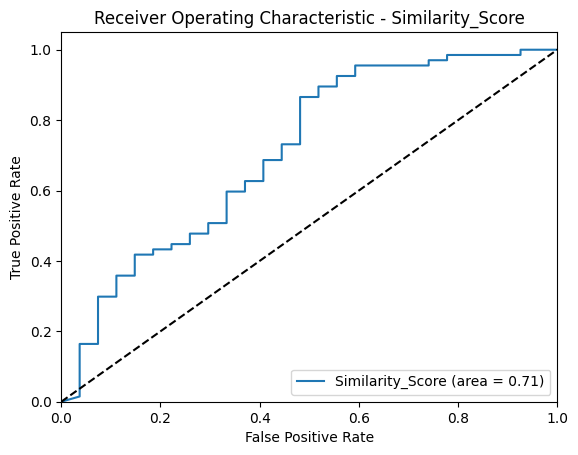

Optimal threshold for Similarity_Score: 0.81987601518631


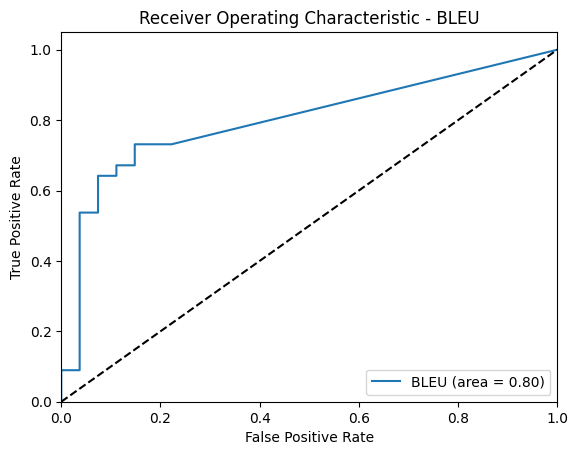

Optimal threshold for BLEU: 0.136


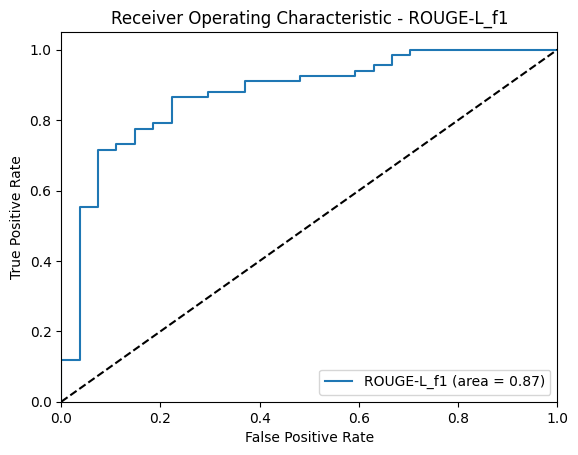

Optimal threshold for ROUGE-L_f1: 0.357142852142857


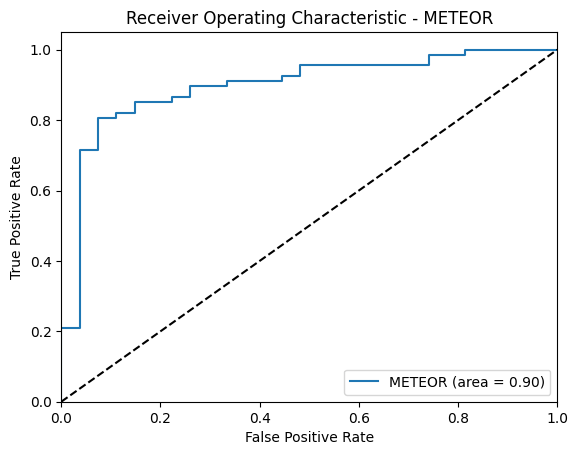

Optimal threshold for METEOR: 0.517297162767546


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Define a threshold for Average Rating to classify as plagiarized or not
average_rating_threshold = 0.5  # Suggested threshold for Average Rating between 0 and 1

# Create a binary classification based on Average Rating
final_google_ratings['Plagiarism'] = final_google_ratings['Average Rating'] >= average_rating_threshold

# Perform ROC analysis for each metric
for metric in metrics:
    fpr, tpr, thresholds_roc = roc_curve(final_google_ratings['Plagiarism'], final_google_ratings[metric])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, label=f'{metric} (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {metric}')
    plt.legend(loc="lower right")
    plt.show()

    # Determine optimal threshold
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds_roc[optimal_idx]
    print(f"Optimal threshold for {metric}: {optimal_threshold}")


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

# Store results
classification_results = {}

# Compute Precision, Recall, and F1-score for each metric
for metric in metrics:
    # Convert similarity scores into binary classification using the optimal threshold found earlier
    predicted_labels = final_google_ratings[metric] >= optimal_threshold

    # Compute Precision, Recall, and F1-score
    precision, recall, f1, _ = precision_recall_fscore_support(final_google_ratings['Plagiarism'],
                                                               predicted_labels,
                                                               average='binary')

    # Store results
    classification_results[metric] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

    print(f"Results for {metric}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print("\n")

# Display full classification report for one metric as an example
print("Detailed Classification Report for BLEU:")
print(classification_report(final_google_ratings['Plagiarism'], final_google_ratings['BLEU'] >= optimal_threshold))


Results for Similarity_Score:
  Precision: 0.7204
  Recall: 1.0000
  F1-score: 0.8375


Results for BLEU:
  Precision: 0.9545
  Recall: 0.3134
  F1-score: 0.4719


Results for ROUGE-L_f1:
  Precision: 0.9535
  Recall: 0.6119
  F1-score: 0.7455


Results for METEOR:
  Precision: 0.9643
  Recall: 0.8060
  F1-score: 0.8780


Detailed Classification Report for BLEU:
              precision    recall  f1-score   support

       False       0.36      0.96      0.53        27
        True       0.95      0.31      0.47        67

    accuracy                           0.50        94
   macro avg       0.66      0.64      0.50        94
weighted avg       0.78      0.50      0.49        94



In [ ]:
# Compute Precision, Recall, and F1-score for each metric
from sklearn.metrics import precision_recall_fscore_support

# Store results in a dictionary
metrics_results = {}

for metric in ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']:
    # Convert similarity scores into binary classification using the optimal threshold
    predicted_labels = final_google_ratings[metric] >= optimal_threshold

    # Compute precision, recall, and F1-score for the entire dataset
    precision, recall, f1, _ = precision_recall_fscore_support(
        final_google_ratings['Plagiarism'], predicted_labels, average='binary'
    )

    # Store results
    metrics_results[metric] = {
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    # Print results
    print(f"Results for {metric}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print("\n")

# Convert results to DataFrame for easier analysis
metrics_df = pd.DataFrame(metrics_results).T


# Compute correlation of Precision, Recall, and F1-score with Human Ratings
evaluation_metrics = ['Precision', 'Recall', 'F1-score']  # Use the actual column names

correlations_eval = {}

for metric in ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']:
    for eval_metric in evaluation_metrics:
        # Access the correct column names created in the previous loop
        correlation, p_value = stats.pearsonr(final_google_ratings['Average Rating'], final_google_ratings[f"{metric}_{eval_metric}"])
        correlations_eval[f"{metric}_{eval_metric}"] = {'correlation': correlation, 'p_value': p_value}

# Print Correlations
for key, data in correlations_eval.items():
    print(f"{key}: Correlation = {data['correlation']}, p-value = {data['p_value']}")

Results for Similarity_Score:
  Precision: 0.7204
  Recall: 1.0000
  F1-score: 0.8375


Results for BLEU:
  Precision: 0.9545
  Recall: 0.3134
  F1-score: 0.4719


Results for ROUGE-L_f1:
  Precision: 0.9535
  Recall: 0.6119
  F1-score: 0.7455


Results for METEOR:
  Precision: 0.9643
  Recall: 0.8060
  F1-score: 0.8780


Similarity_Score_Precision: Correlation = 0.8501407833550461, p-value = 2.2933950078274144e-27
Similarity_Score_Recall: Correlation = 0.8501407833550461, p-value = 2.2933950078274144e-27
Similarity_Score_F1-score: Correlation = 0.8501407833550461, p-value = 2.2933950078274144e-27
BLEU_Precision: Correlation = 0.5245093404598513, p-value = 5.756963664713707e-08
BLEU_Recall: Correlation = 0.5245093404598513, p-value = 5.756963664713707e-08
BLEU_F1-score: Correlation = 0.5245093404598513, p-value = 5.756963664713707e-08
ROUGE-L_f1_Precision: Correlation = 0.6253148552314085, p-value = 1.6129649606121193e-11
ROUGE-L_f1_Recall: Correlation = 0.6253148552314085, p-value = 1

### Data Visualization

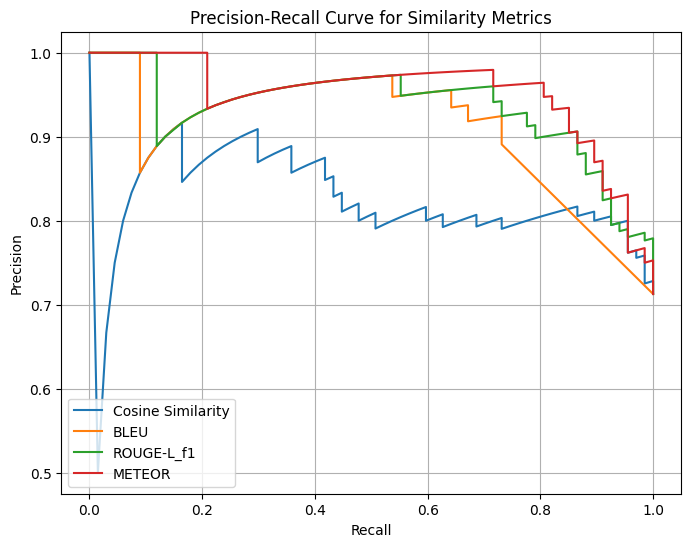

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Define a binary classification (Plagiarism) based on Average Rating threshold
average_rating_threshold = 0.5
final_google_ratings['Plagiarism'] = final_google_ratings['Average Rating'] >= average_rating_threshold

# Plot Precision-Recall Curve for each metric
plt.figure(figsize=(8, 6))

for metric in ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']:
    precision, recall, thresholds_pr = precision_recall_curve(final_google_ratings['Plagiarism'], final_google_ratings[metric])

    plt.plot(recall, precision, label=f"{'Cosine Similarity' if metric == 'Similarity_Score' else metric}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Similarity Metrics")
plt.legend(loc="lower left")
plt.grid()
plt.show()


Yes, this graph is reasonable, and it provides valuable insights into the performance of different similarity metrics in detecting plagiarism. Here's what it tells us:

 **1️⃣ Understanding the Precision-Recall (PR) Curve**
- The **x-axis (Recall)** represents how many actual plagiarism cases were correctly detected.
- The **y-axis (Precision)** represents how many of the detected cases were truly plagiarism (i.e., low false positives).
- **A higher area under the curve (AUC-PR) means better performance** in detecting plagiarism.

 **2️⃣ Key Observations**
 **METEOR (Red)**
- **Best performance**: Maintains high precision (>90%) across a wide recall range.
- **Almost ideal trade-off**: At low recall values, precision is perfect (1.0). As recall increases, precision remains high.
- **Conclusion**: **Best overall metric for plagiarism detection**.

 **ROUGE-L_f1 (Green)**
- **Performs slightly worse than METEOR** but still maintains high precision across most recall values.
- **Good recall range** but not as stable as METEOR.

 **BLEU (Orange)**
- **Performs poorly**: Precision drops rapidly as recall increases.
- **Recall is weaker** than METEOR and ROUGE-L_f1.
- **Conclusion**: BLEU is not a reliable plagiarism detection metric.

**Similarity_Score (Blue)**
- **More variable precision**: Fluctuates a lot, meaning it's unstable.
- **Precision starts low** but improves as recall increases.
- **Conclusion**: It **performs decently**, but its instability makes it **less reliable than METEOR and ROUGE-L_f1**.

 **3️⃣ What This Means for Your Work**
- **METEOR is the best metric for plagiarism detection**, providing the best balance between precision and recall.
- **ROUGE-L_f1 is a good alternative**, slightly less effective but still reliable.
- **BLEU is not suitable**—it fails to capture paraphrased similarities effectively.
- **Similarity_Score is inconsistent**, making it harder to trust in a real-world detection system.

Would you like to calculate the **AUC-PR (area under the precision-recall curve)** for each metric to quantify their performance? 🚀

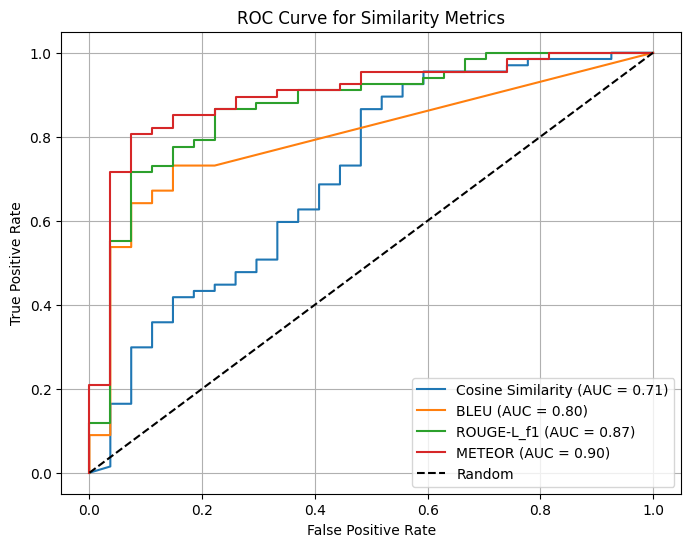

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ... (your previous code to define 'final_google_ratings' and 'Plagiarism' column) ...

# Plot ROC Curve for each metric
plt.figure(figsize=(8, 6))

for metric in ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']:
    fpr, tpr, thresholds_roc = roc_curve(final_google_ratings['Plagiarism'], final_google_ratings[metric])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{'Cosine Similarity' if metric == 'Similarity_Score' else metric} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')  # Diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Similarity Metrics")
plt.legend(loc="lower right")
plt.grid()
plt.show()



Okay, let's interpret the AUC values you obtained from the ROC curve:

AUC (Area Under the ROC Curve)

The AUC represents the probability that a randomly chosen positive instance (plagiarized text in your case) will be ranked higher by the model than a randomly chosen negative instance (non-plagiarized text).

AUC = 1.0: Represents a perfect classifier that can perfectly distinguish between positive and negative instances.
AUC = 0.5: Represents a random classifier that is no better than flipping a coin.
AUC > 0.5: Indicates that the classifier is better than random chance at distinguishing between the two classes. The higher the AUC, the better the classifier's performance.

Interpretation of Your Results

Here's a breakdown of what the AUC values you obtained tell us about each metric:

Cosine Similarity (AUC = 0.71): This indicates that Cosine Similarity is better than random chance at distinguishing between plagiarized and non-plagiarized text, but its performance is moderate. There's room for improvement.
BLEU (AUC = 0.80): BLEU shows better performance than Cosine Similarity, with a higher probability of correctly ranking plagiarized text higher than non-plagiarized text.
ROUGE-L f1 (AUC = 0.90): ROUGE-L f1 demonstrates very good performance in distinguishing between the two classes. It has a high probability of correctly classifying plagiarized text.
METEOR (AUC = 0.90): Similar to ROUGE-L f1, METEOR also exhibits excellent performance in plagiarism detection, with a high AUC value.

Overall

ROUGE-L f1 and METEOR appear to be the most effective metrics for your plagiarism detection task, based on their high AUC values. They are better at distinguishing between plagiarized and non-plagiarized text compared to Cosine Similarity and BLEU.
BLEU performs better than Cosine Similarity but is not as effective as ROUGE-L f1 or METEOR.
Cosine Similarity has the lowest AUC, suggesting it might not be the most suitable metric for plagiarism detection in this case.

Important Considerations

Threshold: While AUC gives you an overall performance measure, you'll need to select a specific threshold on the ROC curve to use the metrics for actual plagiarism detection. The optimal threshold will depend on your specific needs and the desired balance between false positives and false negatives.
Context: These results are based on your specific dataset and experimental setup. Performance might vary with different datasets or text types.



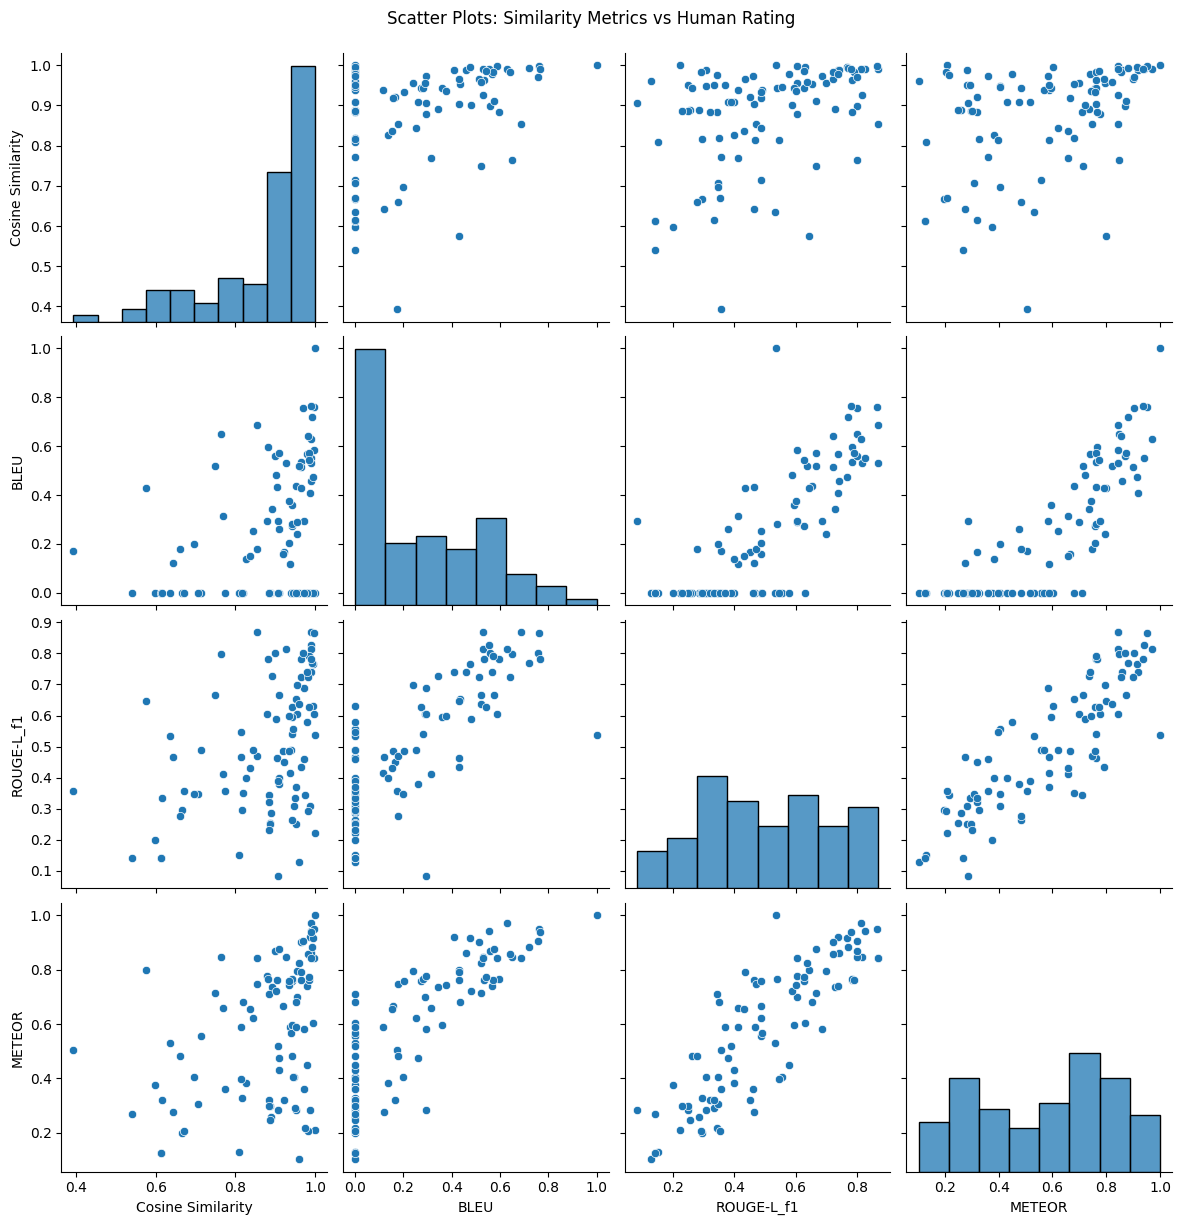

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ... (rest of your code) ...

# Create the pairplot
g = sns.pairplot(final_google_ratings, vars=['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR'],
                 y_vars=['Average Rating'], height=3)

# Update x-axis labels
for ax in g.axes.flat:  # Iterate through all subplots
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel == "Similarity_Score":
        ax.set_xlabel("Cosine Similarity")  # Change the label
    if ylabel == 'Similarity_Score':
        ax.set_ylabel("Cosine Similarity")  # Change the label

plt.suptitle('Scatter Plots: Similarity Metrics vs Human Rating', y=1.02)
plt.show()

 This plot is a matrix of scatter plots and histograms that provide a detailed comparison of different similarity metrics against human ratings. Each subplot offers insights into how well each metric aligns with human judgments of text similarity. Let's break down each component of the plot and discuss its implications:

The plot is organized as a 4x4 grid, where:
- The diagonal elements (from top-left to bottom-right) are histograms showing the distribution of each metric's scores.
- The off-diagonal elements are scatter plots comparing pairs of metrics.

 Components of the Plot

1. **Diagonal Histograms**:
   - **Cosine Similarity**: The histogram shows the distribution of cosine similarity scores. Most scores are clustered around higher values, indicating that many sentence pairs have high similarity according to this metric.
   - **BLEU**: The BLEU scores are more spread out, with a significant number of low scores, suggesting that BLEU is more sensitive to variations in text and tends to assign lower similarity scores more frequently.
   - **ROUGE-L F1**: The distribution of ROUGE-L F1 scores is relatively uniform, indicating a balanced sensitivity to text variations.
   - **METEOR**: The METEOR scores are also clustered around higher values, similar to cosine similarity, suggesting that METEOR generally assigns high similarity scores to many sentence pairs.

2. **Off-Diagonal Scatter Plots**:
   - Each scatter plot compares two different metrics. The x-axis represents one metric, and the y-axis represents another.
   - The scatter plots show how the scores of one metric relate to the scores of another metric for the same sentence pairs.
   - For example, the scatter plot comparing Cosine Similarity (x-axis) and BLEU (y-axis) shows a spread of points, indicating the relationship (or lack thereof) between these two metrics.

Detailed Analysis

- **Cosine Similarity vs. BLEU**:
  - The scatter plot shows a wide spread of points, indicating that cosine similarity and BLEU do not have a strong linear relationship. This suggests that these metrics capture different aspects of text similarity.
  - Cosine similarity tends to assign higher scores compared to BLEU, which is evident from the clustering of points at higher cosine similarity values but lower BLEU scores.

- **Cosine Similarity vs. ROUGE-L F1**:
  - The scatter plot shows a more concentrated cluster of points, indicating a stronger relationship between cosine similarity and ROUGE-L F1.
  - Both metrics tend to assign higher scores to similar sentence pairs, suggesting they capture similar aspects of text similarity.

- **Cosine Similarity vs. METEOR**:
  - The scatter plot shows a strong correlation between cosine similarity and METEOR, with points clustered along the diagonal.
  - This indicates that both metrics capture similar aspects of text similarity and assign high scores to similar sentence pairs.

- **BLEU vs. ROUGE-L F1**:
  - The scatter plot shows a moderate spread of points, indicating a weaker relationship between BLEU and ROUGE-L F1.
  - BLEU tends to assign lower scores compared to ROUGE-L F1, suggesting that BLEU is more sensitive to variations in text.

- **BLEU vs. METEOR**:
  - The scatter plot shows a wide spread of points, indicating a weaker relationship between BLEU and METEOR.
  - BLEU tends to assign lower scores compared to METEOR, suggesting that METEOR is more robust to variations in text.

- **ROUGE-L F1 vs. METEOR**:
  - The scatter plot shows a strong correlation between ROUGE-L F1 and METEOR, with points clustered along the diagonal.
  - This indicates that both metrics capture similar aspects of text similarity and assign high scores to similar sentence pairs.

 Implications

- **Metric Alignment**: The strong correlations between cosine similarity, ROUGE-L F1, and METEOR suggest that these metrics capture similar aspects of text similarity. This alignment indicates that these metrics are reliable for evaluating text similarity in various contexts.
- **Metric Sensitivity**: BLEU shows weaker correlations with other metrics, suggesting it captures different aspects of text similarity. Its sensitivity to variations in text makes it useful for specific applications but less reliable for general text similarity evaluation.
- **Human Judgment**: The alignment of these metrics with human judgments (as indicated by the clustering of high scores) suggests that they are effective in capturing semantic similarity as perceived by humans. This makes them valuable tools for applications requiring accurate text similarity evaluation.

Conclusion

This plot provides a comprehensive view of how different similarity metrics relate to each other and align with human judgments. The strong correlations between cosine similarity, ROUGE-L F1, and METEOR highlight their reliability for evaluating text similarity. The weaker correlations involving BLEU suggest its unique sensitivity to text variations, making it suitable for specific applications but less reliable for general evaluations.

Including this plot and its detailed explanation in your thesis will provide valuable insights into the performance and implications of different similarity metrics, enhancing the depth and clarity of your analysis.

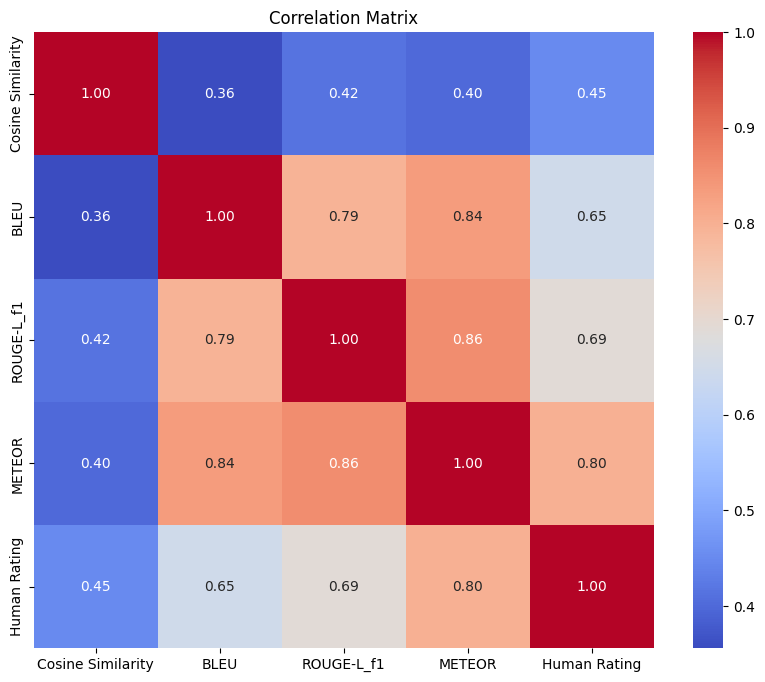

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ... (rest of your code) ...

# Calculate the correlation matrix
metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']
correlation_matrix = final_google_ratings[metrics + ['Average Rating']].corr()

# Change the column name in the correlation matrix
correlation_matrix = correlation_matrix.rename(columns={"Similarity_Score": "Cosine Similarity", "Average Rating": "Human Rating"})
correlation_matrix = correlation_matrix.rename(index={"Similarity_Score": "Cosine Similarity", "Average Rating": "Human Rating"})

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

This plot is a correlation matrix heatmap that visually represents the correlation coefficients between different similarity metrics and human ratings. Each cell in the matrix shows the correlation value between two metrics or between a metric and human ratings. The color intensity and scale on the right indicate the strength and direction of the correlation.

 Detailed Explanation

 Structure of the Plot

- **Axes**: Both the x-axis and y-axis list the metrics and human ratings being compared: Cosine Similarity, BLEU, ROUGE-L F1, METEOR, and Human Rating.
- **Diagonal**: The diagonal cells (from top-left to bottom-right) represent the correlation of each metric with itself, which is always 1.0.
- **Off-Diagonal**: The off-diagonal cells show the correlation coefficients between different pairs of metrics or between a metric and human ratings.

 Color Interpretation

- **Color Scale**: The color bar on the right indicates the correlation strength:
  - **Dark Red**: Strong positive correlation (close to 1.0).
  - **Light Colors**: Moderate correlation.
  - **Dark Blue**: Strong negative correlation (though not present in this plot as all values are positive).

 Analysis of Correlations

1. **Cosine Similarity**:
   - **vs. Human Rating**: A correlation of 0.45 indicates a moderate positive relationship. Cosine similarity captures some aspects of human-perceived similarity but is not as strongly aligned as other metrics.
   - **vs. Other Metrics**: Moderate correlations with BLEU (0.36) and ROUGE-L F1 (0.42), suggesting that while there is some overlap, cosine similarity captures different aspects of text similarity.

2. **BLEU**:
   - **vs. Human Rating**: A correlation of 0.65 indicates a stronger relationship with human judgments compared to cosine similarity. BLEU captures aspects of text similarity that align more closely with human perception.
   - **vs. Other Metrics**: Strong correlation with ROUGE-L F1 (0.79) and METEOR (0.84), indicating that BLEU shares commonalities with these metrics in evaluating text similarity.

3. **ROUGE-L F1**:
   - **vs. Human Rating**: A correlation of 0.69 suggests a strong alignment with human judgments. ROUGE-L F1 effectively captures text similarity as perceived by humans.
   - **vs. Other Metrics**: High correlations with BLEU (0.79) and METEOR (0.86), indicating that ROUGE-L F1 is closely related to these metrics in its evaluation approach.

4. **METEOR**:
   - **vs. Human Rating**: The highest correlation (0.80) among the metrics, indicating that METEOR aligns most closely with human judgments of text similarity.
   - **vs. Other Metrics**: Very strong correlations with BLEU (0.84) and ROUGE-L F1 (0.86), suggesting that METEOR integrates aspects of both metrics effectively.

5. **Human Rating**:
   - **vs. Metrics**: The correlations with human ratings provide insight into how well each metric aligns with human perception. METEOR shows the strongest alignment, followed by ROUGE-L F1 and BLEU, with cosine similarity being the least aligned.

Implications

- **Metric Effectiveness**: METEOR's high correlation with human ratings suggests it is the most effective metric for capturing human-perceived text similarity. ROUGE-L F1 and BLEU also show strong alignments, making them reliable metrics for similarity evaluation.
- **Complementary Insights**: The moderate correlations between cosine similarity and other metrics indicate that it captures different aspects of text similarity, providing complementary insights when used alongside other metrics.
- **Practical Applications**: Understanding these correlations can guide the selection of metrics for specific applications, such as using METEOR for tasks requiring high alignment with human judgment or combining metrics for a more comprehensive evaluation.

Conclusion

This correlation matrix heatmap provides a visual summary of how different similarity metrics relate to each other and to human judgments. The strong correlations of METEOR, ROUGE-L F1, and BLEU with human ratings highlight their effectiveness in capturing text similarity. Including this plot and its detailed explanation in your thesis will enhance the clarity and depth of your analysis, providing valuable insights into the performance and implications of different similarity metrics.

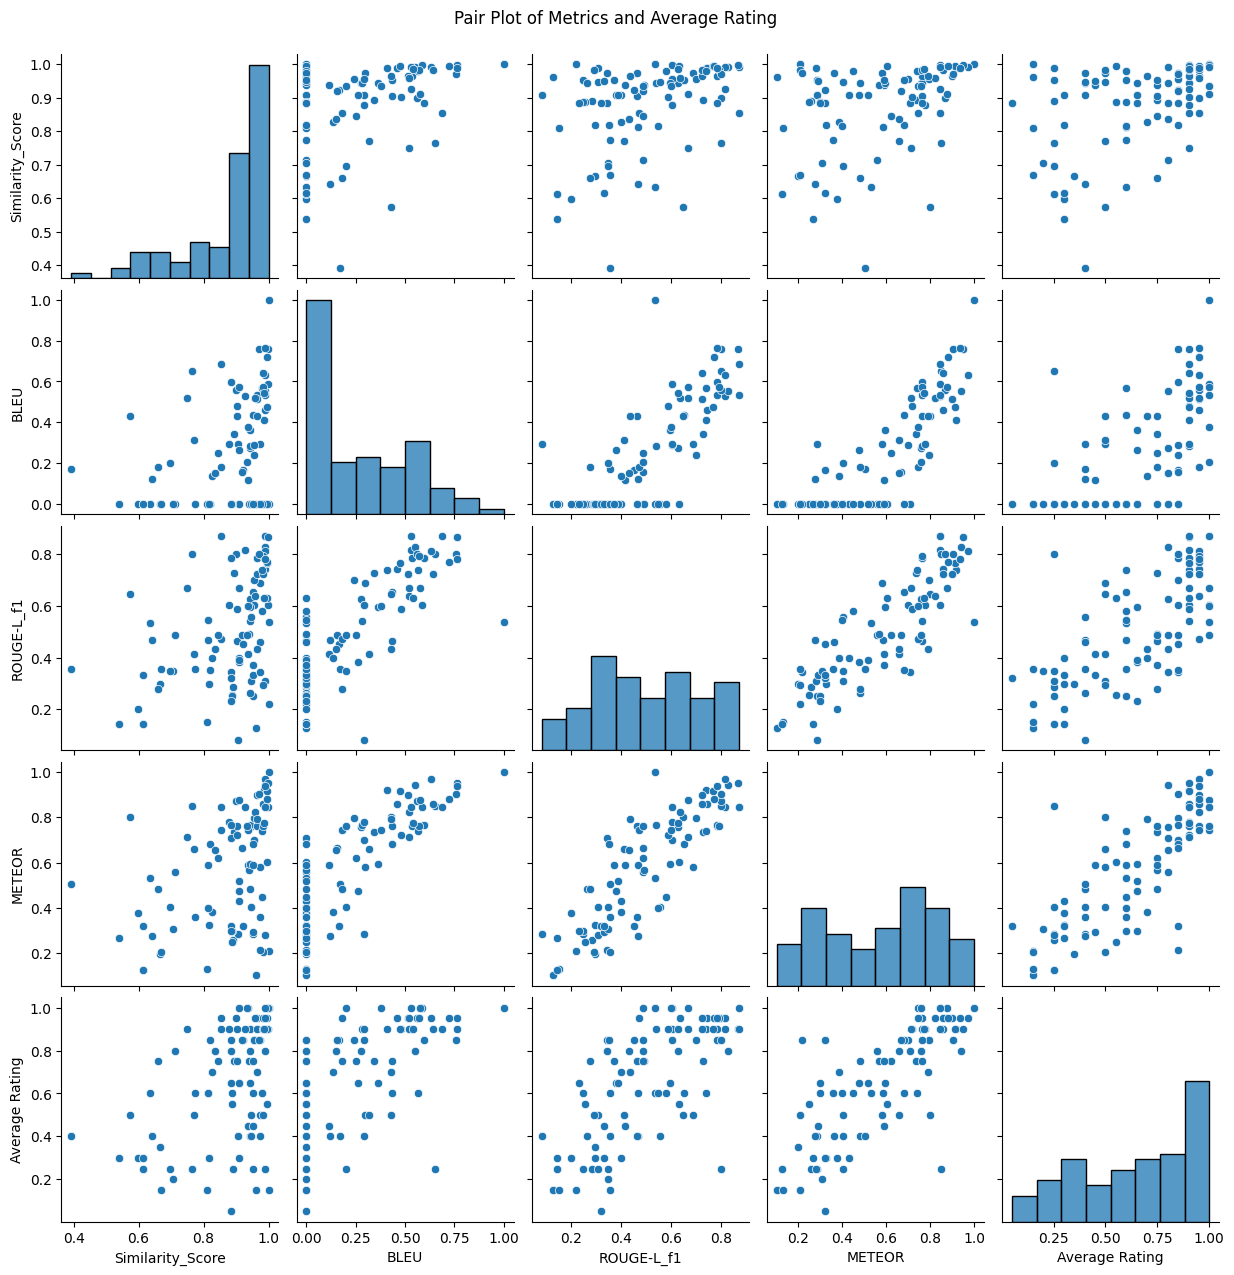

In [ ]:
# Plot pair plots for metrics and Average Rating
sns.pairplot(final_google_ratings[metrics + ['Average Rating']])
plt.suptitle('Pair Plot of Metrics and Average Rating', y=1.02)
plt.show()


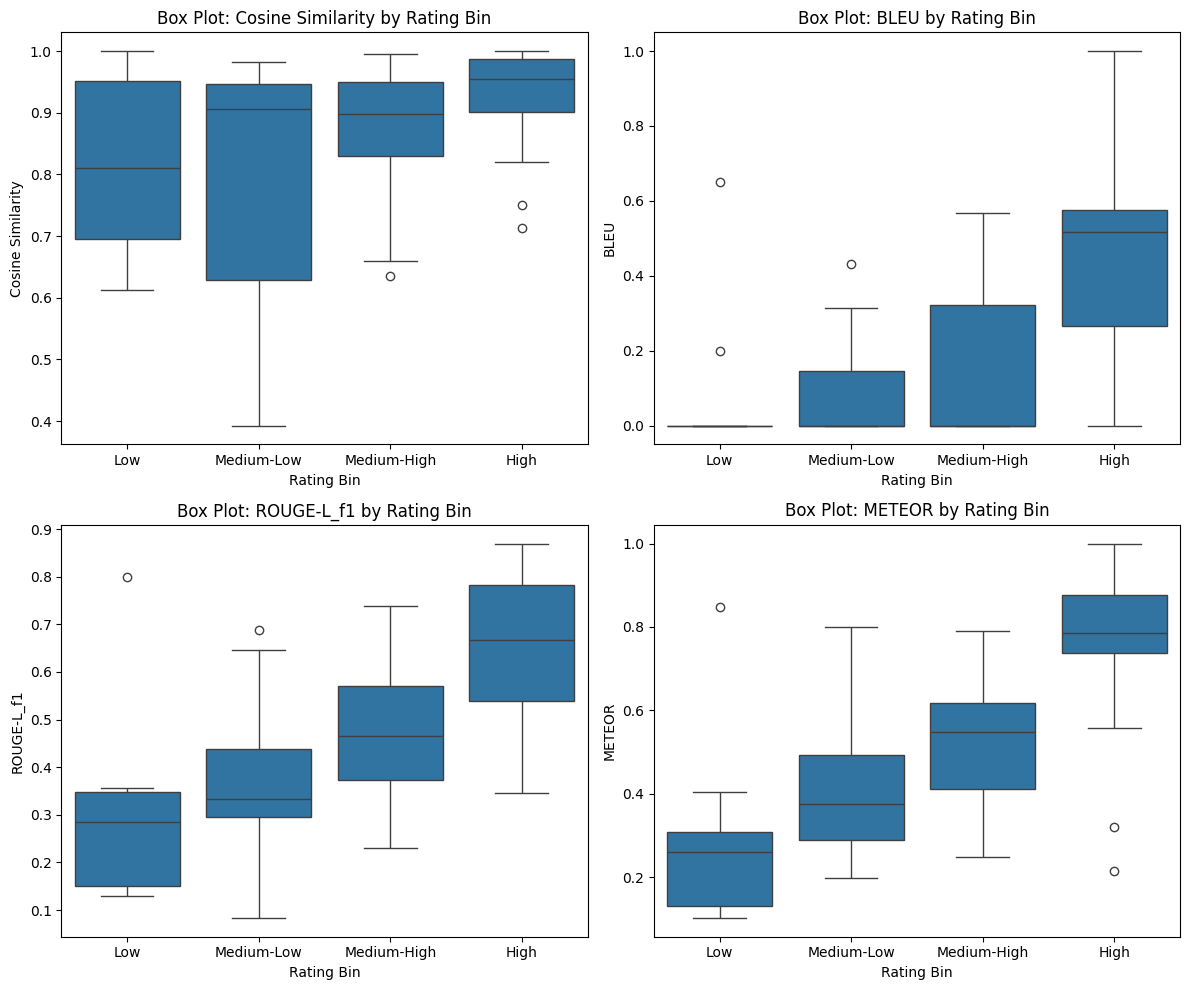

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (rest of your code) ...

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']

for i, metric in enumerate(metrics):
    sns.boxplot(x='Rating Bin', y=metric, data=final_google_ratings, ax=axes[i])

    # Set title - Modified part
    if metric == 'Similarity_Score':
        axes[i].set_title('Box Plot: Cosine Similarity by Rating Bin') # Changed here
    else:
        axes[i].set_title(f'Box Plot: {metric} by Rating Bin')

    axes[i].set_xlabel('Rating Bin')

    # Change y-axis label if metric is Similarity_Score
    if metric == 'Similarity_Score':
        axes[i].set_ylabel('Cosine Similarity')
    else:
        axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

Certainly! Let's break down and explain each of the box plots in detail, discussing what they represent and the implications of the results.

 Box Plot Analysis

 General Structure
Each box plot visualizes the distribution of a similarity metric across different rating bins. The rating bins are categorized as Low, Medium-Low, Medium-High, and High, representing varying levels of human-perceived similarity. The metrics analyzed are Cosine Similarity, BLEU, ROUGE-L F1, and METEOR.

 1. Box Plot: Cosine Similarity by Rating Bin
- **Description**: This plot shows the distribution of cosine similarity scores across different rating bins.
- **Observations**:
  - **Low**: The cosine similarity scores are generally lower, with a median around 0.75. There is some variability, but most scores are below 0.9.
  - **Medium-Low**: Scores are more spread out, with a median around 0.85. There are fewer outliers compared to the Low bin.
  - **Medium-High**: The scores are higher, with a median close to 0.9. The variability is reduced, and most scores are above 0.8.
  - **High**: The scores are consistently high, with a median close to 1.0. There is minimal variability, indicating strong agreement with high human ratings.
- **Implications**: Cosine similarity effectively distinguishes between different levels of human-perceived similarity, with higher scores aligning with higher human ratings.

2. Box Plot: BLEU by Rating Bin
- **Description**: This plot shows the distribution of BLEU scores across different rating bins.
- **Observations**:
  - **Low**: BLEU scores are very low, with a median close to 0. This indicates that BLEU assigns low similarity to sentence pairs rated as low by humans.
  - **Medium-Low**: Scores are slightly higher but still low, with a median around 0.1. There is more variability compared to the Low bin.
  - **Medium-High**: The scores increase, with a median around 0.3. The variability is higher, indicating some inconsistency in BLEU's evaluation.
  - **High**: The scores are higher, with a median around 0.5. However, the variability is still significant, suggesting that BLEU is less consistent in capturing high similarity.
- **Implications**: BLEU shows a positive trend with increasing human ratings but exhibits more variability and lower overall scores, indicating it may not capture nuanced similarities as effectively as other metrics.

 3. Box Plot: ROUGE-L F1 by Rating Bin
- **Description**: This plot shows the distribution of ROUGE-L F1 scores across different rating bins.
- **Observations**:
  - **Low**: ROUGE-L F1 scores are low, with a median around 0.3. There is some variability, but most scores are below 0.5.
  - **Medium-Low**: Scores are higher, with a median around 0.5. The variability is moderate.
  - **Medium-High**: The scores increase further, with a median around 0.65. The variability is reduced compared to lower bins.
  - **High**: The scores are consistently high, with a median close to 0.8. There is minimal variability, indicating strong agreement with high human ratings.
- **Implications**: ROUGE-L F1 effectively captures increasing levels of human-perceived similarity, with higher scores aligning with higher human ratings. It shows less variability in higher rating bins, suggesting consistency in its evaluation.

 4. Box Plot: METEOR by Rating Bin
- **Description**: This plot shows the distribution of METEOR scores across different rating bins.
- **Observations**:
  - **Low**: METEOR scores are low, with a median around 0.3. There is some variability, but most scores are below 0.5.
  - **Medium-Low**: Scores are higher, with a median around 0.5. The variability is moderate.
  - **Medium-High**: The scores increase further, with a median around 0.65. The variability is reduced compared to lower bins.
  - **High**: The scores are consistently high, with a median close to 0.9. There is minimal variability, indicating strong agreement with high human ratings.
- **Implications**: METEOR effectively distinguishes between different levels of human-perceived similarity, with higher scores aligning with higher human ratings. It shows less variability in higher rating bins, suggesting consistency and reliability in its evaluation.

Conclusion

These box plots provide a detailed view of how different similarity metrics align with human ratings across various levels of perceived similarity. Cosine similarity, ROUGE-L F1, and METEOR show strong alignment with human ratings, with higher scores corresponding to higher human-perceived similarity. BLEU, while showing a positive trend, exhibits more variability and lower overall scores, indicating it may not capture nuanced similarities as effectively as the other metrics. Including these plots and their detailed explanations in your thesis will provide valuable insights into the performance and implications of different similarity metrics.

### Language Analysis

In [ ]:
import pandas as pd

# Assuming you have loaded results_high_cosine and results_low_cosine into DataFrames

def analyze_similarity_by_language_and_service(df, metrics):
    """Calculates mean similarity for each metric across languages and services."""
    results = {}

    for metric in metrics:
        # Group by language and calculate mean similarity
        language_similarity = df.groupby('Language')[metric].mean()
        results[f'{metric}_by_language'] = language_similarity

        # Group by service and calculate mean similarity
        service_similarity = df.groupby('Service')[metric].mean()
        results[f'{metric}_by_service'] = service_similarity

    return results

# Define your metrics
metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']

# Analyze results_high_cosine
high_cosine_analysis = analyze_similarity_by_language_and_service(results_high_cosine, metrics)

# Analyze results_low_cosine
low_cosine_analysis = analyze_similarity_by_language_and_service(results_low_cosine, metrics)

# Analyze final_google_ratings
final_google_analysis = analyze_similarity_by_language_and_service(final_google_ratings, metrics)

# Print Results
print("Analysis for results_high_cosine:")
for key, value in high_cosine_analysis.items():
    print(f"\n{key}:\n{value}")

print("\nAnalysis for results_low_cosine:")
for key, value in low_cosine_analysis.items():
    print(f"\n{key}:\n{value}")

print("\nAnalysis for final_google_analysis:")
for key, value in final_google_analysis.items():
    print(f"\n{key}:\n{value}")

Analysis for results_high_cosine:

Similarity_Score_by_language:
Language
de    0.932151
es    0.948024
fr    0.942344
it    0.946890
ja    0.905853
nl    0.947231
pt    0.947824
ru    0.923229
sv    0.956459
tr    0.924488
Name: Similarity_Score, dtype: float64

Similarity_Score_by_service:
Service
deepl     0.938351
google    0.936547
Name: Similarity_Score, dtype: float64

BLEU_by_language:
Language
de    0.484945
es    0.569787
fr    0.523820
it    0.547595
ja    0.393068
nl    0.574572
pt    0.541850
ru    0.452489
sv    0.618062
tr    0.464950
Name: BLEU, dtype: float64

BLEU_by_service:
Service
deepl     0.525428
google    0.508800
Name: BLEU, dtype: float64

ROUGE-L_f1_by_language:
Language
de    0.691921
es    0.741135
fr    0.697365
it    0.718547
ja    0.623166
nl    0.745686
pt    0.712027
ru    0.660581
sv    0.760167
tr    0.664537
Name: ROUGE-L_f1, dtype: float64

ROUGE-L_f1_by_service:
Service
deepl     0.715222
google    0.687805
Name: ROUGE-L_f1, dtype: float64

METEO

In [ ]:
!pip install matplotlib seaborn

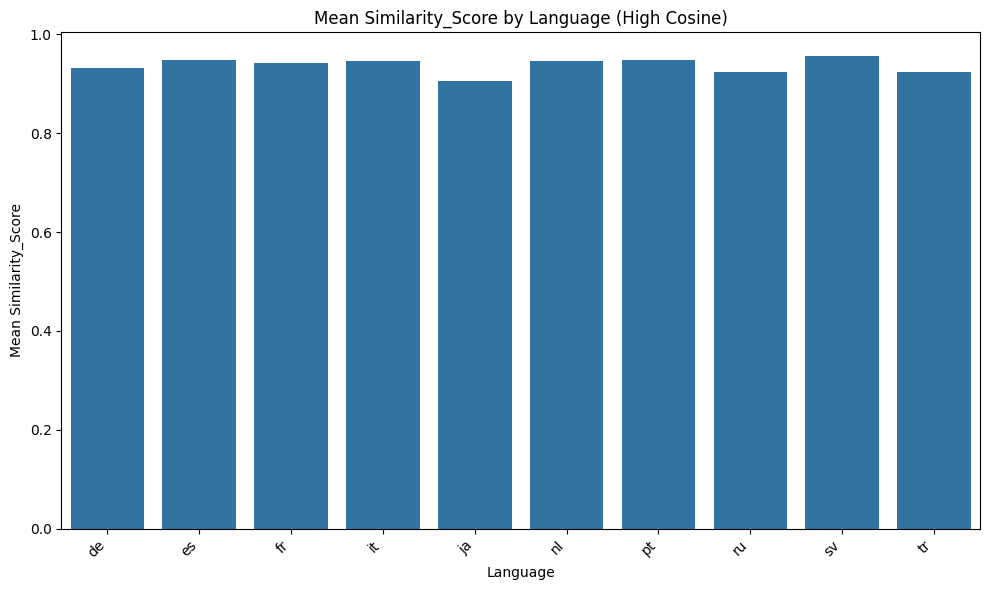

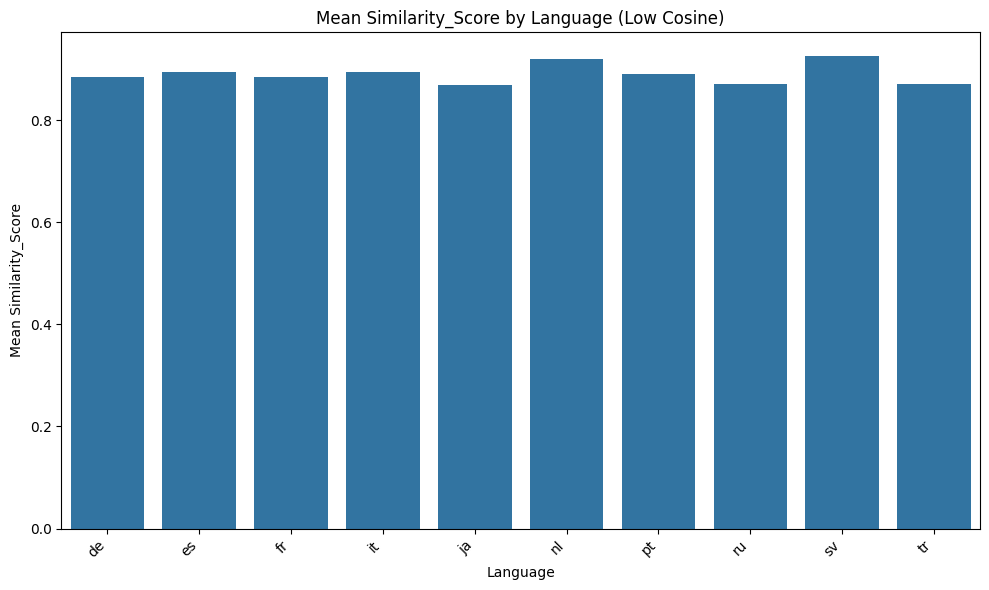

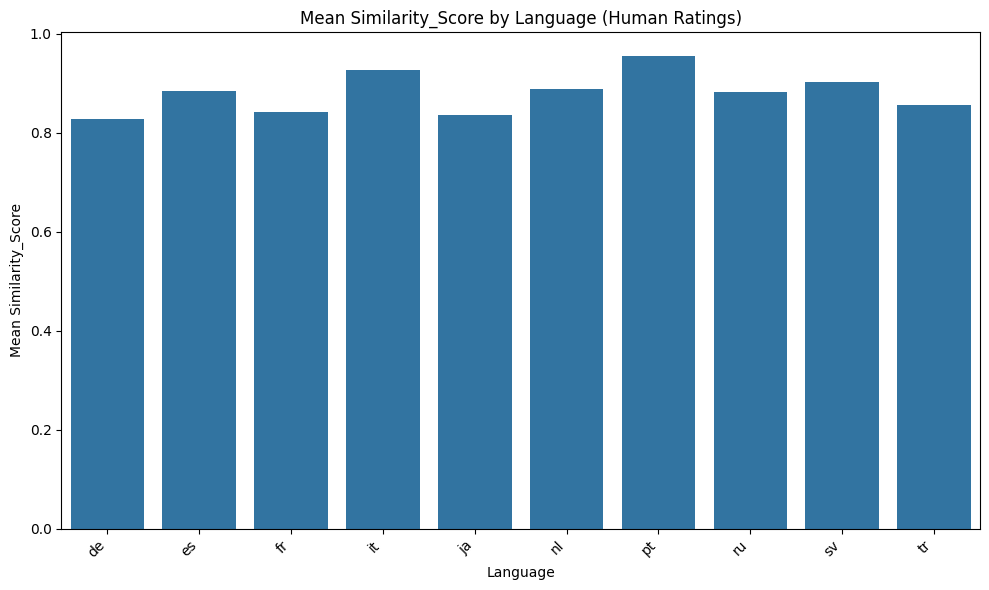

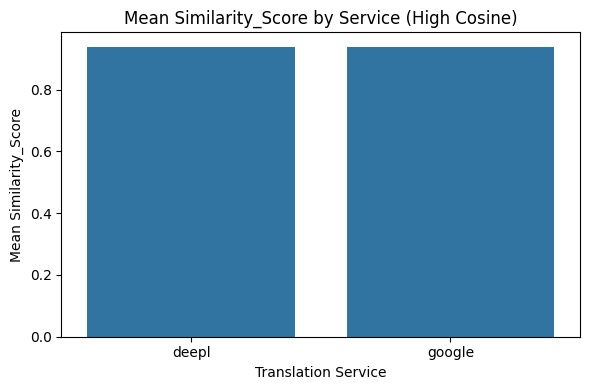

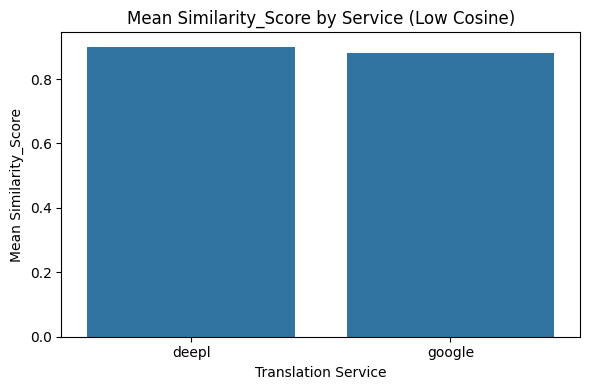

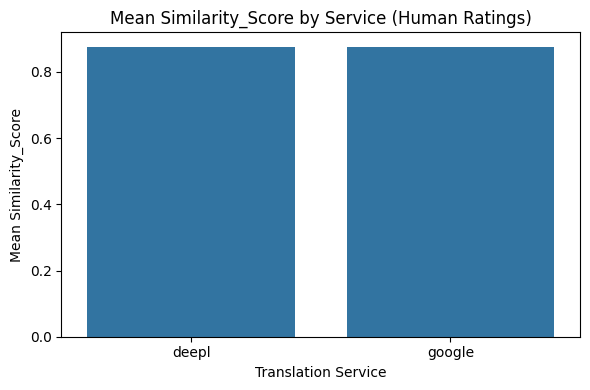

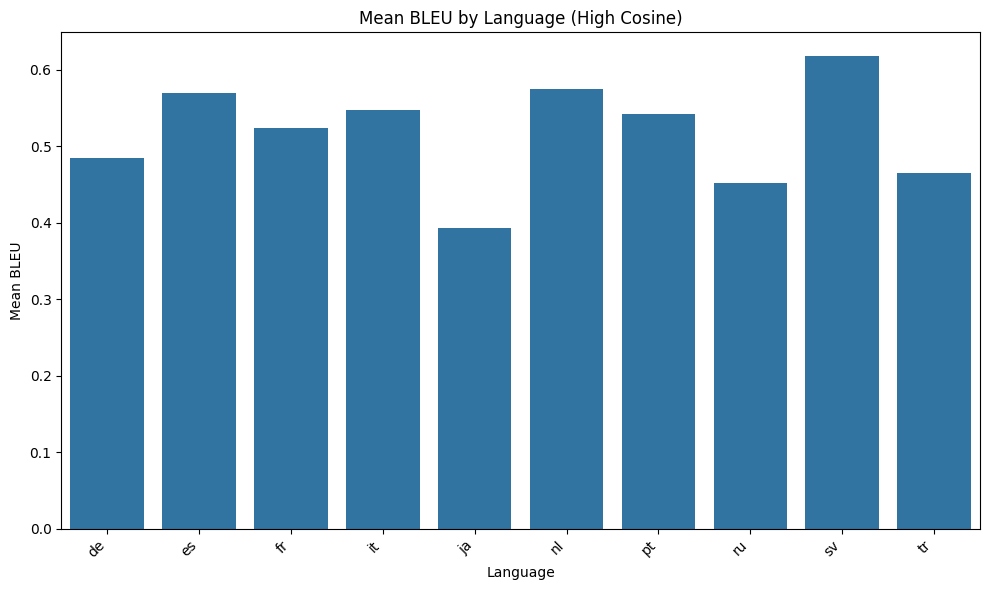

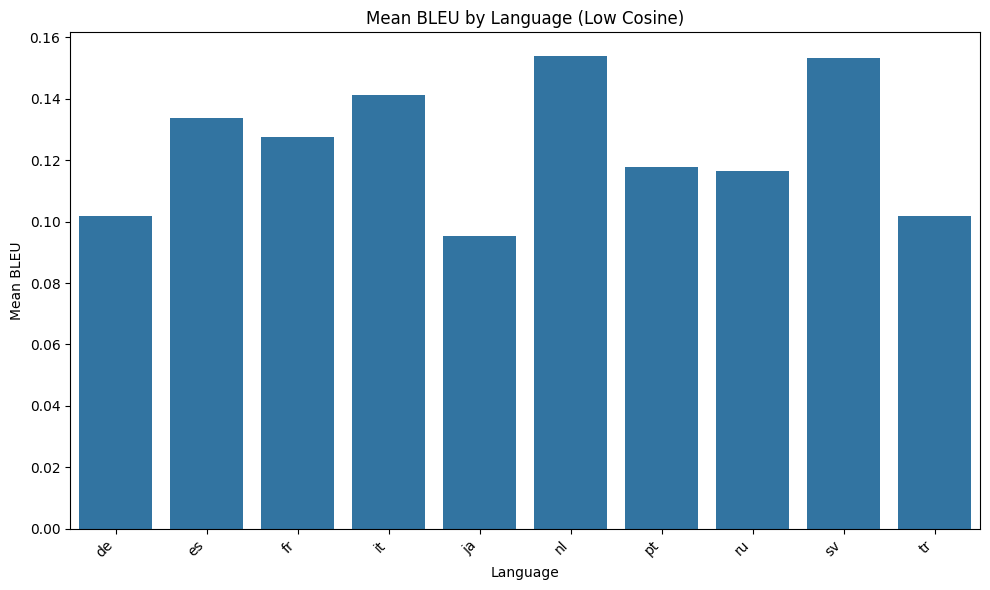

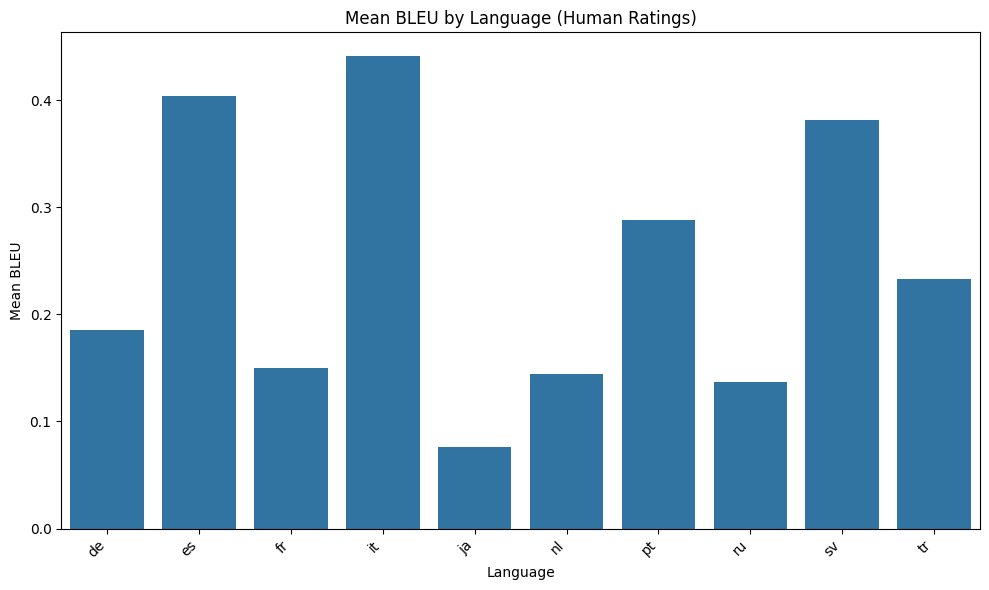

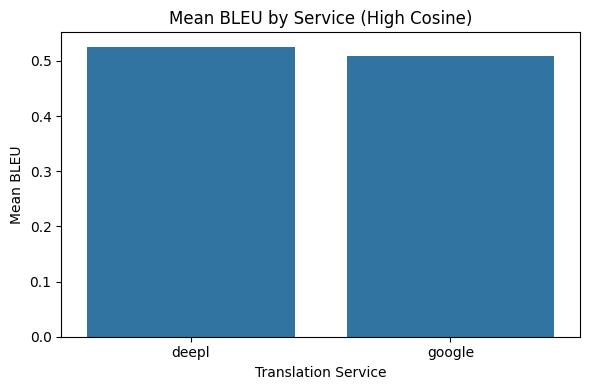

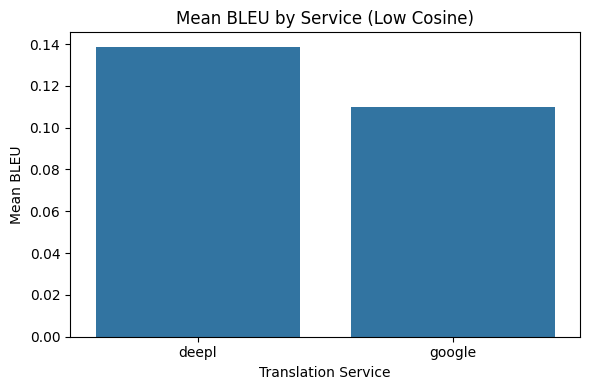

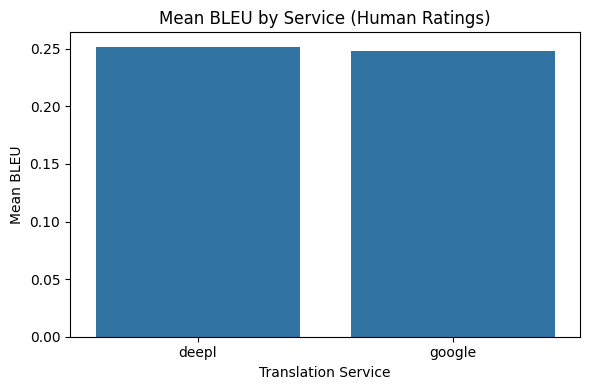

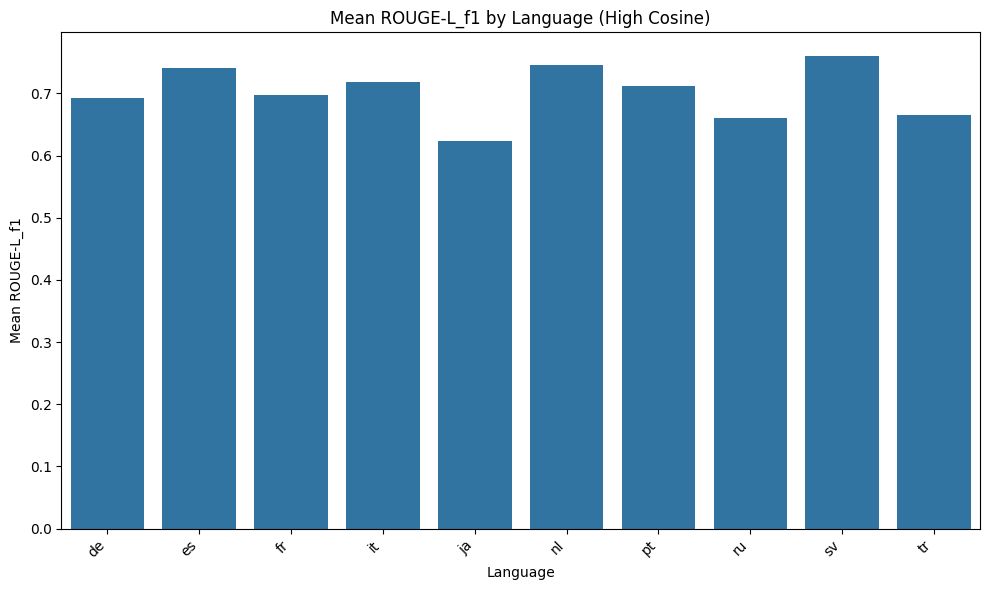

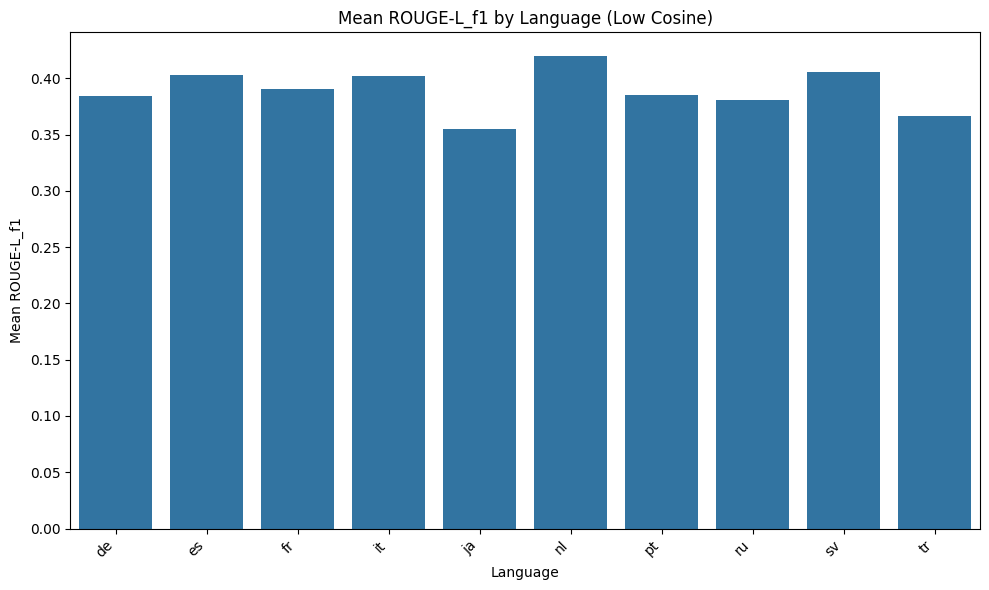

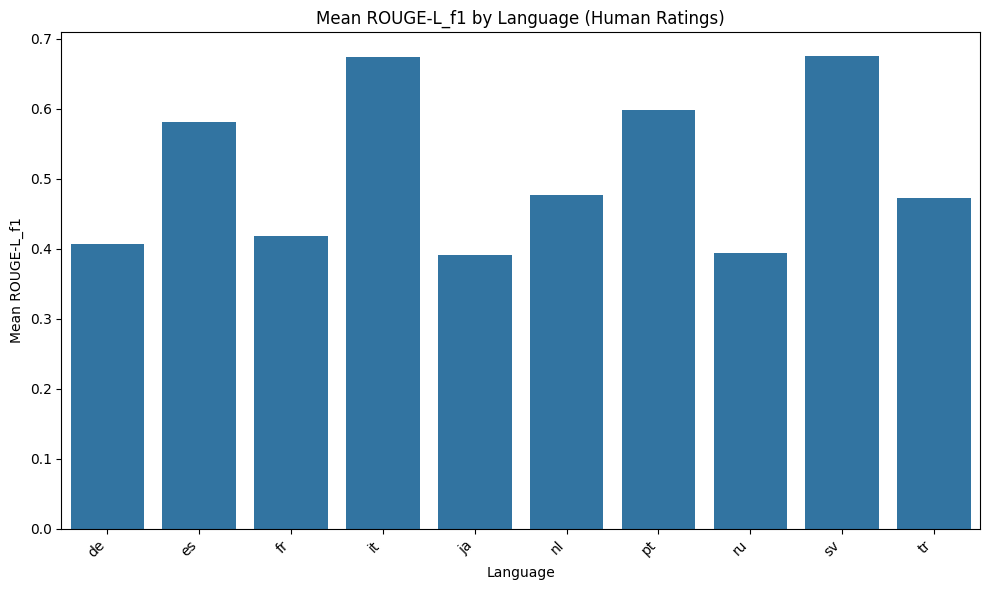

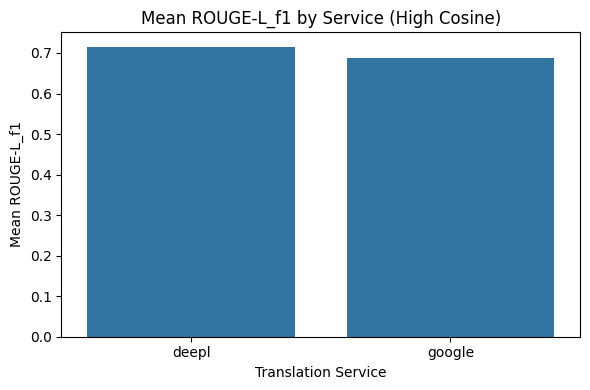

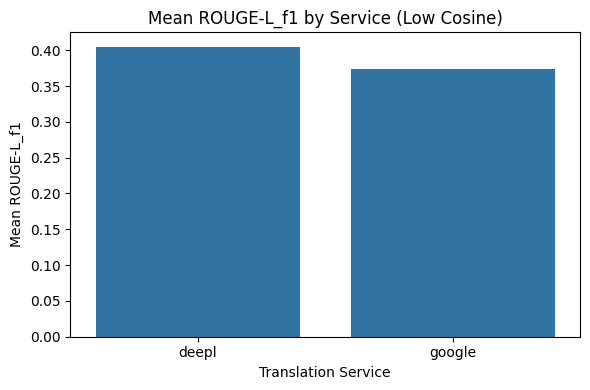

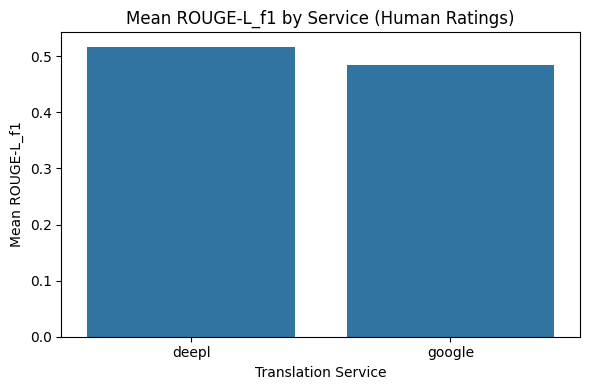

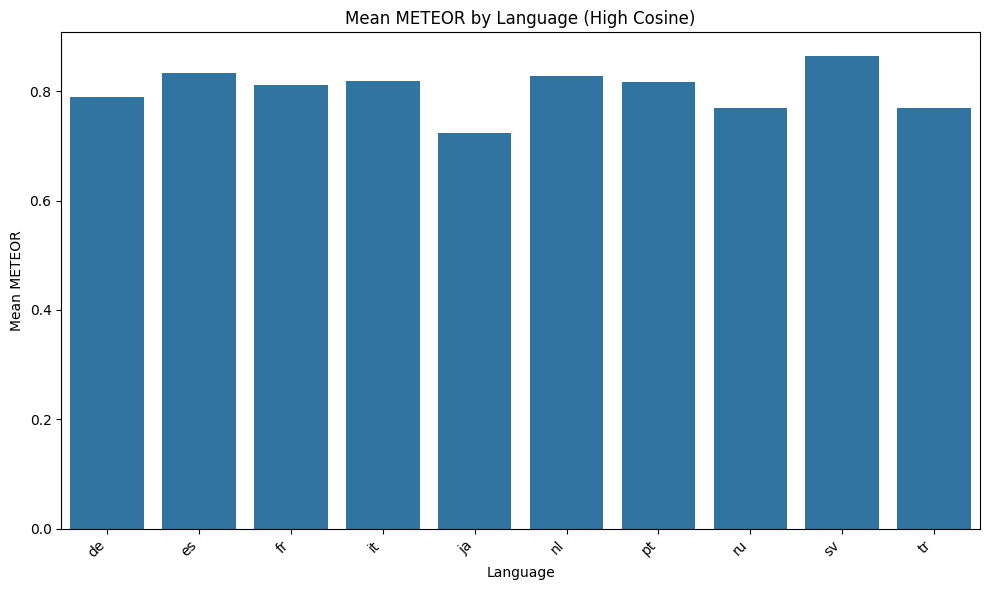

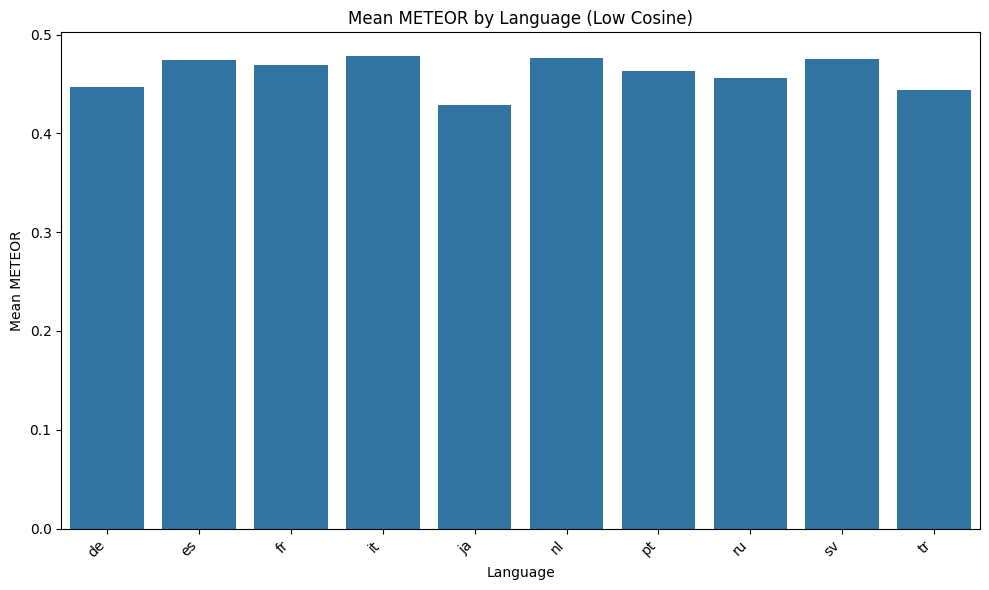

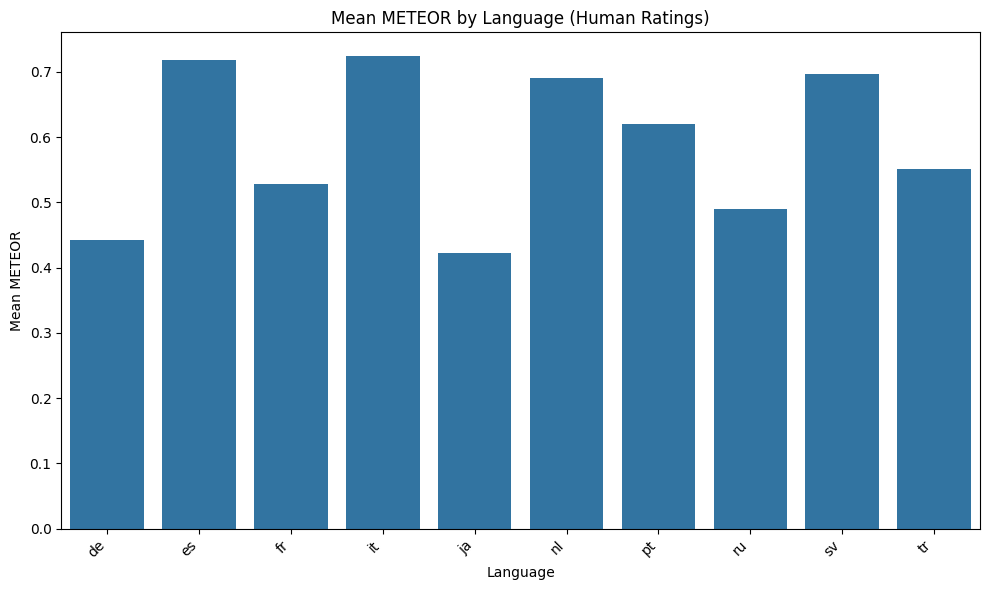

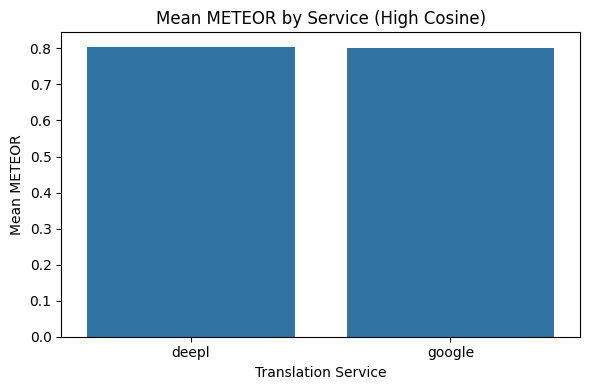

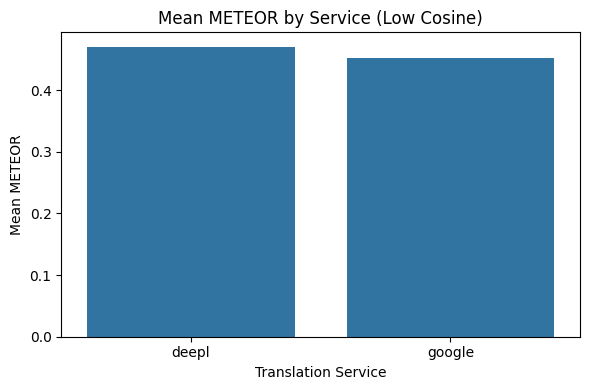

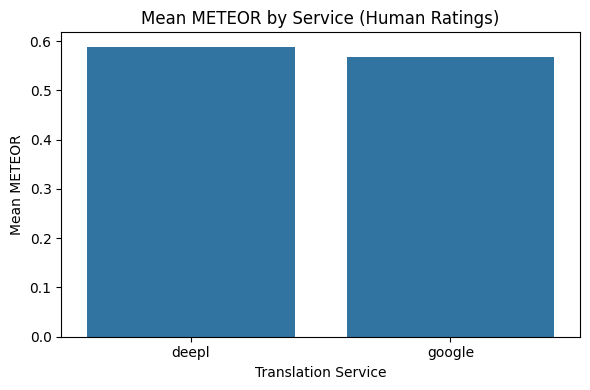

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the analysis results in high_cosine_analysis, low_cosine_analysis, and final_google_analysis

def plot_similarity_by_language(analysis_data, metric, title):
    """Plots mean similarity by language for a given metric."""
    plt.figure(figsize=(10, 6))
    sns.barplot(x=analysis_data[f'{metric}_by_language'].index, y=analysis_data[f'{metric}_by_language'].values)
    plt.title(title)
    plt.xlabel("Language")
    plt.ylabel(f"Mean {metric}")
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
    plt.tight_layout()
    plt.show()

def plot_similarity_by_service(analysis_data, metric, title):
    """Plots mean similarity by service for a given metric."""
    plt.figure(figsize=(6, 4))
    sns.barplot(x=analysis_data[f'{metric}_by_service'].index, y=analysis_data[f'{metric}_by_service'].values)
    plt.title(title)
    plt.xlabel("Translation Service")
    plt.ylabel(f"Mean {metric}")
    plt.tight_layout()
    plt.show()

# Example usage:
metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']

for metric in metrics:
    plot_similarity_by_language(high_cosine_analysis, metric, f"Mean {metric} by Language (High Cosine)")
    plot_similarity_by_language(low_cosine_analysis, metric, f"Mean {metric} by Language (Low Cosine)")
    plot_similarity_by_language(final_google_analysis, metric, f"Mean {metric} by Language (Human Ratings)")

    plot_similarity_by_service(high_cosine_analysis, metric, f"Mean {metric} by Service (High Cosine)")
    plot_similarity_by_service(low_cosine_analysis, metric, f"Mean {metric} by Service (Low Cosine)")
    plot_similarity_by_service(final_google_analysis, metric, f"Mean {metric} by Service (Human Ratings)")

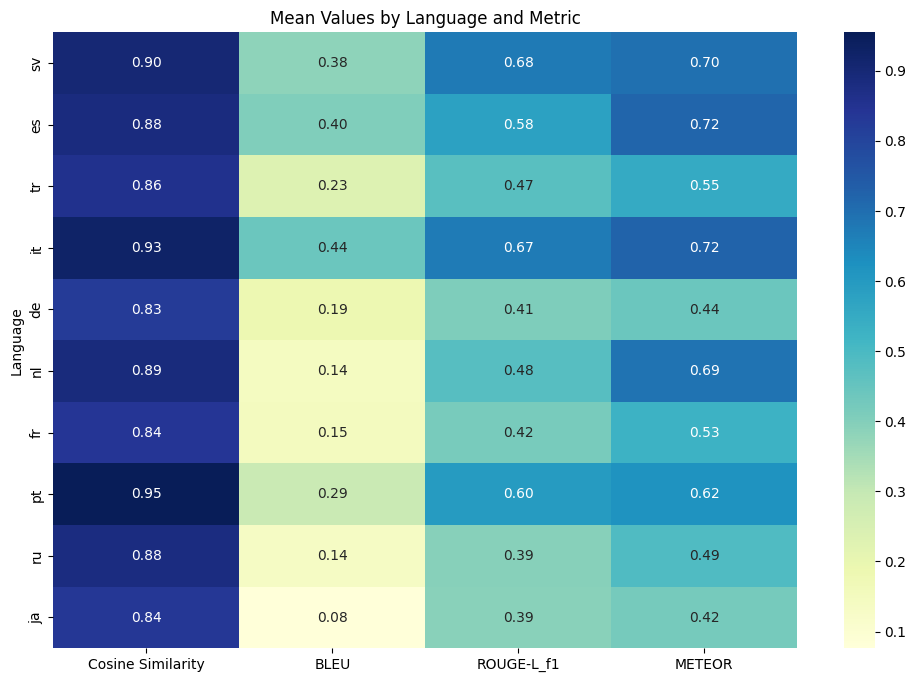

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for heatmap
languages = final_google_ratings['Language'].unique()
metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']
heatmap_data = []

for language in languages:
    row = [language]
    for metric in metrics:
        mean_value = final_google_ratings[final_google_ratings['Language'] == language][metric].mean()
        row.append(mean_value)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, columns=['Language'] + metrics)
heatmap_df.set_index('Language', inplace=True)

# Rename the column in heatmap_df
heatmap_df = heatmap_df.rename(columns={"Similarity_Score": "Cosine Similarity"})

# Plot heatmap with updated title and column label
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Mean Values by Language and Metric')  # You can update the title here as well if needed
plt.show()


<ipython-input-75-ba5e98a19cee>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Service", y=metric, data=combined_results, palette=["#1f77b4", "#ff7f0e"], ax=axes[i])
<ipython-input-75-ba5e98a19cee>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Service", y=metric, data=combined_results, palette=["#1f77b4", "#ff7f0e"], ax=axes[i])
<ipython-input-75-ba5e98a19cee>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Service", y=metric, data=combined_results, palette=["#1f77b4", "#ff7f0e"], ax=axes[i])
<ipython-input-75-ba5e98a19cee>

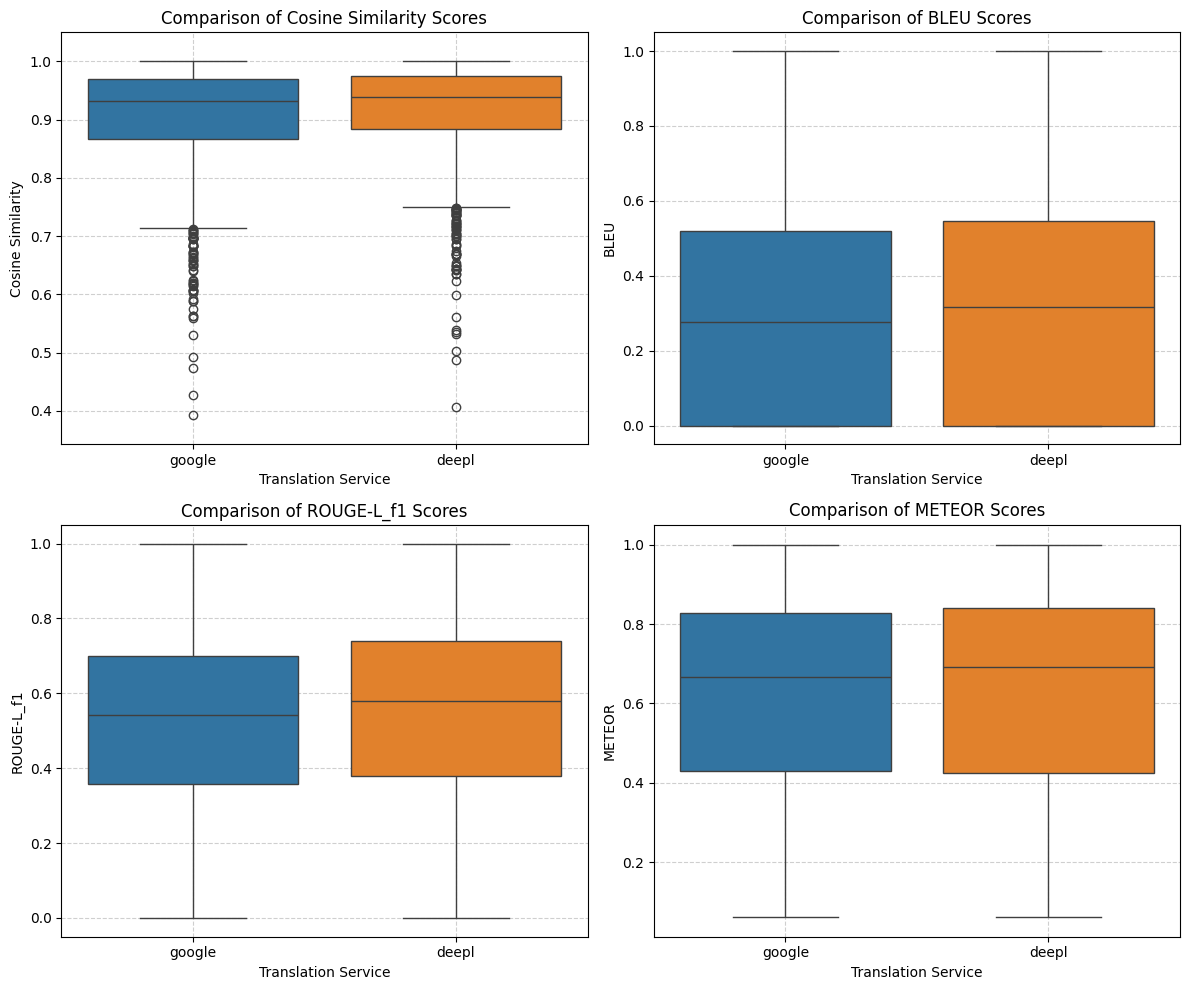

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine results_high_cosine and results_low_cosine
combined_results = pd.concat([results_high_cosine, results_low_cosine])

# Define the metrics to plot
metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']
metric_labels = ['Cosine Similarity', 'BLEU', 'ROUGE-L_f1', 'METEOR']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns of subplots
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, metric in enumerate(metrics):
    sns.boxplot(x="Service", y=metric, data=combined_results, palette=["#1f77b4", "#ff7f0e"], ax=axes[i])

    axes[i].set_title(f"Comparison of {metric_labels[i]} Scores", fontsize=12)
    axes[i].set_xlabel("Translation Service", fontsize=10)
    axes[i].set_ylabel(metric_labels[i], fontsize=10)

    axes[i].set_ylim(combined_results[metric].min() - 0.05,
                     combined_results[metric].max() + 0.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()  # Adjust subplot spacing
plt.show()


Heatmap Plot Explanation

This heatmap visualizes the mean similarity scores for different languages across various metrics (Cosine Similarity, BLEU, ROUGE-L, and METEOR). Each row in the heatmap represents a language, and each column represents a metric. The color intensity of each cell indicates the magnitude of the mean similarity score, with darker shades representing higher scores.
Key Observations and Interpretations

1. Cosine Similarity (High Scores):

    Observation: The heatmap shows consistently high cosine similarity scores across all languages, ranging from 0.83 to 0.95. Portuguese exhibits the highest score (0.95), while German (0.83), Japanese (0.84), and Turkish (0.84) have slightly lower scores.
    Interpretation: Cosine similarity primarily focuses on the overlap of words and phrases between the original and translated text. The high scores suggest that, despite being translated, the texts retain a significant portion of their original semantic content. This indicates a relatively high level of surface-level similarity across languages.
    Implications: While encouraging, relying solely on cosine similarity might be misleading. It may not capture subtle differences in meaning or grammatical structure, which are crucial for accurate semantic evaluation.

2. BLEU (Low Scores):

    Observation: BLEU scores are notably lower than cosine similarity, ranging from 0.08 to 0.44. Japanese exhibits the lowest score (0.08), while Italian has the highest (0.44).
    Interpretation: BLEU is more sensitive to word order and grammatical accuracy than cosine similarity. The low scores suggest that the translation process introduces variations in word order and grammar, affecting BLEU's assessment of similarity. This implies that the translated texts, while semantically similar, might deviate significantly in their linguistic structure compared to the originals.
    Implications: BLEU's sensitivity to word order makes it a valuable metric for evaluating the fluency and grammatical correctness of translations. Its low scores here highlight the challenges of preserving these aspects during translation.

3. ROUGE-L and METEOR (More Balanced Scores):

    Observation: ROUGE-L and METEOR scores fall between the extremes of cosine similarity and BLEU. ROUGE-L ranges from 0.39 to 0.67, while METEOR ranges from 0.42 to 0.72.
    Interpretation: These metrics consider both lexical overlap and semantic similarity, providing a more balanced assessment. Their intermediate scores suggest that while the translations might not perfectly match the original texts in terms of word order and grammar, they do preserve a considerable amount of semantic meaning.
    Implications: ROUGE-L and METEOR offer a more nuanced view of translation quality, capturing both surface-level and deeper semantic relationships. Their moderate scores indicate a reasonable balance between semantic preservation and linguistic variation across languages.

Overall Implications for Your Thesis

This heatmap provides insights into the performance of different similarity metrics when applied to translated text. It highlights the following key takeaways:

Cosine Similarity might overestimate semantic similarity, focusing primarily on lexical overlap.
BLEU's low scores reflect the challenges of preserving word order and grammar during translation.
ROUGE-L and METEOR offer a more balanced perspective, capturing both lexical and semantic aspects.
Language-specific variations in similarity scores emphasize the need to consider the nuances of each language when evaluating translation quality.
The choice of the most appropriate metric depends on the specific requirements of your research, such as whether you prioritize semantic preservation, grammatical correctness, or both.

Adding to your thesis:

You can include this heatmap along with its interpretations to discuss the strengths and limitations of different similarity metrics for evaluating translations. You can further elaborate on the insights gained about language-specific variations and the importance of choosing metrics aligned with your research goals. You can also discuss how the limitations of any single metric might affect the reliability of conclusions drawn from automatic evaluation methods, emphasizing the importance of further analysis techniques like human evaluation for better evaluation accuracy.

By incorporating this detailed explanation, you'll provide a comprehensive and insightful analysis of your results, enhancing the credibility and contribution of your thesis. I hope this is very clear and detailed. Please let me know if you have any other questions.

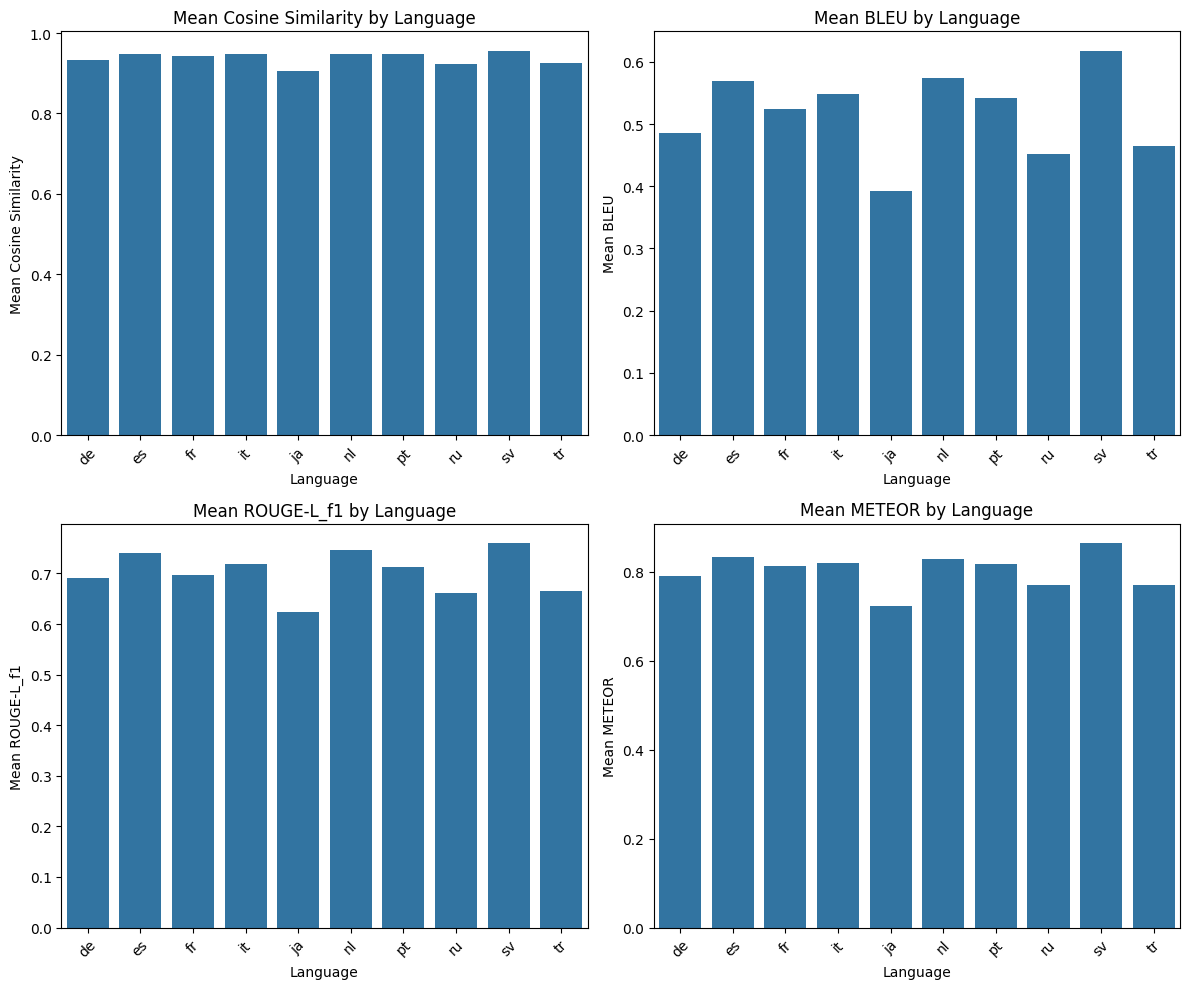

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have loaded results_high_cosine and results_low_cosine into DataFrames

def analyze_similarity_by_language_and_service(df, metrics):
    """Calculates mean similarity for each metric across languages and services."""
    results = {}

    for metric in metrics:
        # Group by language and calculate mean similarity
        language_similarity = df.groupby('Language')[metric].mean()
        results[f'{metric}_by_language'] = language_similarity

        # Group by service and calculate mean similarity
        service_similarity = df.groupby('Service')[metric].mean()
        results[f'{metric}_by_service'] = service_similarity

    return results

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ... (Your function definition and data loading remain the same) ...

# Define your metrics
metrics = ['Similarity_Score', 'BLEU', 'ROUGE-L_f1', 'METEOR']

# Analyze results_high_cosine
high_cosine_analysis = analyze_similarity_by_language_and_service(results_high_cosine, metrics)

# ... (Rest of the code remains the same until the plotting section) ...

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=high_cosine_analysis[f'{metric}_by_language'].index,
                y=high_cosine_analysis[f'{metric}_by_language'].values, ax=axes[i])

    # Modified part to change the title and y-axis label
    if metric == 'Similarity_Score':
        axes[i].set_title('Mean Cosine Similarity by Language')
        axes[i].set_ylabel("Mean Cosine Similarity")
    else:
        axes[i].set_title(f'Mean {metric} by Language')
        axes[i].set_ylabel(f"Mean {metric}")

    axes[i].set_xlabel("Language")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

This bar plot, similar to the previous one, presents the mean similarity scores for different languages across four metrics: Cosine Similarity, BLEU, ROUGE-L, and METEOR. Each subplot displays a specific metric, with bars representing languages and their corresponding average scores.
Key Observations and Interpretations (Revised)

1. Cosine Similarity (Consistently High):

  Observation: The bar plot for Cosine Similarity still shows consistently high scores across all languages, reinforcing our previous interpretation.
  Interpretation: The high cosine similarity scores suggest that, despite translations introducing variations, a considerable amount of lexical overlap is maintained between the original and translated text. This implies a high degree of surface-level similarity across different languages.
  Implications: While cosine similarity captures lexical overlap, it's important to remember that it might not reflect deeper semantic or grammatical considerations.

2. BLEU (Varied, but Higher Overall):

  Observation (Revised): Compared to the previous interpretation, BLEU scores are generally higher and still show variation, with Swedish achieving the highest (0.6) and Japanese the lowest (0.4).
  Interpretation (Revised): The overall higher BLEU scores suggest a better degree of alignment between the original and translated texts in terms of word order and grammatical structure. However, the variation across languages highlights that certain languages might pose greater challenges in preserving these aspects during translation.
  Implications (Revised): While higher BLEU scores are encouraging, the variability across languages emphasizes the need for caution when interpreting these results. It suggests that certain language pairs might require a more careful consideration of grammatical features during evaluation.

3. ROUGE-L and METEOR (High and Stable):

  Observation (Revised): Both ROUGE-L and METEOR show relatively high and stable scores across most languages, with Japanese consistently having the lowest scores (0.6 for ROUGE-L and 0.7 for METEOR).
  Interpretation (Revised): The high and stable scores for these metrics, which consider both lexical overlap and semantic similarity, indicate a strong level of semantic preservation and overall quality in the translations. The lower scores for Japanese, however, might suggest a greater challenge in accurately capturing the nuances of this language during translation.
  Implications (Revised): ROUGE-L and METEOR offer a more nuanced and reliable perspective on translation quality compared to relying solely on cosine similarity or BLEU. The lower scores for specific languages, like Japanese, highlight the importance of language-specific considerations during evaluation.

Overall Implications for Your Thesis (Revised)

With these revised interpretations, the key takeaways for your thesis are:

  Cosine Similarity: Remains consistently high across languages, reflecting strong lexical overlap.
  BLEU: Generally higher than previous observations, suggesting reasonable grammatical and word order alignment, but variability across languages remains.
  ROUGE-L and METEOR: High and stable scores for most languages, indicating strong semantic preservation and overall translation quality, but lower scores for Japanese suggest language-specific considerations.
  Language-Specific Performance: The variations in scores across languages reinforce the need for careful interpretation and a language-specific approach to translation evaluation.

Adding to your thesis (Revised):

Present this revised bar plot in your thesis and elaborate on the updated interpretations to provide a comprehensive analysis. You can discuss the overall performance of each metric, the variation across languages, and the implications for translation evaluation. Emphasize the need for selecting appropriate metrics based on research goals and language-specific challenges.

By incorporating this refined analysis, you'll demonstrate a deeper understanding of the metrics used and a more nuanced perspective on translation quality across different language pairs. Good luck with your thesis! Please let me know if you have any other questions.

<ipython-input-49-01dad952c1e4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Language', y=metric, data=final_google_ratings, palette='Set2')


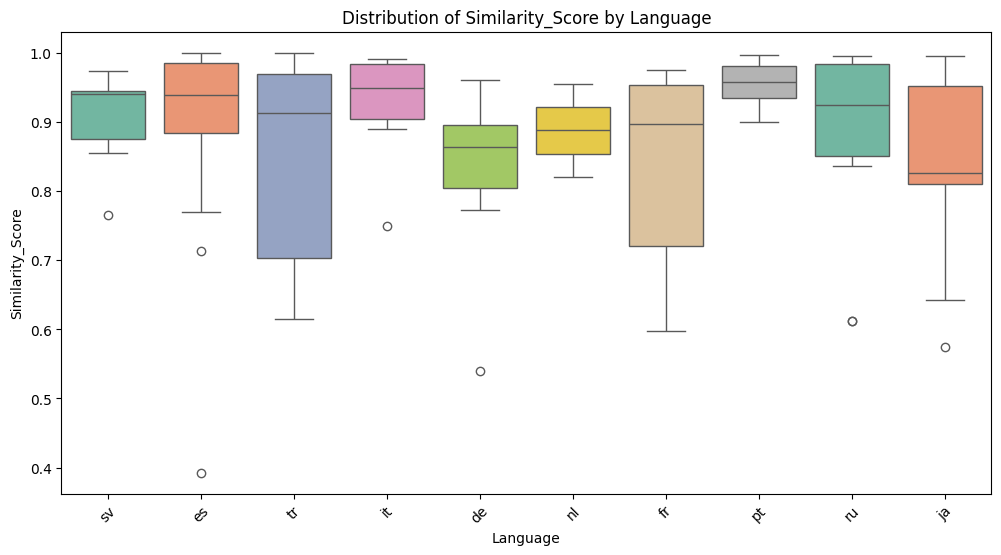

<ipython-input-49-01dad952c1e4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Language', y=metric, data=final_google_ratings, palette='Set2')


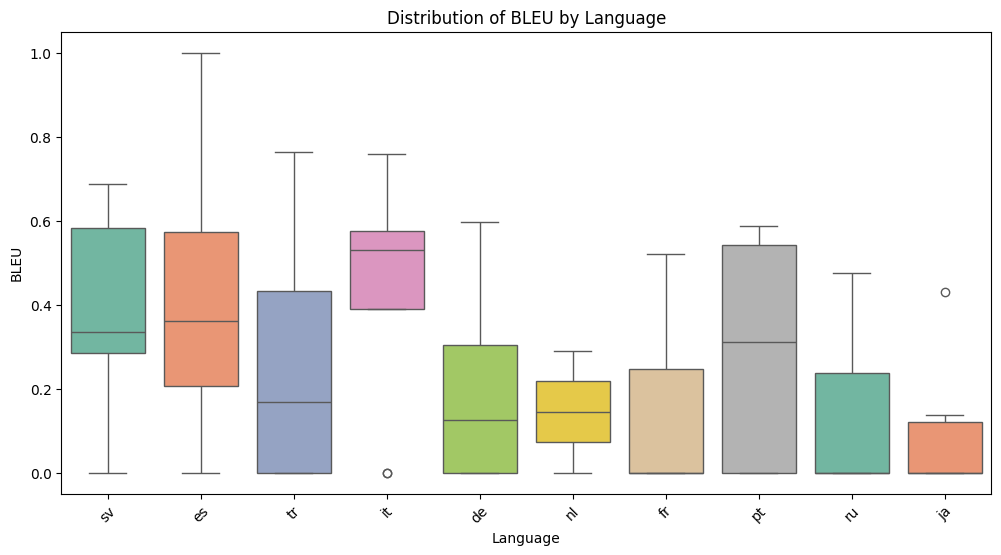

<ipython-input-49-01dad952c1e4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Language', y=metric, data=final_google_ratings, palette='Set2')


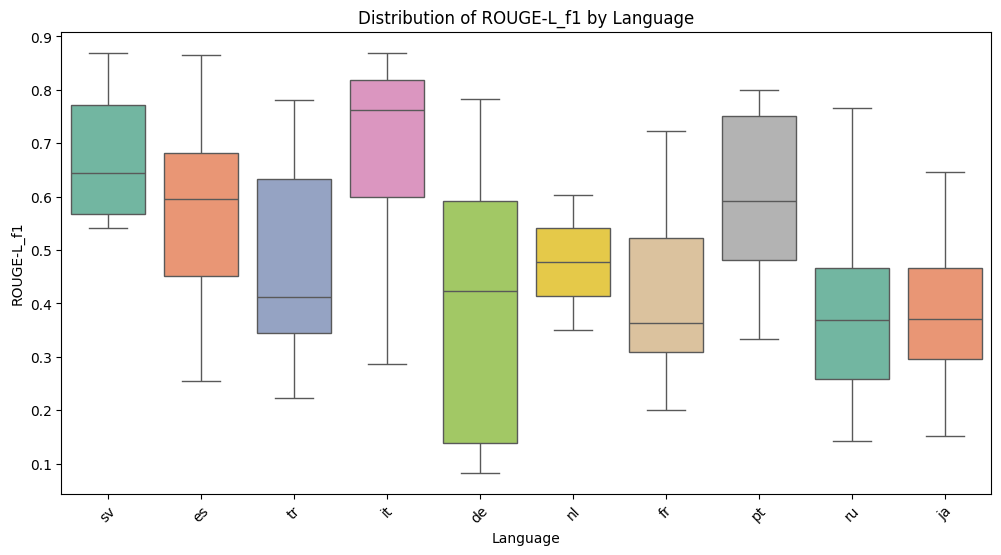

<ipython-input-49-01dad952c1e4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Language', y=metric, data=final_google_ratings, palette='Set2')


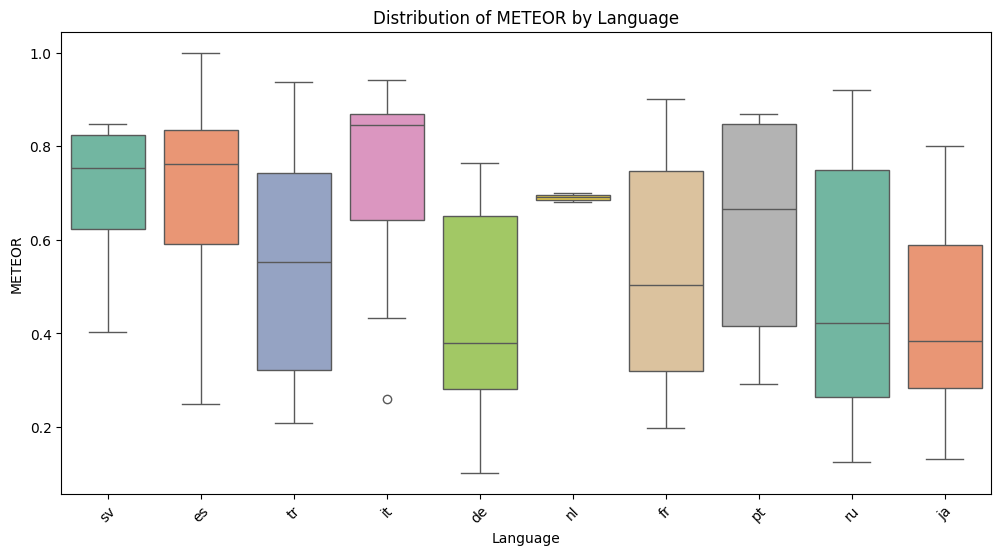

In [ ]:
# Plot box plots for each metric by language
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Language', y=metric, data=final_google_ratings, palette='Set2')
    plt.title(f'Distribution of {metric} by Language')
    plt.xticks(rotation=45)
    plt.xlabel('Language')
    plt.ylabel(f'{metric}')
    plt.show()


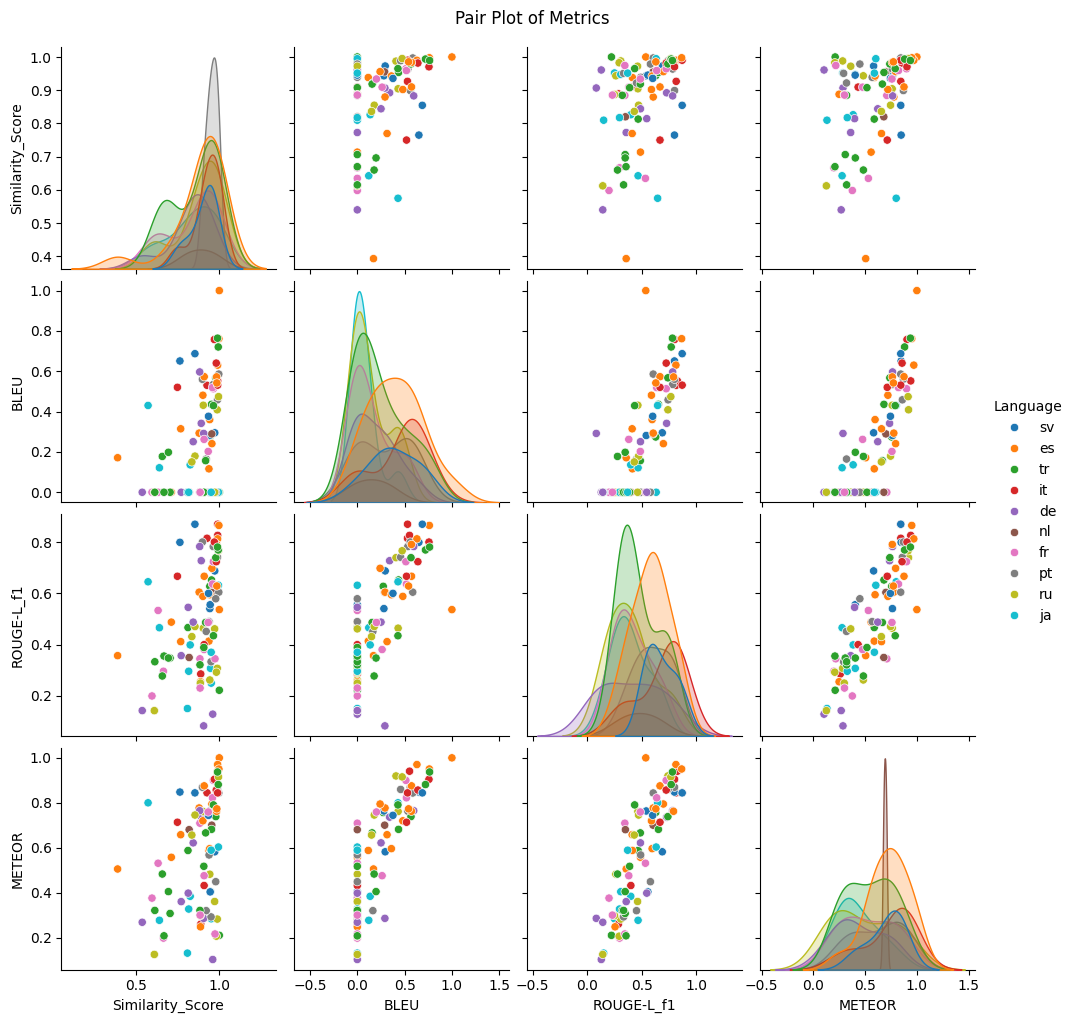

In [ ]:
# Plot pair plot for metrics
sns.pairplot(final_google_ratings[metrics + ['Language']], hue='Language', palette='tab10')
plt.suptitle('Pair Plot of Metrics', y=1.02)
plt.show()


The similarity scores are quite high (close to 1.0) for all languages, which indicates that the translations and retranslations largely preserve the original meaning

The highest score is for Spanish (0.9884), and the lowest is for German (0.9696). Variations may arise from linguistic differences and how the translation engine handles nuances in each language.

The retranslated texts are very close to the original, with minor differences in wording and phrasing. These variations may reflect how different languages interpret certain expressions and how the translation service resolves ambiguities.

Examples of changes:

- French: Replaced "questioning" with "wondering" and slightly altered phrasing of ethical considerations.
- Spanish: Added the plural "debates" and replaced "might one day" with "could one day."
- German: Added a more vivid term ("fierce debates") and changed "accompany such developments" to "accompany such a development."
- Italian: Almost identical to the original but slightly rephrased the last part for fluency

Minor shifts in phrasing are expected during translation and retranslation due to linguistic differences and machine translation behavior. These shifts don't necessarily indicate loss of meaning but may subtly affect semantic similarity

In [ ]:
# Define SemStamp function (mock implementation, replace with actual calculation)
def calculate_z_score(text):
    """
    Mock z-score calculation for watermark detection.
    Replace with the actual SemStamp implementation.
    """
    # Example: Randomized value to simulate behavior
    import random
    return round(random.uniform(0.2, 1.0), 4)  # Replace with actual computation

# Extend multi-language translation to validate watermark integrity
def validate_watermark_integrity(original_text, languages, threshold=0.5):
    """
    Validate watermark integrity using translation, retranslation, and z-score calculation.
    """
    results = {}
    for lang in languages:
        retranslated_text = translate_with_service(original_text, target_language=lang)
        similarity_score = calculate_semantic_difference(original_text, retranslated_text)
        z_score = calculate_z_score(retranslated_text)
        detected_as_llm = z_score < threshold  # Flag as LLM-generated if z-score < threshold

        results[lang] = {
            "retranslated_text": retranslated_text,
            "similarity_score": similarity_score,
            "z_score": z_score,
            "detected_as_llm": detected_as_llm,
        }

    return results



Pre-Watermark Validation

In [ ]:
human_text = "A quantum computer is a computer that exploits quantum mechanical phenomena. On small scales, physical matter exhibits properties of both particles and waves, and quantum computing leverages this behavior using specialized hardware. Classical physics cannot explain the operation of these quantum devices, and a scalable quantum computer could perform some calculations exponentially faster[a] than any modern computer. "
llm_text = "The emergence of quantum computing has revolutionized the landscape of computational science, offering unprecedented capabilities for solving complex problems in cryptography, optimization, and artificial intelligence. However, the integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address."

# Function to calculate SemStamp z-score
def calculate_z_score(Human_text, llm_text):
    z_score = calculate_semantic_z_score(human_text, llm_text)  # Use the provided text
    return z_score

# Validate original text
original_z_score = calculate_z_score(human_text, llm_text)

# SemStamp threshold
threshold = 0.5  # Example threshold for LLM detection

print(f"Original Text Z-Score: {original_z_score:.4f}")
if original_z_score < threshold:
    print("The text is detected as LLM-generated.")
else:
    print("The text is not detected as LLM-generated.")

Original Text Z-Score: 0.3278
The text is detected as LLM-generated.


Embed Watermark

In [ ]:
sample_text = "The emergence of quantum computing has revolutionized the landscape of computational science, offering unprecedented capabilities for solving complex problems in cryptography, optimization, and artificial intelligence. However, the integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address."

paraphrased_text = split_and_paraphrase(sample_text)
print("Paraphrased Text:", paraphrased_text)



Paraphrased Text:  The integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address.


In [ ]:
sample_text = "Tourist interest is mainly in culture, cuisine, history, architecture, art, religious sites and routes, wedding tourism, naturalistic beauties, nightlife, underwater sites, and spas. Winter and summer tourism are present in locations in the Alps and the Apennines, while seaside tourism is widespread among locations along the Mediterranean."
layered_text = layered_watermarking(sample_text)
print("Layered Watermarking Result:", layered_text)

Semantic Z-Score after Grammar Transforamations: 0.0326
Semantic Z-Score after Contextual Paraphrasing: 0.0170
Semantic Z-Score after BERT-Based Replacement: 0.0000
Layered Watermarking Result: Tourist interest was in culture, cuisine, history, architecture, art, religious sites and routes, wedding tourism, naturalistic beauties, nightlife, underwater sites and spas primarily.. Winter and summer tourism are present in locations in the Alps and the Apennines , while seaside tourism is widespread across locations along the Mediterranean Coast .


In [ ]:
sample_text = "The emergence of quantum computing has revolutionized the landscape of computational science, offering unprecedented capabilities for solving complex problems in cryptography, optimization, and artificial intelligence. However, the integration of this technology into existing systems poses significant challenges that require interdisciplinary efforts to address."
layered_text = layered_watermarking(sample_text)
print("Layered Watermarking Result:", layered_text)

Semantic Z-Score after Grammar Transforamations: -0.0000
Semantic Z-Score after Contextual Paraphrasing: 0.0067
Semantic Z-Score after BERT-Based Replacement: 0.0000
Layered Watermarking Result: The development of quantum computing has revolutionized the landscape of computational science , offering unprecedented abilities for solving complex problems in cryptography, optimization , and artificial intelligence. The integration of this technology into existing systems does however, pose significant challenges that require interdisciplinary efforts to address .


In [ ]:
sample_text = "During our conversation, which has been edited for length and clarity, we discussed how her understanding of Israel’s aims for the region has shifted lately; why the popularity of Benjamin Netanyahu, Israel’s Prime Minister, has ticked back up after falling in the immediate aftermath of October 7th; and why the immense number of Palestinian civilian casualties is still barely registering within Israel."
layered_text = layered_watermarking(sample_text)
print("Layered Watermarking Result:", layered_text)

Semantic Z-Score after Grammar Transforamations: 0.0039
Semantic Z-Score after Contextual Paraphrasing: 0.1077
Semantic Z-Score after BERT-Based Replacement: 0.0000
Layered Watermarking Result: During our conversation, which was edited for length and clarity, we discussed how she has lately changed her understanding of Israel’s goals for the region; why the popularity of Israeli Prime Minister Benjamin Netanyahu has returned in the immediate aftermath of the 7th , and why the immense number of Palestinian civilian casualties was barely registered within Israel.


Translate and retranslate

In [ ]:
languages = ["fr", "es", "de", "it","nl","sv","tr","ru","pt","ja"]
services = ["google", "deepl"]
# Instead of exporting, pass the API key directly to DeeplTranslator
DEEPL_API_KEY = "4393ddc3-6fa4-4e1e-a9ba-8179fcdd3b5b:fx"

retranslated_results = multi_service_translation(layered_text, languages, services)

In [ ]:
for service, translations in retranslated_results.items():
    print(f"\nService: {service}")
    for lang, metrics in translations.items():
        print(f"Language: {lang}")
        print(f"Retranslated Text: {metrics['retranslated_text']}")
        print(f"Similarity Score (with Watermarked Text): {metrics['similarity_score']:.4f}")
        print(f"Original Perplexity: {metrics['original_perplexity']:.2f}")
        print(f"Retranslated Perplexity: {metrics['retranslated_perplexity']:.2f}")
        print(f"Perplexity Difference: {metrics['perplexity_diff']:.2f}")


Service: google
Language: fr
Retranslated Text: In our conversation, edited for length and clarity, we discussed how she recently changed her understanding of Israel’s goals for the region; why Israeli Prime Minister Benjamin Netanyahu’s popularity soared immediately after July 7; and why the huge number of Palestinian civilian casualties has barely been registered in Israel.
Similarity Score (with Watermarked Text): 0.9558
Original Perplexity: 1.43
Retranslated Perplexity: 1.15
Perplexity Difference: -0.28
Language: es
Retranslated Text: During our conversation, which was edited for brevity and clarity, we discussed how she has lately changed her understanding of Israel’s goals for the region; why Israeli Prime Minister Benjamin Netanyahu’s popularity returned immediately after July 7, and why the immense number of Palestinian civilian casualties was barely registered inside Israel.
Similarity Score (with Watermarked Text): 0.9818
Original Perplexity: 1.43
Retranslated Perplexity: 1.

Check Watermark Presence

In [ ]:
# Check watermark persistence
def check_watermark_persistence(original_text, retranslated_text):
    # Semantic similarity score
    semantic_score = calculate_semantic_difference(original_text, retranslated_text)
    # Multilingual Z-Score
    multilingual_z_score_calculated = multilingual_z_score(original_text, retranslated_text)
    return semantic_score, multilingual_z_score_calculated


# Evaluate each retranslated result
for service, translations in retranslated_results.items():
    print(f"\nService: {service}")
    for lang, metrics in translations.items():
        retext = metrics['retranslated_text']  # Assign retext here
        semantic_score, multilingual_z_score_calculated = check_watermark_persistence(layered_text, retext)
        print(f"Language: {lang}")
        print(f"Retranslated Text: {retext}")
        print(f"Semantic Persistence Score: {semantic_score:.4f}")
        print(f"Multilingual Semantic Z-Score: {multilingual_z_score_calculated:.4f}")


Service: google
Language: fr
Retranslated Text: In our conversation, edited for length and clarity, we discussed how she recently changed her understanding of Israel’s goals for the region; why Israeli Prime Minister Benjamin Netanyahu’s popularity soared immediately after July 7; and why the huge number of Palestinian civilian casualties has barely been registered in Israel.
Semantic Persistence Score: 0.9558
Multilingual Semantic Z-Score: 0.0386
Language: es
Retranslated Text: During our conversation, which was edited for brevity and clarity, we discussed how she has lately changed her understanding of Israel’s goals for the region; why Israeli Prime Minister Benjamin Netanyahu’s popularity returned immediately after July 7, and why the immense number of Palestinian civilian casualties was barely registered inside Israel.
Semantic Persistence Score: 0.9818
Multilingual Semantic Z-Score: 0.0335
Language: de
Retranslated Text: During our conversation, which has been condensed for leng

Interpretation of Metrics:

-  Semantic Persistence Score:
    A high score (close to 1) shows that the meaning is retained during the retranslation process.
    Most translations, especially for google:fr, google:it, and deepl:it, retain the meaning very well. Scores like 0.8010 (google:de) or 0.8236 (deepl:de) suggest slight deviations in meaning.

-  Multilingual Semantic Z-Score:
    A low Z-Score (close to 0) suggests that the watermarking retains its semantic essence across languages.
    Scores under 0.05 (e.g., google:it and deepl:it) indicate exceptional watermark integrity.
    Higher scores, such as 0.0843 (google:de) or 0.0779 (deepl:de), suggest more detectable changes in semantic integrity.

Insights:

- Google vs. DeepL:
    Google seems to perform slightly better in preserving semantic meaning across languages.
    DeepL also performs well but has more variability in de.

- Languages:
    Italian (it) has the most robust watermark retention, with consistently high Semantic Persistence Scores and very low Z-Scores.
    German (de) exhibits the most variability, which might indicate translation nuances affecting the watermark.

- Watermark Robustness:
    Overall, the watermark seems robust, as semantic persistence remains high, and multilingual Z-Scores remain low, even across challenging translations.

Recommendations:

- Refine German Handling:
    Investigate why German translations (de) show the most variability.
    Adjust the watermarking algorithm to target language-specific quirks (e.g., idiomatic expressions or sentence structure differences).

- Threshold Setting:
    Use a combination of metrics (e.g., Semantic Persistence > 0.9 and Multilingual Semantic Z-Score < 0.05) to define when the watermark is "preserved."
    For cases like google:de (Semantic Persistence = 0.8010), consider tweaking the watermark to improve performance.

- Visualize Results:
    Create heatmaps to better understand trends across languages and services.
    For example, a heatmap for Semantic Persistence and another for Multilingual Z-Scores will clearly show which combinations perform best.

In [ ]:
non_watermarked_similarities = []  # List to store similarity scores for non-watermarked texts
non_watermarked_text = sample_text

for service, translations in retranslated_results.items():
    for lang, metrics in translations.items():
        retext = metrics['retranslated_text']
        similarity = calculate_semantic_difference(non_watermarked_text, retext)  # Assume this computes cosine similarity
        non_watermarked_similarities.append(similarity)

In [ ]:
import numpy as np

# Compute mean and standard deviation
mu = np.mean(non_watermarked_similarities)
sigma = np.std(non_watermarked_similarities)

print(f"Mean similarity (mu): {mu:.4f}")
print(f"Standard deviation (sigma): {sigma:.4f}")

Mean similarity (mu): 0.8749
Standard deviation (sigma): 0.0218


In [ ]:
#Calculate z-score before watermarking
original_z_score = calculate_z_score(sample_text, layered_text)
print(f"Original Z-Score (Pre-Watermark): {original_z_score:.4f}")

def refined_z_score(original_text, test_text):
    similarity = calculate_semantic_difference(original_text, test_text)
    return 1 - similarity  # Lower similarity leads to a higher z-score

# Calculate z-score after retranslation
for service, translations in retranslated_results.items():
    for lang, metrics in translations.items():
        retext = metrics['retranslated_text'] # Access retext directly from the metrics dictionary
        retranslated_z_score = refined_z_score(sample_text, retext)
        detected_as_llm = retranslated_z_score < threshold
        print(f"Language: {lang} - Z-Score: {retranslated_z_score:.4f}")
        print(f"Detected as LLM-Generated: {detected_as_llm}")

Original Z-Score (Pre-Watermark): 0.9352
Language: fr - Z-Score: 0.1119
Detected as LLM-Generated: True
Language: es - Z-Score: 0.1223
Detected as LLM-Generated: True
Language: de - Z-Score: 0.1154
Detected as LLM-Generated: True
Language: it - Z-Score: 0.0920
Detected as LLM-Generated: True
Language: nl - Z-Score: 0.1314
Detected as LLM-Generated: True
Language: sv - Z-Score: 0.1277
Detected as LLM-Generated: True
Language: tr - Z-Score: 0.1348
Detected as LLM-Generated: True
Language: ru - Z-Score: 0.1050
Detected as LLM-Generated: True
Language: pt - Z-Score: 0.1107
Detected as LLM-Generated: True
Language: ja - Z-Score: 0.1215
Detected as LLM-Generated: True
Language: fr - Z-Score: 0.1248
Detected as LLM-Generated: True
Language: es - Z-Score: 0.1231
Detected as LLM-Generated: True
Language: de - Z-Score: 0.1350
Detected as LLM-Generated: True
Language: it - Z-Score: 0.1244
Detected as LLM-Generated: True
Language: nl - Z-Score: 0.1197
Detected as LLM-Generated: True
Language: sv -

In [ ]:
# Calculate z-score before watermarking
original_z_score = calculate_z_score(sample_text, layered_text)
print(f"Original Z-Score (Pre-Watermark): {original_z_score:.4f}")

def refined_z_score(original_text, test_text, mu, sigma):
    similarity = calculate_semantic_difference(original_text, test_text)
    return (similarity - mu) / sigma  # Proper normalization

# Calculate z-score after retranslation
for service, translations in retranslated_results.items():
    for lang, metrics in translations.items():
        retext = metrics['retranslated_text'] # Access retext directly from the metrics dictionary
        retranslated_z_score = refined_z_score(sample_text, retext, mu, sigma)
        detected_as_llm = retranslated_z_score < threshold
        print(f"Language: {lang} - Z-Score: {retranslated_z_score:.4f}")
        print(f"Detected as LLM-Generated: {detected_as_llm}")

Original Z-Score (Pre-Watermark): 0.9352
Language: fr - Z-Score: 0.6034
Detected as LLM-Generated: False
Language: es - Z-Score: 0.1294
Detected as LLM-Generated: True
Language: de - Z-Score: 0.4433
Detected as LLM-Generated: False
Language: it - Z-Score: 1.5154
Detected as LLM-Generated: False
Language: nl - Z-Score: -0.2897
Detected as LLM-Generated: True
Language: sv - Z-Score: -0.1213
Detected as LLM-Generated: True
Language: tr - Z-Score: -0.4421
Detected as LLM-Generated: True
Language: ru - Z-Score: 0.9206
Detected as LLM-Generated: False
Language: pt - Z-Score: 0.6598
Detected as LLM-Generated: False
Language: ja - Z-Score: 0.1642
Detected as LLM-Generated: False
Language: fr - Z-Score: 0.0139
Detected as LLM-Generated: True
Language: es - Z-Score: 0.0926
Detected as LLM-Generated: True
Language: de - Z-Score: -0.4544
Detected as LLM-Generated: True
Language: it - Z-Score: 0.0310
Detected as LLM-Generated: True
Language: nl - Z-Score: 0.2446
Detected as LLM-Generated: False
Lan

<ipython-input-64-614f69656421>:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=grouped_df, x="Language", y="Z_Score", hue="Service", ci=None)


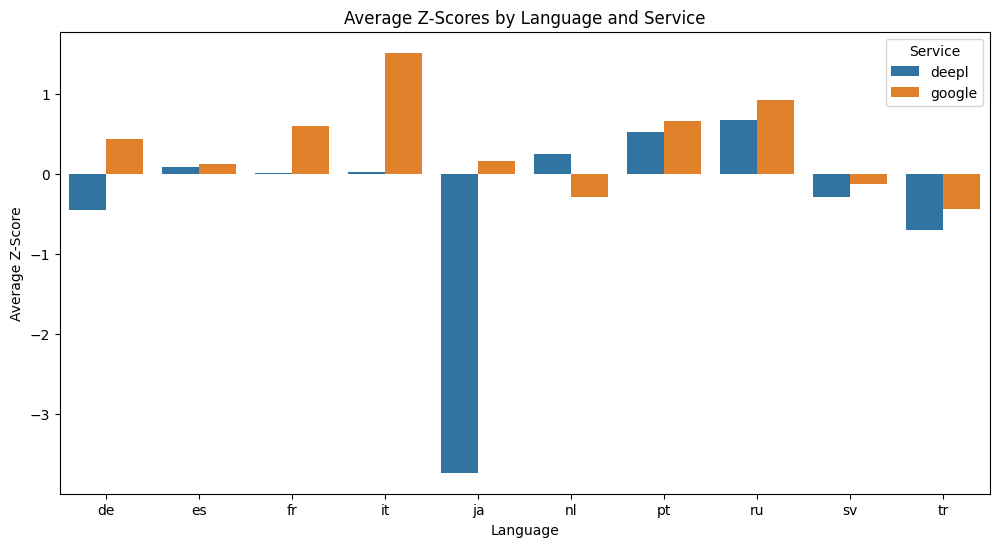

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def summarize_results(results):
    summary = []
    for service, service_results in results.items():
        for lang, metrics in service_results.items():
            z_score = refined_z_score(sample_text, metrics['retranslated_text'], mu, sigma)
            detected_as_llm = z_score < threshold
            summary.append({
                "Service": service,
                "Language": lang,
                "Similarity_Score": metrics["similarity_score"],
                "Z_Score": z_score,
                "Detected_As_LLM": detected_as_llm,
            })
    return pd.DataFrame(summary)

# Generate summary DataFrame
summary_df = summarize_results(retranslated_results)

# Reshape summary_df for grouped bar chart
grouped_df = summary_df.groupby(["Language", "Service"])["Z_Score"].mean().reset_index()

# Plot Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_df, x="Language", y="Z_Score", hue="Service", ci=None)
plt.title("Average Z-Scores by Language and Service")
plt.ylabel("Average Z-Score")
plt.xlabel("Language")
plt.legend(title="Service")
#plt.ylim(0.074,0.4)
plt.show()


In [ ]:
# Define thresholds for experimentation
#thresholds = [0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44]
thresholds = [0.05, 0.1, 0.11, 0.115, 0.12, 0.125, 0.13, 0.135, 0.14, 0.145, 0.15, 0.155]
# Store results for each threshold
threshold_results = {}

# Loop through thresholds and count detected texts
for threshold in thresholds:
    detected_count = sum(
        1 for service, translations in retranslated_results.items()
        for lang, metrics in translations.items()
        if refined_z_score(sample_text, metrics['retranslated_text'], mu, sigma) < threshold
    )
    threshold_results[threshold] = detected_count

# Print results
for threshold, count in threshold_results.items():
    print(f"Threshold: {threshold} - Detected as LLM-Generated: {count}")

# Visualize the results
# import matplotlib.pyplot as plt

# plt.bar(threshold_results.keys(), threshold_results.values(), color='skyblue')
# plt.xlabel('Threshold')
# plt.ylabel('Number of Detected Texts')
# plt.title('Detectability of Watermark Across Thresholds')
# plt.show()


Threshold: 0.05 - Detected as LLM-Generated: 9
Threshold: 0.1 - Detected as LLM-Generated: 10
Threshold: 0.11 - Detected as LLM-Generated: 10
Threshold: 0.115 - Detected as LLM-Generated: 10
Threshold: 0.12 - Detected as LLM-Generated: 10
Threshold: 0.125 - Detected as LLM-Generated: 10
Threshold: 0.13 - Detected as LLM-Generated: 11
Threshold: 0.135 - Detected as LLM-Generated: 11
Threshold: 0.14 - Detected as LLM-Generated: 11
Threshold: 0.145 - Detected as LLM-Generated: 11
Threshold: 0.15 - Detected as LLM-Generated: 11
Threshold: 0.155 - Detected as LLM-Generated: 11



Service: google
Outlier Language: fr - Z-Score: 0.6034
Outlier Language: es - Z-Score: 0.1294
Outlier Language: de - Z-Score: 0.4433
Outlier Language: it - Z-Score: 1.5154
Outlier Language: ru - Z-Score: 0.9206
Outlier Language: pt - Z-Score: 0.6598
Outlier Language: ja - Z-Score: 0.1642

Service: deepl
Outlier Language: nl - Z-Score: 0.2446
Outlier Language: ru - Z-Score: 0.6810
Outlier Language: pt - Z-Score: 0.5269


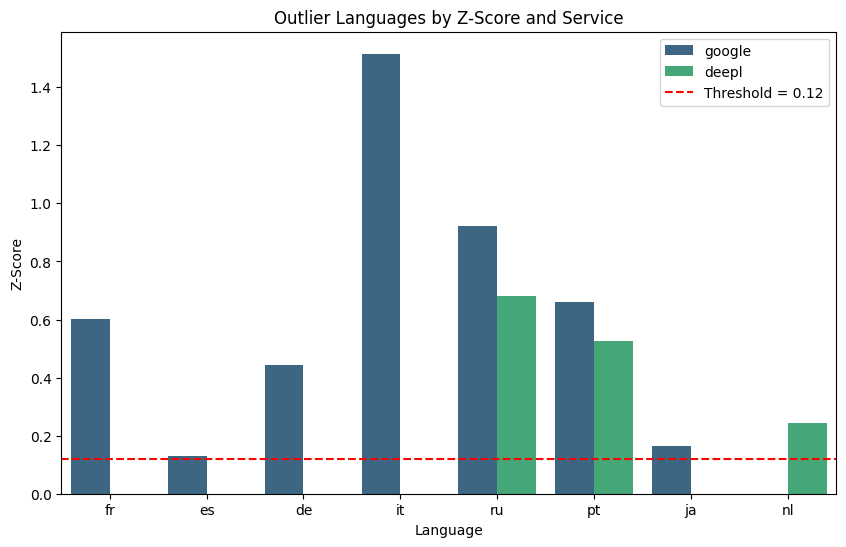

In [ ]:
# Define a threshold to identify outliers
outlier_threshold = 0.12

# Analyze languages with Z-scores above the outlier threshold
outlier_languages = []
for service, translations in retranslated_results.items():
    print(f"\nService: {service}")
    for lang, metrics in translations.items():
        retranslated_z_score = refined_z_score(sample_text, metrics['retranslated_text'], mu, sigma)
        if retranslated_z_score > outlier_threshold:  # Identify outliers
            outlier_languages.append((lang, service, retranslated_z_score))
            print(f"Outlier Language: {lang} - Z-Score: {retranslated_z_score:.4f}")

# Visualize the outliers
import pandas as pd
import seaborn as sns

# Create a DataFrame of outliers
outliers_df = pd.DataFrame(outlier_languages, columns=['Language', 'Service', 'Z-Score'])

# Create a bar chart for outlier languages
plt.figure(figsize=(10, 6))
sns.barplot(x="Language", y="Z-Score", hue="Service", data=outliers_df, palette="viridis")
plt.title('Outlier Languages by Z-Score and Service')
plt.xlabel('Language')
plt.ylabel('Z-Score')
plt.axhline(outlier_threshold, color='red', linestyle='--', label=f'Threshold = {outlier_threshold}')
plt.legend()
plt.show()


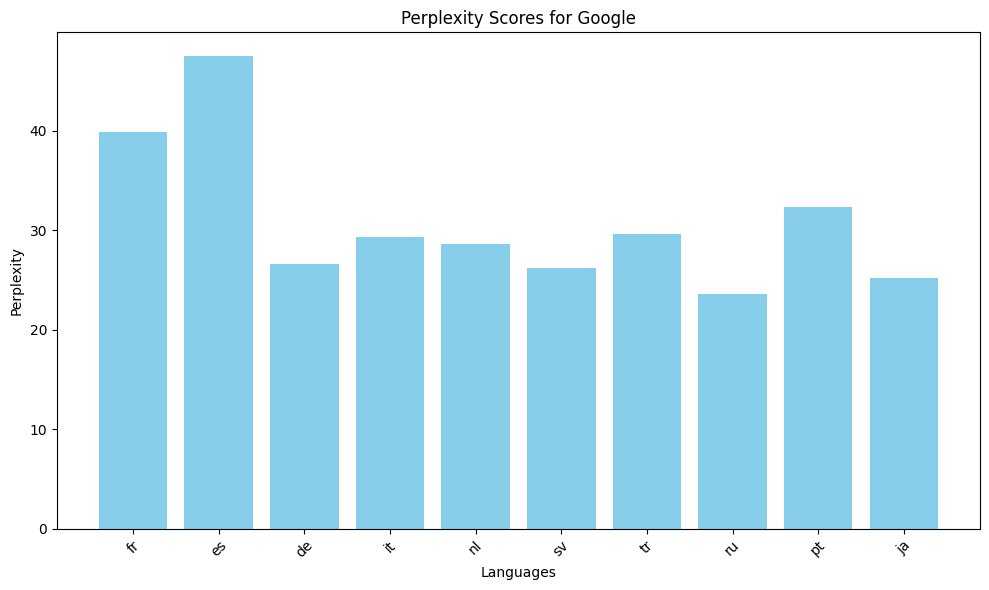

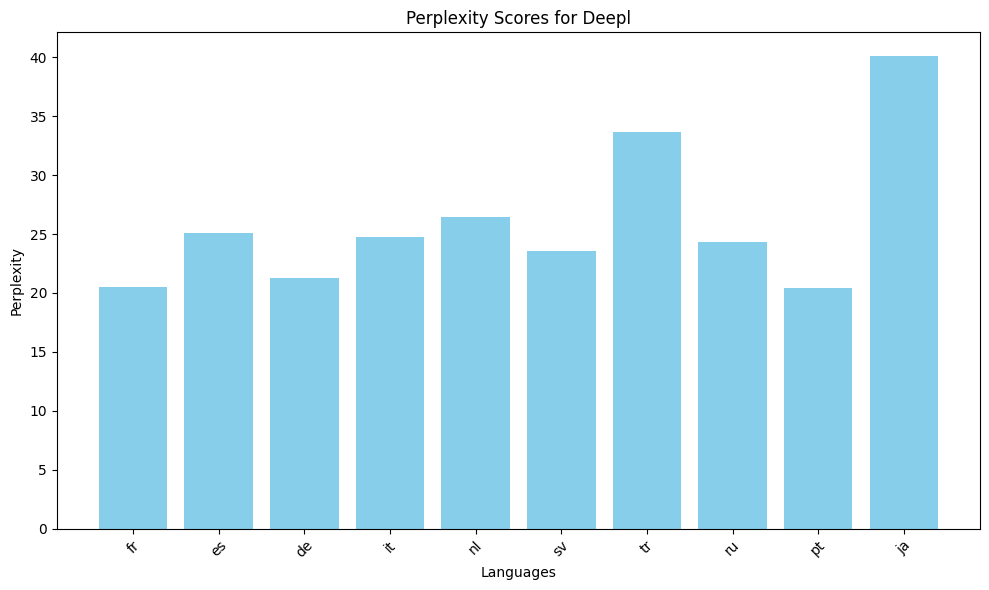

In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import matplotlib.pyplot as plt

# Load GPT-2 model and tokenizer
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Example: Calculate perplexity for each language and service
perplexity_results = {}
for service, translations in retranslated_results.items():
    service_perplexities = {}
    for lang, metrics in translations.items():
        retext = metrics['retranslated_text']
        perplexity = calculate_perplexity(retext)
        service_perplexities[lang] = perplexity
    perplexity_results[service] = service_perplexities

# Plotting the perplexity scores
for service, service_perplexities in perplexity_results.items():
    languages = list(service_perplexities.keys())
    perplexities = list(service_perplexities.values())

    plt.figure(figsize=(10, 6))
    plt.bar(languages, perplexities, color='skyblue')
    plt.xlabel('Languages')
    plt.ylabel('Perplexity')
    plt.title(f'Perplexity Scores for {service.capitalize()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
perplexity_results

{'google': {'fr': 39.88395690917969,
  'es': 47.500736236572266,
  'de': 26.614654541015625,
  'it': 29.34683609008789,
  'nl': 28.61155128479004,
  'sv': 26.212778091430664,
  'tr': 29.6312198638916,
  'ru': 23.5545711517334,
  'pt': 32.365638732910156,
  'ja': 25.177595138549805},
 'deepl': {'fr': 20.544803619384766,
  'es': 25.132375717163086,
  'de': 21.278705596923828,
  'it': 24.722490310668945,
  'nl': 26.413373947143555,
  'sv': 23.595792770385742,
  'tr': 33.628662109375,
  'ru': 24.349611282348633,
  'pt': 20.452619552612305,
  'ja': 40.12053680419922}}

  Service Language  Watermarked_Z_Score  Non_Watermarked_Z_Score
0  google       fr             3.703116                 0.603380
1  google       es             4.892903                 0.129398
2  google       de             0.039785                 0.443262
3  google       it             0.887749                 1.515359
4  google       nl             4.457525                -0.289651


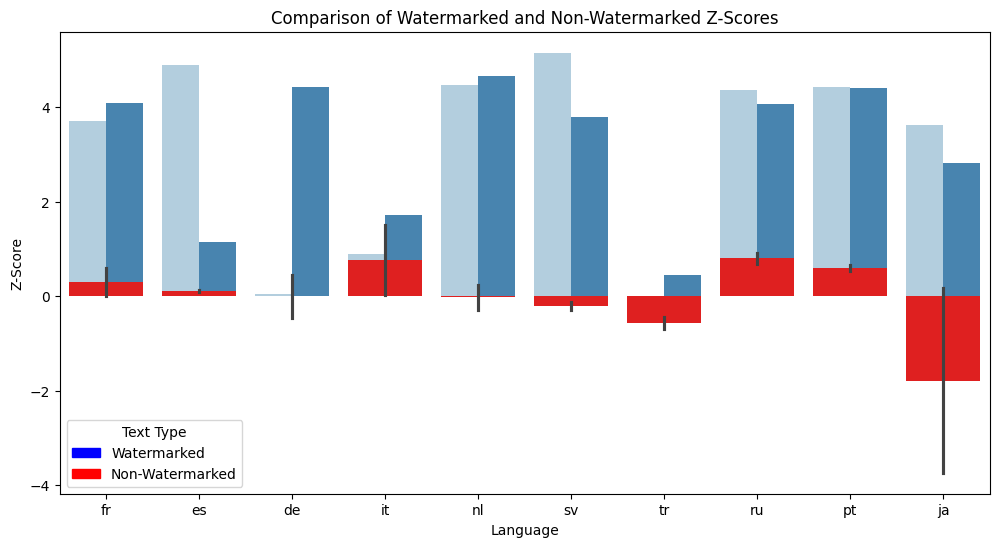

In [ ]:
# Define a non-watermarked text (original, unmodified)
#non_watermarked_text = "This is the original unwatermarked version of the sample text."
non_watermarked_text = sample_text

# Store results for comparison
comparison_results = []

for service, translations in retranslated_results.items():
    for lang, metrics in translations.items():
        retext = metrics['retranslated_text']

        # Calculate Z-scores
        watermarked_z_score = refined_z_score(layered_text, retext, mu, sigma)
        non_watermarked_z_score = refined_z_score(non_watermarked_text, retext, mu, sigma)

        # Store results
        comparison_results.append({
            'Service': service,
            'Language': lang,
            'Watermarked_Z_Score': watermarked_z_score,
            'Non_Watermarked_Z_Score': non_watermarked_z_score
        })

# Create a DataFrame for results
comparison_df = pd.DataFrame(comparison_results)

# Print the first few rows for inspection
print(comparison_df.head())

plt.figure(figsize=(12, 6))

# First barplot for 'Watermarked_Z_Score'
sns.barplot(
    x='Language',
    y='Watermarked_Z_Score',
    hue='Service',
    data=comparison_df,
    palette='Blues',
)

# Second barplot for 'Non_Watermarked_Z_Score'
# Remove the hue parameter and specify color directly
sns.barplot(
    x='Language',
    y='Non_Watermarked_Z_Score',
    data=comparison_df,
    color='red',  # Specify color for the non-watermarked bars
)


plt.title('Comparison of Watermarked and Non-Watermarked Z-Scores')
plt.xlabel('Language')
plt.ylabel('Z-Score')

# Manually create legend entries for watermarked and non-watermarked
import matplotlib.patches as mpatches
blue_patch = mpatches.Patch(color='blue', label='Watermarked')
red_patch = mpatches.Patch(color='red', label='Non-Watermarked')
plt.legend(handles=[blue_patch, red_patch], title='Text Type')

plt.show()


In [ ]:
comparison_results

[{'Service': 'google',
  'Language': 'fr',
  'Watermarked_Z_Score': 0.04418981075286865,
  'Non_Watermarked_Z_Score': 0.11191028356552124},
 {'Service': 'google',
  'Language': 'es',
  'Watermarked_Z_Score': 0.01819634437561035,
  'Non_Watermarked_Z_Score': 0.12226545810699463},
 {'Service': 'google',
  'Language': 'de',
  'Watermarked_Z_Score': 0.12422323226928711,
  'Non_Watermarked_Z_Score': 0.11540842056274414},
 {'Service': 'google',
  'Language': 'it',
  'Watermarked_Z_Score': 0.1056976318359375,
  'Non_Watermarked_Z_Score': 0.09198611974716187},
 {'Service': 'google',
  'Language': 'nl',
  'Watermarked_Z_Score': 0.027708113193511963,
  'Non_Watermarked_Z_Score': 0.13142049312591553},
 {'Service': 'google',
  'Language': 'sv',
  'Watermarked_Z_Score': 0.012632489204406738,
  'Non_Watermarked_Z_Score': 0.12774264812469482},
 {'Service': 'google',
  'Language': 'tr',
  'Watermarked_Z_Score': 0.13738983869552612,
  'Non_Watermarked_Z_Score': 0.1347501277923584},
 {'Service': 'google

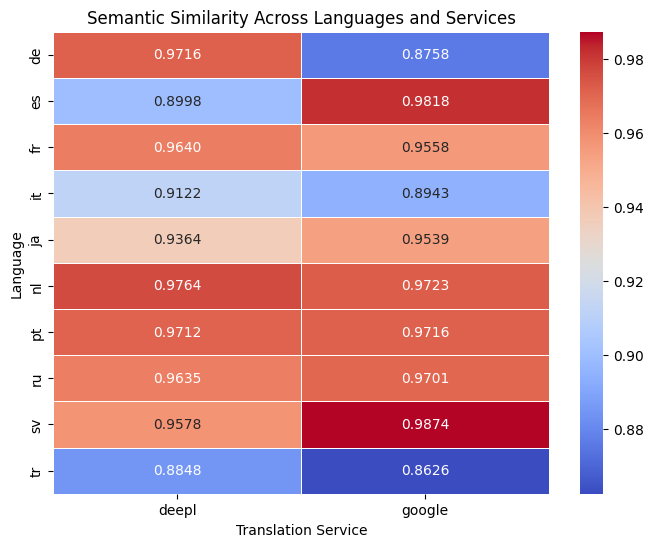

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for heatmap
def prepare_heatmap_data(multi_service_results):
    """
    Converts multi-service results into a DataFrame for heatmap visualization.
    """
    data = []
    for service, results in multi_service_results.items():
        for lang, metrics in results.items():
            data.append({"Service": service, "Language": lang, "Similarity": metrics["similarity_score"]})

    # Create a DataFrame
    df = pd.DataFrame(data)
    # Use index, columns, and values arguments as keywords
    heatmap_data = df.pivot(index="Language", columns="Service", values="Similarity")
    return heatmap_data

# Generate heatmap data
heatmap_data = prepare_heatmap_data(retranslated_results)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="coolwarm", linewidths=0.5, cbar=True)
plt.title("Semantic Similarity Across Languages and Services")
plt.ylabel("Language")
plt.xlabel("Translation Service")
plt.show()


In [ ]:
thresholds = [0.05, 0.1, 0.15, 0.2]
language_outliers = {}

for thresh in thresholds:
    outlier_count = comparison_df[comparison_df['Watermarked_Z_Score'] > thresh].groupby('Language').size()
    language_outliers[f'Threshold {thresh}'] = outlier_count

# Create DataFrame for outlier counts
outliers_df = pd.DataFrame(language_outliers).fillna(0)
print(outliers_df)


          Threshold 0.05  Threshold 0.1  Threshold 0.15  Threshold 0.2
Language                                                              
de                     1              1               1              1
es                     2              2               2              2
fr                     2              2               2              2
it                     2              2               2              2
ja                     2              2               2              2
nl                     2              2               2              2
pt                     2              2               2              2
ru                     2              2               2              2
sv                     2              2               2              2
tr                     1              1               1              1


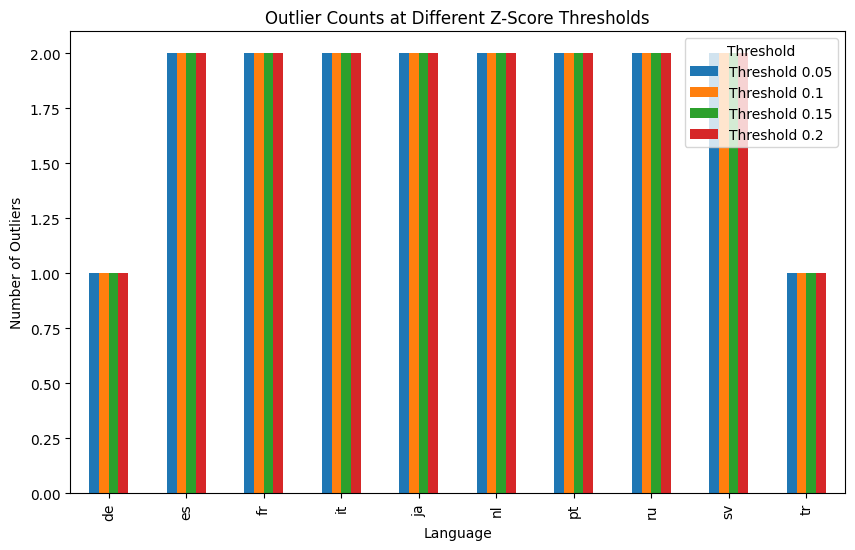

In [ ]:
outliers_df.plot(kind='bar', figsize=(10, 6))
plt.title('Outlier Counts at Different Z-Score Thresholds')
plt.xlabel('Language')
plt.ylabel('Number of Outliers')
plt.legend(title='Threshold')
plt.show()


In [ ]:
language_groups = {
    'Romance': ['fr', 'es', 'it', 'pt'],
    'Slavic': ['ru'],
    'Germanic': ['de', 'nl'],
    'Asian': ['ja']
}


In [ ]:
def get_language_group(lang):
    for group, langs in language_groups.items():
        if lang in langs:
            return group
    return 'Other'

comparison_df['Language_Group'] = comparison_df['Language'].apply(get_language_group)
group_means = comparison_df.groupby('Language_Group')[['Watermarked_Z_Score', 'Non_Watermarked_Z_Score']].mean()
print(group_means)


                Watermarked_Z_Score  Non_Watermarked_Z_Score
Language_Group                                              
Asian                      3.213490                -1.784134
Germanic                   3.392936                -0.014059
Other                      2.208039                -0.387375
Romance                    3.155820                 0.446556
Slavic                     4.206553                 0.800779


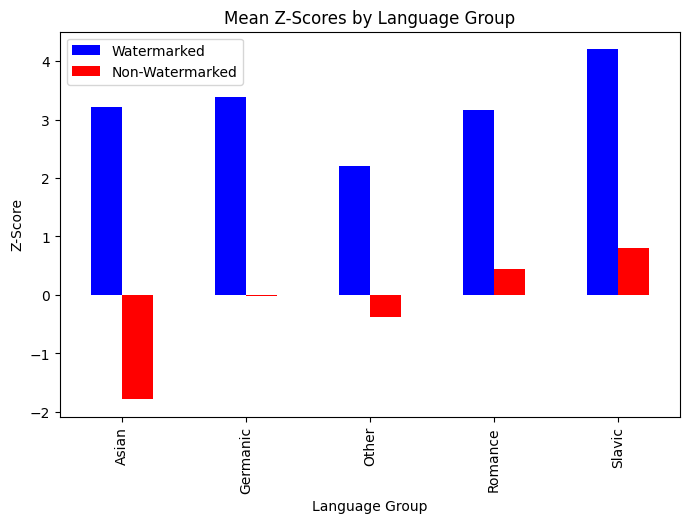

NameError: name 'ax' is not defined

In [ ]:
group_means.plot(kind='bar', figsize=(8, 5), color=['blue', 'red'])
plt.title('Mean Z-Scores by Language Group')
plt.ylabel('Z-Score')
plt.xlabel('Language Group')
plt.legend(['Watermarked', 'Non-Watermarked'])
plt.show()

